<a href="https://colab.research.google.com/github/marcelo7bastos/relatorio_dados_damei/blob/main/RelatorioBR02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Configurações Iniciais

In [52]:
from pathlib import Path
import unicodedata
import pandas as pd

DADO_PP_PRIORITARIO_ROOT = Path(
    "/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_prioritário"
)

def normalizar_nome(texto):
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    return texto.lower().strip()

print("Caminho informado:")
print(DADO_PP_PRIORITARIO_ROOT)

print("\nExiste?", DADO_PP_PRIORITARIO_ROOT.exists())
print("É pasta?", DADO_PP_PRIORITARIO_ROOT.is_dir())

if not DADO_PP_PRIORITARIO_ROOT.exists():
    print("\nPasta não encontrada. Verificando pastas vizinhas...")
    parent = DADO_PP_PRIORITARIO_ROOT.parent
    alvo = normalizar_nome(DADO_PP_PRIORITARIO_ROOT.name)

    if parent.exists():
        for item in sorted(parent.iterdir()):
            if item.is_dir():
                marcador = " <-- nome parecido" if normalizar_nome(item.name) == alvo else ""
                print(f"[DIR] {item.name}{marcador}")
    else:
        print(f"Pasta pai também não existe: {parent}")

else:
    registros = []
    for item in sorted(DADO_PP_PRIORITARIO_ROOT.iterdir()):
        registros.append({
            "tipo": "pasta" if item.is_dir() else "arquivo",
            "nome": item.name,
            "extensao": item.suffix.lower() if item.is_file() else "",
            "tamanho_mb": round(item.stat().st_size / 1024 / 1024, 2) if item.is_file() else None,
            "caminho": str(item),
        })

    df_arquivos = pd.DataFrame(registros)
    display(df_arquivos)

    print(f"\nTotal de itens: {len(df_arquivos)}")
    if not df_arquivos.empty:
        print(df_arquivos["tipo"].value_counts())

Caminho informado:
/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_prioritário

Existe? True
É pasta? True


,tipo,nome,extensao,tamanho_mb,caminho
0,arquivo,Cod_IBGE.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
1,arquivo,Desenrola_rural_20260601.xlsx,.xlsx,0.78,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
2,arquivo,PAA_2023_ate_2025.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
3,arquivo,PAA_2023_ate_2026_02.csv,.csv,1.26,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
4,arquivo,PAA_202602.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
5,arquivo,PAA_ComprasInstitucionais.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
6,arquivo,Quintais_Produtivos.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
7,arquivo,Territorio_Quilombola_Decretos.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
8,arquivo,Territorio_Quilombola_Portarias.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...
9,arquivo,Territorio_Quilombola_RTIDs.gsheet,.gsheet,0.00,/content/drive/MyDrive/DAMEI_Relatorio_Dados/d...



Total de itens: 12
tipo
arquivo    12
Name: count, dtype: int64


In [145]:
# 1. Preparar dados brutos

from datetime import datetime
from pathlib import Path
import hashlib
import os
import re
import shutil
import unicodedata
import pandas as pd

try:
    display
except NameError:
    def display(obj):
        """Fallback simples para execução fora do Colab/Jupyter."""
        print(obj)

SCRIPT_NAME = Path(__file__).name if "__file__" in globals() else "teste_relatoriobr_25maio2026.py"
SCRIPT_VERSION = "2026.06.02-nacional"

def env_bool(nome, padrao=False):
    valor = os.environ.get(nome)
    if valor is None:
        return padrao
    return str(valor).strip().lower() in {"1", "true", "sim", "s", "yes", "y"}

def normalizar_nome_fs(valor):
    texto = unicodedata.normalize("NFKD", str(valor))
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    return texto.casefold().strip()

def resolver_path_existente(caminho, alternativas=None):
    """Resolve caminho tolerando diferenças Unicode, comuns em nomes com acento no Drive."""
    caminho = Path(caminho)
    candidatos = [caminho, *(Path(p) for p in (alternativas or []))]
    for candidato in candidatos:
        if candidato.exists():
            return candidato.resolve()
    parent = caminho.parent
    if parent.exists():
        alvo = normalizar_nome_fs(caminho.name)
        for item in parent.iterdir():
            if normalizar_nome_fs(item.name) == alvo:
                return item.resolve()
    return caminho.resolve()

def escolher_saida_relatorio(path_drive, project_root):
    """Usa o Drive no Colab e fallback local quando o Drive não está montado."""
    path_drive = Path(path_drive).resolve()
    if path_drive.exists() or Path("/content/drive/MyDrive").exists():
        path_drive.mkdir(parents=True, exist_ok=True)
        return path_drive
    fallback = project_root / "relatorios_gerados" / "saida_relatorioBR"
    fallback.mkdir(parents=True, exist_ok=True)
    print(f"Aviso: Google Drive não encontrado. Usando saída local: {fallback}")
    return fallback.resolve()

MODO_ESTRITO = env_bool("MODO_ESTRITO", False)
PARAR_SE_FALTAR_OBRIGATORIA = env_bool("PARAR_SE_FALTAR_OBRIGATORIA", False)
LIMPAR_PLANILHAS_DESTINO = env_bool("LIMPAR_PLANILHAS_DESTINO", True)
COPIAR_POLITICAS_OPCIONAIS = env_bool("COPIAR_POLITICAS_OPCIONAIS", False)
ORIGEM_ROOT_OVERRIDE = os.environ.get("DADOS_BRUTOS_ORIGEM_ROOT") or None
PASTA_DESTINO_NOME = "dados_atuais"
PADRAO_PASTA_REFERENCIA = r"^dados_gaia_ref_(\d{6})$"
ARQUIVOS_IGNORADOS_LEITURA = {"Cod_IBGE.gsheet", "PAA_2023_ate_2026_02.csv", "Território_Quilombola.gsheet"}
ARQUIVOS_IGNORADOS_NORMALIZADOS = {normalizar_nome_fs(nome) for nome in ARQUIVOS_IGNORADOS_LEITURA}
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"
RUN_TIMESTAMP = datetime.now()
RUN_DATETIME = RUN_TIMESTAMP.strftime("%Y%m%d%H%M%S")
print(f"Data/hora da preparação: {RUN_TIMESTAMP:%d/%m/%Y %H:%M:%S}")
inicio = Path.cwd().resolve()
PROJECT_ROOT = inicio
for candidato in [inicio, *inicio.parents]:
    if (candidato / "notebooks").exists() and ((candidato / "requirements.txt").exists() or (candidato / "config" / "ufs.csv").exists()):
        PROJECT_ROOT = candidato
        break
DRIVE_DAMEI_ROOT = Path(os.environ.get("DAMEI_DRIVE_ROOT", "/content/drive/MyDrive/DAMEI_Relatorio_Dados")).resolve()
DADOS_BRUTOS_ROOT = DRIVE_DAMEI_ROOT / "dados_brutos"
DADO_ATUAL_ROOT = resolver_path_existente(DADOS_BRUTOS_ROOT / "dado_atual")
DADO_HISTORICO_ROOT = resolver_path_existente(DADOS_BRUTOS_ROOT / "dado_historico")
DADO_PP_PRIORITARIO_ROOT = resolver_path_existente(DADOS_BRUTOS_ROOT / "dado_pp_prioritario", alternativas=[DADOS_BRUTOS_ROOT / "dado_pp_prioritário"])
SAIDA_RELATORIO_BR_ROOT = escolher_saida_relatorio(DADOS_BRUTOS_ROOT / "saida_relatorioBR", PROJECT_ROOT)
ORIGEM_ROOT = resolver_path_existente(ORIGEM_ROOT_OVERRIDE) if ORIGEM_ROOT_OVERRIDE else DADO_PP_PRIORITARIO_ROOT
DESTINO_DIR = PROJECT_ROOT / "dados_brutos" / "dado_atual" / PASTA_DESTINO_NOME
DESTINO_DIR.mkdir(parents=True, exist_ok=True)
POLITICAS = [
    {"politica": "caf_dap", "rotulo": "CAF/DAP", "obrigatoria": True, "regex": r"\b(caf|dap)\b|caf_dap"},
    {"politica": "ater", "rotulo": "ATER", "obrigatoria": True, "regex": r"\bater\b|ater_"},
    {"politica": "pronaf", "rotulo": "PRONAF", "obrigatoria": True, "regex": r"\bpronaf\b|pronaf_"},
    {"politica": "mais_alimentos", "rotulo": "Mais Alimentos", "obrigatoria": True, "regex": r"mais[_ -]?alimentos"},
    {"politica": "garantia_safra", "rotulo": "Garantia-Safra", "obrigatoria": True, "regex": r"garantia[_ -]?safra"},
    {"politica": "pncf", "rotulo": "PNCF", "obrigatoria": True, "regex": r"\bpncf\b|pncf_"},
    {"politica": "pnra", "rotulo": "PNRA", "obrigatoria": True, "regex": r"\bpnra\b|pnra_"},
    {"politica": "selo_bio", "rotulo": "Selo Bio", "obrigatoria": False, "regex": r"selo.*bio|bio.*selo"},
    {"politica": "Território_Quilombola_RTDIs", "rotulo": "Território Quilombola RTDIs", "obrigatoria": True, "regex": r"territorio[_ ]?quilombola[_ ]?rtid"},
    {"politica": "Território_Quilombola_Portarias", "rotulo": "Território Quilombola Portarias", "obrigatoria": True, "regex": r"territorio[_ ]?quilombola[_ ]?portarias"},
    {"politica": "Território_Quilombola_Decretos", "rotulo": "Território Quilombola Decretos", "obrigatoria": True, "regex": r"territorio[_ ]?quilombola[_ ]?decretos"},
    {"politica": "PAA_ComprasInstitucionais", "rotulo": "PAA Compras Institucionais", "obrigatoria": True, "regex": r"paa[_ ]?compras[_ ]?institucionais"},
    {"politica": "Quintais_Produtivos", "rotulo": "Quintais Produtivos", "obrigatoria": True, "regex": r"quintais[_ ]?produtivos"},
    {"politica": "PAA_", "rotulo": "PAA Agricultor Familiar", "obrigatoria": True, "regex": r"\bpaa\b|paa_.*\.(gsheet|xlsx|csv)"},
    {"politica": "Titulos_Incra", "rotulo": "Títulos PNRA", "obrigatoria": True, "regex": r"titulos[_ ]?incra"},
    {"politica": "Desenrola_rural", "rotulo": "Desenrola Rural", "obrigatoria": True, "regex": r"desenrola[_ -]?rural.*\.(gsheet|xlsx|csv)?"}
]

def competencia_from_nome_pasta(nome):
    match = re.match(PADRAO_PASTA_REFERENCIA, str(nome))
    return match.group(1) if match else None

def competencia_from_texto(valor):
    if valor is None or pd.isna(valor): return None
    texto = str(valor)
    match = re.search(r"(20\d{2})\D?(0[1-9]|1[0-2])", texto)
    return f"{match.group(1)}{match.group(2)}" if match else None

def classificar_politica(arquivo):
    nome = normalizar_nome_fs(arquivo.name)
    for item in POLITICAS:
        if re.search(item["regex"], nome): return item
    return None

RAIZES_BUSCA = [DADO_PP_PRIORITARIO_ROOT, DADO_ATUAL_ROOT, DADO_HISTORICO_ROOT]
pastas_referencia = []
for raiz in RAIZES_BUSCA:
    if not raiz.exists(): continue
    comp_raiz = competencia_from_nome_pasta(raiz.name)
    if comp_raiz: pastas_referencia.append({"competencia_pasta": comp_raiz, "pasta": raiz})
    for item in raiz.iterdir():
        if item.is_dir():
            comp_sub = competencia_from_nome_pasta(item.name)
            if comp_sub: pastas_referencia.append({"competencia_pasta": comp_sub, "pasta": item})
    if any(f.is_file() and normalizar_nome_fs(f.name) not in ARQUIVOS_IGNORADOS_NORMALIZADOS for f in raiz.iterdir()):
        comp_execucao = RUN_DATETIME[:6]
        if not any(p["pasta"] == raiz for p in pastas_referencia): pastas_referencia.append({"competencia_pasta": comp_execucao, "pasta": raiz})
pastas_referencia = sorted([dict(t) for t in {tuple(d.items()) for d in pastas_referencia}], key=lambda x: x["competencia_pasta"], reverse=True)
competencia_alvo = pastas_referencia[0]["competencia_pasta"] if pastas_referencia else None

Data/hora da preparação: 03/06/2026 14:56:42


# 2. Extração e transformação dos Dados




### 2.1 Importar biblioteca

In [54]:
from datetime import datetime
from pathlib import Path
import os
import re
import unicodedata

import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

### 2.2 Configurar parametros de execução


In [55]:
MODO_DADOS = "google_drive" if "COLAB_RELEASE_TAG" in os.environ else "local"

# IDs/caminhos usados no Google Drive baseados nas definições anteriores
GOOGLE_DRIVE_HISTORICO_FOLDER_ID = "1C0fp4QITO6EhzODQu_KQMZWxXyfAPI0n"
RAW_ATUAL_PREPARADO_DIR = DESTINO_DIR
GOOGLE_DRIVE_RAW_ATUAL_DIR = RAW_ATUAL_PREPARADO_DIR
GOOGLE_DRIVE_HISTORICO_DIR = DADO_HISTORICO_ROOT

# O output de intermediários pode ser uma subpasta na saída do relatório
GOOGLE_DRIVE_OUTPUT_INTERMEDIARIOS_DIR = SAIDA_RELATORIO_BR_ROOT / "dados_intermediarios"
GOOGLE_DRIVE_OUTPUT_INTERMEDIARIOS_DIR.mkdir(parents=True, exist_ok=True)

RAW_ATUAL_DIR_OVERRIDE = os.environ.get("RAW_ATUAL_DIR") or None

# Configurações de Subpastas
RAW_ATUAL_PREPARADO_NOME = "dados_atuais"
UF_TABLE_SUBPATH = Path("config") / "ufs.csv"

RUN_TIMESTAMP = datetime.now()
RUN_YYYYMM = RUN_TIMESTAMP.strftime("%Y%m")
RUN_DATETIME = RUN_TIMESTAMP.strftime("%Y%m%d%H%M%S")

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

print(f"Modo de dados: {MODO_DADOS}")
print(f"Raiz Dados Atuais: {GOOGLE_DRIVE_RAW_ATUAL_DIR}")
print(f"Raiz Dados Históricos: {GOOGLE_DRIVE_HISTORICO_DIR}")
print(f"Saída Intermediários: {GOOGLE_DRIVE_OUTPUT_INTERMEDIARIOS_DIR}")
print(f"Data/hora da execução: {RUN_TIMESTAMP:%d/%m/%Y %H:%M:%S}")

Modo de dados: google_drive
Raiz Dados Atuais: /content/dados_brutos/dado_atual/dados_atuais
Raiz Dados Históricos: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/dado_historico
Saída Intermediários: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios
Data/hora da execução: 03/06/2026 13:21:56


### 2.3 Resolver caminhos de entrada e saída

In [56]:
inicio = Path.cwd().resolve()
CODE_PROJECT_ROOT = inicio

for candidato in [inicio, *inicio.parents]:
    tem_notebooks = (candidato / "notebooks").exists()
    tem_requirements = (candidato / "requirements.txt").exists()
    tem_config = (candidato / UF_TABLE_SUBPATH).exists()
    if tem_notebooks and (tem_requirements or tem_config):
        CODE_PROJECT_ROOT = candidato
        break

if MODO_DADOS == "local":
    RAW_ATUAL_DIR = resolver_path_existente(RAW_ATUAL_DIR_OVERRIDE) if RAW_ATUAL_DIR_OVERRIDE else RAW_ATUAL_PREPARADO_DIR
    DATA_PROJECT_ROOT = RAW_ATUAL_DIR.parent
    HISTORICO_ROOT_DIR = GOOGLE_DRIVE_HISTORICO_DIR
    OUTPUT_ROOT_DIR = GOOGLE_DRIVE_OUTPUT_INTERMEDIARIOS_DIR / RUN_YYYYMM

elif MODO_DADOS == "google_drive":
    from google.colab import drive
    if not Path("/content/drive").exists():
        drive.mount("/content/drive")

    RAW_ATUAL_DIR = resolver_path_existente(RAW_ATUAL_DIR_OVERRIDE) if RAW_ATUAL_DIR_OVERRIDE else RAW_ATUAL_PREPARADO_DIR
    HISTORICO_ROOT_DIR = GOOGLE_DRIVE_HISTORICO_DIR
    DATA_PROJECT_ROOT = RAW_ATUAL_DIR.parent
    OUTPUT_ROOT_DIR = GOOGLE_DRIVE_OUTPUT_INTERMEDIARIOS_DIR / RUN_YYYYMM

else:
    raise ValueError('MODO_DADOS deve ser "local" ou "google_drive".')

# Definição das pastas específicas de histórico
HISTORICO_PRONAF_DIR = HISTORICO_ROOT_DIR / "PRONAF"
HISTORICO_ATER_DIR = HISTORICO_ROOT_DIR / "ATER"
HISTORICO_MAIS_ALIMENTOS_DIR = HISTORICO_ROOT_DIR / "MAIS_ALIMENTOS"

# Criação da estrutura de pastas de saída
POLITICAS_DIR = OUTPUT_ROOT_DIR / "politicas"
HISTORICO_DIR = OUTPUT_ROOT_DIR / "historico"
CONSOLIDADO_DIR = OUTPUT_ROOT_DIR / "consolidado"
LOGS_DIR = OUTPUT_ROOT_DIR / "logs"

for pasta in [POLITICAS_DIR, HISTORICO_DIR, CONSOLIDADO_DIR, LOGS_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

UF_TABLE_PATH = CODE_PROJECT_ROOT / UF_TABLE_SUBPATH

print(f"--- Resumo de Caminhos Fase 2 ---")
print(f"Dados Atuais (Ref):        {RAW_ATUAL_DIR}")
print(f"Raiz Histórico:            {HISTORICO_ROOT_DIR}")
print(f"Histórico Mais Alimentos:  {HISTORICO_MAIS_ALIMENTOS_DIR}")
print(f"Saída desta rodade:        {OUTPUT_ROOT_DIR}")

--- Resumo de Caminhos Fase 2 ---
Dados Atuais (Ref):        /content/dados_brutos/dado_atual/dados_atuais
Raiz Histórico:            /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/dado_historico
Histórico Mais Alimentos:  /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/dado_historico/MAIS_ALIMENTOS
Saída desta rodade:        /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606


### 2.4 Inventário dos arquivos encontrados

In [57]:
if not RAW_ATUAL_DIR.exists():
    raise FileNotFoundError(f"Pasta de dados atuais nao encontrada: {RAW_ATUAL_DIR}")

excel_files_atuais = sorted(
    arquivo for arquivo in RAW_ATUAL_DIR.glob("*.xlsx")
    if not arquivo_deve_ser_ignorado(arquivo)
)

# Initialize arquivos_politicas dynamically based on selected policies
arquivos_politicas = {}
for _, row in df_selecionados.iterrows():
    if row["status"] == "selecionado":
        arquivos_politicas[row["politica"]] = Path(row["caminho_origem"])

pronaf_historico_files = sorted(
    arquivo for arquivo in HISTORICO_PRONAF_DIR.glob("*.xlsx")
    if not arquivo_deve_ser_ignorado(arquivo)
) if HISTORICO_PRONAF_DIR.exists() else []
ater_historico_files = sorted(
    arquivo for arquivo in HISTORICO_ATER_DIR.glob("*.xlsx")
    if not arquivo_deve_ser_ignorado(arquivo)
) if HISTORICO_ATER_DIR.exists() else []
mais_alimentos_historico_files = sorted(
    arquivo for arquivo in HISTORICO_MAIS_ALIMENTOS_DIR.glob("*.xlsx")
    if not arquivo_deve_ser_ignorado(arquivo)
) if HISTORICO_MAIS_ALIMENTOS_DIR.exists() else []

linhas_inventario = []
for politica_key, arquivo_path in arquivos_politicas.items():
    # Try to find the corresponding entry in df_selecionados for additional details
    selected_row = df_selecionados[
        (df_selecionados["politica"] == politica_key) &
        (df_selecionados["status"] == "selecionado")
    ]
    if not selected_row.empty:
        row_data = selected_row.iloc[0]
        linhas_inventario.append({
            "tipo": "atual",
            "politica": politica_key,
            "arquivo": row_data["arquivo_origem"],
            "caminho": str(row_data["caminho_origem"]),
            "encontrado": True,
        })
    else:
        linhas_inventario.append({
            "tipo": "atual",
            "politica": politica_key,
            "arquivo": "NAO ENCONTRADO",
            "caminho": "",
            "encontrado": False,
        })

for arquivo in pronaf_historico_files:
    linhas_inventario.append({"tipo": "historico", "politica": "pronaf", "arquivo": arquivo.name, "caminho": str(arquivo), "encontrado": True})
for arquivo in ater_historico_files:
    linhas_inventario.append({"tipo": "historico", "politica": "ater", "arquivo": arquivo.name, "caminho": str(arquivo), "encontrado": True})
for arquivo in mais_alimentos_historico_files:
    linhas_inventario.append({"tipo": "historico", "politica": "mais_alimentos", "arquivo": arquivo.name, "caminho": str(arquivo), "encontrado": True})

df_inventario = pd.DataFrame(linhas_inventario)
if not df_inventario.empty:
    df_inventario["script_origem"] = SCRIPT_NAME
    df_inventario["versao_script"] = SCRIPT_VERSION
    df_inventario["run_id"] = RUN_DATETIME
df_inventario.to_csv(LOGS_DIR / "inventario_arquivos.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)

print(f"Arquivos atuais encontrados: {len([path for path in arquivos_politicas.values() if path is not None])}")
print(f"Historicos PRONAF encontrados: {len(pronaf_historico_files)}")
print(f"Historicos ATER encontrados: {len(ater_historico_files)}")
print(f"Historicos MAIS ALIMENTOS encontrados: {len(mais_alimentos_historico_files)}")
display(df_inventario)

Arquivos atuais encontrados: 15
Historicos PRONAF encontrados: 11
Historicos ATER encontrados: 9
Historicos MAIS ALIMENTOS encontrados: 14


,tipo,politica,arquivo,caminho,encontrado,script_origem,versao_script,run_id
0,atual,caf_dap,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
1,atual,ater,ater_ate_2026_04_gerado_em_20260512153352.xlsx,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
2,atual,pronaf,pronaf_gaia_202605131604.xlsx,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
3,atual,mais_alimentos,mais_alimentos_gaia_202605131504.xlsx,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
4,atual,garantia_safra,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
5,atual,pncf,pncf_2026_04_gerado_em_20260514095754.xlsx,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
6,atual,pnra,PNRA_2026_2026_04_15.xlsx,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
7,atual,Território_Quilombola_RTDIs,Territorio_Quilombola_RTIDs.gsheet,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
8,atual,Território_Quilombola_Portarias,Territorio_Quilombola_Portarias.gsheet,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
9,atual,Território_Quilombola_Decretos,Territorio_Quilombola_Decretos.gsheet,/content/drive/.shortcut-targets-by-id/1vjphYN...,True,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156


### 2.5 Inspecionar abas e colunas

In [58]:
import pandas as pd
from pathlib import Path
import json
import re
import unicodedata

# Add gspread imports and authentication for this cell's self-containment
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default

# 1. Authentication (assumes it's done, but making sure for this cell)
auth.authenticate_user() # Ensuring authentication is explicitly called
creds, _ = default()
gc = gspread.Client(auth=creds)

# Helper Functions (copied for self-contained execution)
def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    caminho_gsheet = Path(caminho_gsheet)
    nome_planilha = caminho_gsheet.stem
    try:
        conteudo = caminho_gsheet.read_text(encoding="utf-8").strip()
        if conteudo:
            meta = json.loads(conteudo)
            url = meta.get("url") or meta.get("doc_url")
            doc_id = meta.get("doc_id") or meta.get("spreadsheet_id") or meta.get("id")
            if doc_id:
                return cliente_gspread.open_by_key(doc_id)
            if url:
                return cliente_gspread.open_by_url(url)
    except Exception:
        pass
    return cliente_gspread.open(nome_planilha)

def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}
    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)
    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]
    raise ValueError(f"Nenhuma das abas esperadas foi encontrada. Abas disponíveis: {nomes}. Prioridades tentadas: {prioridades}")

# End Helper Functions

linhas_estrutura = []

for politica, arquivo in arquivos_politicas.items():
    if arquivo is None:
        linhas_estrutura.append({"tipo": "atual", "politica": politica, "arquivo": "NAO ENCONTRADO", "aba": "", "qtd_colunas": 0, "colunas": ""})
        continue

    if arquivo.suffix.lower() == '.gsheet':
        try:
            spreadsheet = abrir_planilha_google(arquivo, gc)
            sheet_names = [ws.title for ws in spreadsheet.worksheets()]

            # Iterate through each sheet in the gsheet file
            for aba_title in sheet_names:
                # Read only header to get column names
                ws = spreadsheet.worksheet(aba_title)
                df_header = gd.get_as_dataframe(ws, nrows=0, header=0)
                colunas = df_header.columns.astype(str).tolist()
                linhas_estrutura.append({
                    "tipo": "atual",
                    "politica": politica,
                    "arquivo": arquivo.name,
                    "aba": aba_title,
                    "qtd_colunas": len(colunas),
                    "colunas": ", ".join(colunas[:20]),
                })
        except Exception as e:
            print(f"Erro ao processar GSheet {arquivo.name}: {e}")
            linhas_estrutura.append({
                "tipo": "atual", "politica": politica, "arquivo": arquivo.name,
                "aba": "Erro na leitura", "qtd_colunas": 0, "colunas": str(e)[:100]
            })
    else: # Handle .xlsx files as before
        try:
            xls = pd.ExcelFile(arquivo)
            for aba in xls.sheet_names:
                if politica == "caf_dap" and aba == "TOTALIZADORES":
                    colunas = pd.read_excel(arquivo, sheet_name=aba, nrows=0, skiprows=6).columns.astype(str).tolist()
                else:
                    colunas = pd.read_excel(arquivo, sheet_name=aba, nrows=0).columns.astype(str).tolist()
                linhas_estrutura.append({
                    "tipo": "atual",
                    "politica": politica,
                    "arquivo": arquivo.name,
                    "aba": aba,
                    "qtd_colunas": len(colunas),
                    "colunas": ", ".join(colunas[:20]),
                })
        except Exception as e:
            print(f"Erro ao processar Excel {arquivo.name}: {e}")
            linhas_estrutura.append({
                "tipo": "atual", "politica": politica, "arquivo": arquivo.name,
                "aba": "Erro na leitura", "qtd_colunas": 0, "colunas": str(e)[:100]
            })

for politica, lista_arquivos in [("pronaf", pronaf_historico_files), ("ater", ater_historico_files)]:
    for arquivo in lista_arquivos:
        if arquivo.suffix.lower() == '.gsheet':
             try:
                spreadsheet = abrir_planilha_google(arquivo, gc)
                sheet_names = [ws.title for ws in spreadsheet.worksheets()]
                for aba_title in sheet_names:
                    ws = spreadsheet.worksheet(aba_title)
                    df_header = gd.get_as_dataframe(ws, nrows=0, header=0)
                    colunas = df_header.columns.astype(str).tolist()
                    linhas_estrutura.append({
                        "tipo": "historico",
                        "politica": politica,
                        "arquivo": arquivo.name,
                        "aba": aba_title,
                        "qtd_colunas": len(colunas),
                        "colunas": ", ".join(colunas[:20]),
                    })
             except Exception as e:
                print(f"Erro ao processar histórico GSheet {arquivo.name}: {e}")
                linhas_estrutura.append({
                    "tipo": "historico", "politica": politica, "arquivo": arquivo.name,
                    "aba": "Erro na leitura", "qtd_colunas": 0, "colunas": str(e)[:100]
                })
        else: # Handle .xlsx files for historical data
            try:
                xls = pd.ExcelFile(arquivo)
                for aba in xls.sheet_names:
                    colunas = pd.read_excel(arquivo, sheet_name=aba, nrows=0).columns.astype(str).tolist()
                    linhas_estrutura.append({
                        "tipo": "historico",
                        "politica": politica,
                        "arquivo": arquivo.name,
                        "aba": aba,
                        "qtd_colunas": len(colunas),
                        "colunas": ", ".join(colunas[:20]),
                    })
            except Exception as e:
                print(f"Erro ao processar histórico Excel {arquivo.name}: {e}")
                linhas_estrutura.append({
                    "tipo": "historico", "politica": politica, "arquivo": arquivo.name,
                    "aba": "Erro na leitura", "qtd_colunas": 0, "colunas": str(e)[:100]
                })

df_estrutura = pd.DataFrame(linhas_estrutura)
df_estrutura.to_csv(LOGS_DIR / "estrutura_abas_colunas.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_estrutura)


,tipo,politica,arquivo,aba,qtd_colunas,colunas
0,atual,caf_dap,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,Orientações,1,Orientações
1,atual,caf_dap,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,DADOS,9,"dt_referencia, dt_geracao, cod_ibge, nome_muni..."
2,atual,caf_dap,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,TOTALIZADORES,8,"dt_referencia, dt_geracao, cod_ibge_estados, u..."
3,atual,ater,ater_ate_2026_04_gerado_em_20260512153352.xlsx,Orientações,1,Orientações
4,atual,ater,ater_ate_2026_04_gerado_em_20260512153352.xlsx,DADOS,7,"dt_referencia, dt_geracao, cod_ibge, nome_muni..."
...,...,...,...,...,...,...
93,historico,ater,ater_ate_2025_12_gerado_em_20260114105014.xlsx,DADOS,7,"dt_referencia, dt_geracao, cod_ibge, nome_muni..."
94,historico,ater,ater_ate_2025_12_gerado_em_20260114105014.xlsx,TOTALIZADORES,1,Planilha de Dados - Totalizadores
95,historico,ater,ater_ate_2026_03_gerado_em_20260410151127.xlsx,Orientações,1,Orientações
96,historico,ater,ater_ate_2026_03_gerado_em_20260410151127.xlsx,DADOS,7,"dt_referencia, dt_geracao, cod_ibge, nome_muni..."


### 2.6  Carregar tabela oficial de UFs

In [59]:
import pandas as pd
from pathlib import Path

# Garante que o diretório pai existe
UF_TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)

if not UF_TABLE_PATH.exists():
    print(f"AVISO: Tabela de UFs não encontrada em {UF_TABLE_PATH}. Gerando dados padrão...")
    # Gerar dados padrão caso o arquivo não exista
    dados_padrao = [
        ("AC", "12", "Acre"),
        ("AL", "27", "Alagoas"),
        ("AP", "16", "Amapá"),
        ("AM", "13", "Amazonas"),
        ("BA", "29", "Bahia"),
        ("CE", "23", "Ceará"),
        ("DF", "53", "Distrito Federal"),
        ("ES", "32", "Espírito Santo"),
        ("GO", "52", "Goiás"),
        ("MA", "21", "Maranhão"),
        ("MT", "51", "Mato Grosso"),
        ("MS", "50", "Mato Grosso do Sul"),
        ("MG", "31", "Minas Gerais"),
        ("PA", "15", "Pará"),
        ("PB", "25", "Paraíba"),
        ("PR", "41", "Paraná"),
        ("PE", "26", "Pernambuco"),
        ("PI", "22", "Piauí"),
        ("RJ", "33", "Rio de Janeiro"),
        ("RN", "24", "Rio Grande do Norte"),
        ("RS", "43", "Rio Grande do Sul"),
        ("RO", "11", "Rondônia"),
        ("RR", "14", "Roraima"),
        ("SC", "42", "Santa Catarina"),
        ("SP", "35", "São Paulo"),
        ("SE", "28", "Sergipe"),
        ("TO", "17", "Tocantins"),
    ]
    df_ufs = pd.DataFrame(dados_padrao, columns=["sigla", "codigo_ibge", "nome_uf"])
    # Salva para uso futuro
    df_ufs.to_csv(UF_TABLE_PATH, index=False)
else:
    df_ufs = pd.read_csv(
        UF_TABLE_PATH,
        dtype={"sigla": "string", "codigo_ibge": "string", "nome_uf": "string"}
    )

# Normalização
df_ufs["sigla"] = df_ufs["sigla"].astype(str).str.strip().str.upper()
df_ufs["codigo_ibge"] = df_ufs["codigo_ibge"].astype(str).str.strip().str.zfill(2)
df_ufs["nome_uf"] = df_ufs["nome_uf"].astype(str).str.strip()

UF_VALIDAS = set(df_ufs["sigla"].tolist())
df_ufs.to_csv(LOGS_DIR / "ufs_referencia.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)

print(f"Tabela de UFs carregada com {len(df_ufs)} registros.")
display(df_ufs.head())


AVISO: Tabela de UFs não encontrada em /content/config/ufs.csv. Gerando dados padrão...
Tabela de UFs carregada com 27 registros.


,sigla,codigo_ibge,nome_uf
0,AC,12,Acre
1,AL,27,Alagoas
2,AP,16,Amapá
3,AM,13,Amazonas
4,BA,29,Bahia


# 3. Carregamento de dados

### 3.1 CAF

In [60]:
arquivo_caf = arquivos_politicas["caf_dap"]
if arquivo_caf is None:
    raise FileNotFoundError("Arquivo CAF/DAP não encontrado.")

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def localizar_aba(xls, prioridades):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    mapa_abas = {normalizar_nome_aba(nome): nome for nome in xls.sheet_names}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa_abas.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return aba_encontrada

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {xls.sheet_names}. "
        f"Prioridades tentadas: {prioridades}"
    )

# Abre o arquivo uma única vez
xls_caf = pd.ExcelFile(arquivo_caf, engine="openpyxl")

# -------------------------------------------------------
# 1) Leitura municipal
# Preferência: Dados -> TOTALIZADORES -> Totalizadores
# -------------------------------------------------------
aba_caf_municipio = localizar_aba(
    xls_caf,
    ["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"]
)

df_caf_municipio = pd.read_excel(
    xls_caf,
    sheet_name=aba_caf_municipio,
    engine="openpyxl",
    na_values=["NA", "na", ""]
)
df_caf_municipio.columns = df_caf_municipio.columns.astype(str).str.strip()

caf_municipio_colunas_obrigatorias = [
    "dt_referencia",
    "dt_geracao",
    "cod_ibge",
    "nome_municipio",
    "uf",
    "CAFs PF ATIVO",
    "CAFs PJ ATIVO",
    "QUANTIDADE DE MULHERES EM CAF ATIVO",
    "QUANTIDADE DE HOMENS EM CAF ATIVO",
]

faltantes = [col for col in caf_municipio_colunas_obrigatorias if col not in df_caf_municipio.columns]
if faltantes:
    raise KeyError(
        f"Colunas ausentes em CAF/DAP na aba '{aba_caf_municipio}': {faltantes}"
    )

df_caf_municipio = df_caf_municipio[caf_municipio_colunas_obrigatorias].copy()

# A coluna original "CAFs PF ATIVO" representa a UFPA e passa a ser padronizada como "ufpa"
# nos arquivos tratados, preservando a origem no arquivo bruto.
df_caf_municipio = df_caf_municipio.rename(columns={
    "CAFs PF ATIVO": "ufpa",
    "CAFs PJ ATIVO": "cafs_pj_ativo",
    "QUANTIDADE DE MULHERES EM CAF ATIVO": "mulheres_em_caf_ativo",
    "QUANTIDADE DE HOMENS EM CAF ATIVO": "homens_em_caf_ativo",
})

for col in ["dt_referencia", "dt_geracao", "cod_ibge", "nome_municipio", "uf"]:
    df_caf_municipio[col] = df_caf_municipio[col].astype(str).str.strip()

for col in ["ufpa", "cafs_pj_ativo", "mulheres_em_caf_ativo", "homens_em_caf_ativo"]:
    df_caf_municipio[col] = pd.to_numeric(df_caf_municipio[col], errors="coerce").fillna(0)

df_caf_municipio["uf"] = df_caf_municipio["uf"].str.upper()
df_caf_municipio = df_caf_municipio[df_caf_municipio["uf"].isin(UF_VALIDAS)].copy()
df_caf_municipio["arquivo_origem"] = arquivo_caf.name
df_caf_municipio["aba_origem"] = aba_caf_municipio

# -------------------------------------------------------
# 2) Leitura por UF
# Preferência: TOTALIZADORES -> Totalizadores -> Dados
# -------------------------------------------------------
aba_caf_uf = localizar_aba(
    xls_caf,
    ["TOTALIZADORES", "Totalizadores", "Dados", "DADOS"]
)

df_caf_uf = pd.read_excel(
    xls_caf,
    sheet_name=aba_caf_uf,
    engine="openpyxl",
    skiprows=6,
    nrows=27,
    na_values=["NA", "na", ""]
)
df_caf_uf.columns = df_caf_uf.columns.astype(str).str.strip()

# Nos totalizadores, a mesma variável vem como "Soma de CAFs PF ATIVO" e recebe o mesmo padrão.
df_caf_uf = df_caf_uf.rename(columns={
    "cod_ibge_estados": "cod_ibge_uf",
    "Soma de CAFs PF ATIVO": "ufpa",
    "Soma de CAFs PJ ATIVO": "cafs_pj_ativo",
    "Soma de QUANTIDADE DE MULHERES EM CAF ATIVO": "mulheres_em_caf_ativo",
    "Soma de QUANTIDADE DE HOMENS EM CAF ATIVO": "homens_em_caf_ativo",
})

caf_uf_colunas = [
    "dt_referencia",
    "dt_geracao",
    "cod_ibge_uf",
    "uf",
    "ufpa",
    "cafs_pj_ativo",
    "mulheres_em_caf_ativo",
    "homens_em_caf_ativo",
]

faltantes = [col for col in caf_uf_colunas if col not in df_caf_uf.columns]
if faltantes:
    raise KeyError(
        f"Colunas ausentes em CAF/DAP na aba '{aba_caf_uf}': {faltantes}"
    )

df_caf_uf = df_caf_uf[caf_uf_colunas].copy()

for col in ["dt_referencia", "dt_geracao", "cod_ibge_uf", "uf"]:
    df_caf_uf[col] = df_caf_uf[col].astype(str).str.strip()

for col in ["ufpa", "cafs_pj_ativo", "mulheres_em_caf_ativo", "homens_em_caf_ativo"]:
    df_caf_uf[col] = pd.to_numeric(df_caf_uf[col], errors="coerce").fillna(0)

df_caf_uf["uf"] = df_caf_uf["uf"].str.upper()
df_caf_uf = df_caf_uf[df_caf_uf["uf"].isin(UF_VALIDAS)].copy()
df_caf_uf["arquivo_origem"] = arquivo_caf.name
df_caf_uf["aba_origem"] = aba_caf_uf

# -------------------------------------------------------
# 3) Exportação
# -------------------------------------------------------
df_caf_municipio.to_csv(
    POLITICAS_DIR / "caf_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_caf_uf.to_csv(
    POLITICAS_DIR / "caf_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Aba utilizada (município): {aba_caf_municipio}")
print(f"Aba utilizada (UF): {aba_caf_uf}")
print(df_caf_municipio.shape, df_caf_uf.shape)
display(df_caf_uf.head())

Aba utilizada (município): DADOS
Aba utilizada (UF): TOTALIZADORES
(5526, 11) (27, 10)


,dt_referencia,dt_geracao,cod_ibge_uf,uf,ufpa,cafs_pj_ativo,mulheres_em_caf_ativo,homens_em_caf_ativo,arquivo_origem,aba_origem
0,2026_04,2026_05_12,11,RO,59129,62,48861,57599,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,TOTALIZADORES
1,2026_04,2026_05_12,12,AC,33690,95,28756,33234,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,TOTALIZADORES
2,2026_04,2026_05_12,13,AM,66861,301,61082,65864,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,TOTALIZADORES
3,2026_04,2026_05_12,14,RR,14161,62,10729,11865,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,TOTALIZADORES
4,2026_04,2026_05_12,15,PA,220160,370,173748,183871,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,TOTALIZADORES


### 3.2 PRONAF atual

In [61]:
arquivo_pronaf = arquivos_politicas["pronaf"]
if arquivo_pronaf is None:
    raise FileNotFoundError("Arquivo PRONAF atual não encontrado.")

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def localizar_aba(xls, prioridades):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    mapa_abas = {normalizar_nome_aba(nome): nome for nome in xls.sheet_names}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa_abas.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return aba_encontrada

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {xls.sheet_names}. "
        f"Prioridades tentadas: {prioridades}"
    )

# Abre o arquivo uma única vez
xls_pronaf = pd.ExcelFile(arquivo_pronaf, engine="openpyxl")

# -------------------------------------------------------
# 1) Leitura municipal
# Preferência: Dados -> TOTALIZADORES -> Totalizadores
# -------------------------------------------------------
aba_pronaf_municipio = localizar_aba(
    xls_pronaf,
    ["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"]
)

df_pronaf_atual_municipio = pd.read_excel(
    xls_pronaf,
    sheet_name=aba_pronaf_municipio,
    engine="openpyxl",
    na_values=["NA", "na", ""]
)
df_pronaf_atual_municipio.columns = df_pronaf_atual_municipio.columns.astype(str).str.strip()

# -------------------------------------------------------
# 2) Leitura por UF
# Preferência: TOTALIZADORES -> Totalizadores -> Dados
# -------------------------------------------------------
aba_pronaf_uf = localizar_aba(
    xls_pronaf,
    ["TOTALIZADORES", "Totalizadores", "Dados", "DADOS"]
)

df_pronaf_atual_uf = pd.read_excel(
    xls_pronaf,
    sheet_name=aba_pronaf_uf,
    engine="openpyxl",
    na_values=["NA", "na", ""]
)
df_pronaf_atual_uf.columns = df_pronaf_atual_uf.columns.astype(str).str.strip()

pronaf_texto_municipio = [
    "dt_referencia",
    "dt_geracao",
    "ANO",
    "nome_municipio",
    "uf",
    "cod_ibge_municipio",
    "cod_ibge_uf",
]

# Colunas numéricas esperadas na aba Dados (Municípios)
pronaf_num_municipio = [
    "qtd_contratos_anual_Feminino",
    "qtd_contratos_anual_Masculino",
    "qtd_contratos_anual_Sem_Identificacao",
    "valor_total_contratos_anual_Feminino",
    "valor_total_contratos_anual_Masculino",
    "valor_total_contratos_anual_Sem_Identificacao",
    "qtd_operacoes_anual_Feminino",
    "qtd_operacoes_anual_Masculino",
    "qtd_operacoes_anual_Sem_Identificacao",
    "ticket_medio_anual_Feminino",
    "ticket_medio_anual_Masculino",
    "ticket_medio_anual_Sem_Identificacao",
]

# Colunas numéricas esperadas na aba Totalizadores (UF)
# Verificando se as colunas na aba UF usam '_1_' em vez de '_anual_'
pronaf_num_uf = [c.replace("_anual_", "_1_") for c in pronaf_num_municipio]

# Get current columns for inspection
print("\nColunas atuais da aba 'Dados' (município):")
print(df_pronaf_atual_municipio.columns.tolist())

# Try to find common variations for each expected column
corrected_pronaf_num_municipio = []
actual_cols_lower = [col.lower() for col in df_pronaf_atual_municipio.columns]

for expected_col in pronaf_num_municipio:
    found = False
    # Check for exact match (case-insensitive)
    if expected_col.lower() in actual_cols_lower:
        corrected_pronaf_num_municipio.append(df_pronaf_atual_municipio.columns[actual_cols_lower.index(expected_col.lower())])
        found = True
    else:
        # Check for variations with/without 'anual', '1'
        variations = [
            expected_col, # Original
            expected_col.replace("_anual_", "_1_"),
            expected_col.replace("_1_", "_anual_"),
            expected_col.replace("anual", "").strip("_"),
            expected_col.replace("1", "").strip("_"),
        ]
        for var in variations:
            if var.lower() in actual_cols_lower:
                corrected_pronaf_num_municipio.append(df_pronaf_atual_municipio.columns[actual_cols_lower.index(var.lower())])
                found = True
                break
    if not found:
        print(f"Aviso: Coluna esperada '{expected_col}' e suas variações não foram encontradas na aba 'Dados'.")
        corrected_pronaf_num_municipio.append(expected_col) # Keep original if not found to fail later if still critical

pronaf_num_municipio = corrected_pronaf_num_municipio

# Validação aba município
faltantes_mun = [
    col for col in pronaf_texto_municipio + pronaf_num_municipio
    if col not in df_pronaf_atual_municipio.columns
]
if faltantes_mun:
    raise KeyError(
        f"Colunas ausentes em PRONAF na aba '{aba_pronaf_municipio}': {faltantes_mun}. Verifique o nome das colunas no arquivo Excel."
    )

# Validação aba UF
pronaf_texto_uf = ["dt_referencia", "dt_geracao", "uf", "cod_ibge_uf", "ANO"]
faltantes_uf = [
    col for col in pronaf_texto_uf + pronaf_num_uf
    if col not in df_pronaf_atual_uf.columns
]
if faltantes_uf:
    raise KeyError(
        f"Colunas ausentes em PRONAF na aba '{aba_pronaf_uf}': {faltantes_uf}. Verifique o nome das colunas no arquivo Excel."
    )

# -------------------------------------------------------
# 3) Processamento município
# -------------------------------------------------------
for col in pronaf_texto_municipio:
    df_pronaf_atual_municipio[col] = df_pronaf_atual_municipio[col].astype(str).str.strip()

for col in pronaf_num_municipio:
    df_pronaf_atual_municipio[col] = pd.to_numeric(
        df_pronaf_atual_municipio[col],
        errors="coerce"
    ).fillna(0)

df_pronaf_atual_municipio["uf"] = df_pronaf_atual_municipio["uf"].str.upper()
df_pronaf_atual_municipio = df_pronaf_atual_municipio[
    df_pronaf_atual_municipio["uf"].isin(UF_VALIDAS)
].copy()

df_pronaf_atual_municipio["ano"] = pd.to_numeric(
    df_pronaf_atual_municipio["ANO"],
    errors="coerce"
).astype("Int64")

df_pronaf_atual_municipio["qtd_contratos_total"] = df_pronaf_atual_municipio[
    [
        col for col in pronaf_num_municipio if "qtd_contratos" in col and "Sem_Identificacao" not in col # Exclude "Sem_Identificacao" if not present
    ]
].sum(axis=1)

df_pronaf_atual_municipio["valor_total_contratos"] = df_pronaf_atual_municipio[
    [
        col for col in pronaf_num_municipio if "valor_total_contratos" in col and "Sem_Identificacao" not in col
    ]
].sum(axis=1)

df_pronaf_atual_municipio["qtd_operacoes_total"] = df_pronaf_atual_municipio[
    [
        col for col in pronaf_num_municipio if "qtd_operacoes" in col and "Sem_Identificacao" not in col
    ]
].sum(axis=1)

df_pronaf_atual_municipio["arquivo_origem"] = arquivo_pronaf.name
df_pronaf_atual_municipio["aba_origem"] = aba_pronaf_municipio

# -------------------------------------------------------
# 4) Processamento UF
# -------------------------------------------------------
for col in pronaf_texto_uf:
    df_pronaf_atual_uf[col] = df_pronaf_atual_uf[col].astype(str).str.strip()

for col in pronaf_num_uf:
    df_pronaf_atual_uf[col] = pd.to_numeric(
        df_pronaf_atual_uf[col],
        errors="coerce"
    ).fillna(0)

df_pronaf_atual_uf["uf"] = df_pronaf_atual_uf["uf"].str.upper()
df_pronaf_atual_uf = df_pronaf_atual_uf[
    df_pronaf_atual_uf["uf"].isin(UF_VALIDAS)
].copy()

df_pronaf_atual_uf["ano"] = pd.to_numeric(
    df_pronaf_atual_uf["ANO"],
    errors="coerce"
).astype("Int64")

df_pronaf_atual_uf["qtd_contratos_total"] = df_pronaf_atual_uf[
    [
        col for col in pronaf_num_uf if "qtd_contratos" in col and "Sem_Identificacao" not in col
    ]
].sum(axis=1)

df_pronaf_atual_uf["valor_total_contratos"] = df_pronaf_atual_uf[
    [
        col for col in pronaf_num_uf if "valor_total_contratos" in col and "Sem_Identificacao" not in col
    ]
].sum(axis=1)

df_pronaf_atual_uf["qtd_operacoes_total"] = df_pronaf_atual_uf[
    [
        col for col in pronaf_num_uf if "qtd_operacoes" in col and "Sem_Identificacao" not in col
    ]
].sum(axis=1)

df_pronaf_atual_uf["arquivo_origem"] = arquivo_pronaf.name
df_pronaf_atual_uf["aba_origem"] = aba_pronaf_uf

# -------------------------------------------------------
# 5) Salvar
# -------------------------------------------------------
df_pronaf_atual_municipio.to_csv(
    POLITICAS_DIR / "pronaf_atual_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_pronaf_atual_uf.to_csv(
    POLITICAS_DIR / "pronaf_atual_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Aba utilizada (município): {aba_pronaf_municipio}")
print(f"Aba utilizada (UF): {aba_pronaf_uf}")
print(
    f"PRONAF: {df_pronaf_atual_municipio.shape[0]} municípios e "
    f"{df_pronaf_atual_uf.shape[0]} UFs processados."
)
display(df_pronaf_atual_uf.head())


Colunas atuais da aba 'Dados' (município):
['dt_referencia', 'dt_geracao', 'ANO', 'nome_municipio', 'uf', 'cod_ibge_municipio', 'cod_ibge_uf', 'qtd_contratos_1_Feminino', 'qtd_contratos_1_Masculino', 'qtd_contratos_1_Sem_Identificacao', 'valor_total_contratos_1_Feminino', 'valor_total_contratos_1_Masculino', 'valor_total_contratos_1_Sem_Identificacao', 'qtd_operacoes_1_Feminino', 'qtd_operacoes_1_Masculino', 'qtd_operacoes_1_Sem_Identificacao', 'ticket_medio_1_Feminino', 'ticket_medio_1_Masculino', 'ticket_medio_1_Sem_Identificacao']
Aba utilizada (município): Dados
Aba utilizada (UF): Totalizadores
PRONAF: 4884 municípios e 27 UFs processados.


,dt_referencia,dt_geracao,uf,cod_ibge_uf,ANO,qtd_contratos_1_Feminino,qtd_contratos_1_Masculino,qtd_contratos_1_Sem_Identificacao,valor_total_contratos_1_Feminino,valor_total_contratos_1_Masculino,valor_total_contratos_1_Sem_Identificacao,qtd_operacoes_1_Feminino,qtd_operacoes_1_Masculino,qtd_operacoes_1_Sem_Identificacao,ticket_medio_1_Feminino,ticket_medio_1_Masculino,ticket_medio_1_Sem_Identificacao,ano,qtd_contratos_total,valor_total_contratos,qtd_operacoes_total,arquivo_origem,aba_origem
0,2026_04,2026_05_13,AC,12.0,2026.0,648,963,3512,3.291714e+07,7.050305e+07,8.485853e+07,648.0,963.0,3512.0,50798.051636,73211.886127,24162.450592,2026,1611,1.034202e+08,1611.0,pronaf_gaia_202605131604.xlsx,Totalizadores
1,2026_04,2026_05_13,AL,27.0,2026.0,7278,8129,5147,8.771298e+07,1.224188e+08,1.054877e+08,7278.0,8129.0,5147.0,12051.797005,15059.519192,20494.995739,2026,15407,2.101318e+08,15407.0,pronaf_gaia_202605131604.xlsx,Totalizadores
2,2026_04,2026_05_13,AM,13.0,2026.0,455,664,2442,6.869497e+06,1.297131e+07,3.522152e+07,455.0,664.0,2442.0,15097.795868,19535.098946,14423.227801,2026,1119,1.984080e+07,1119.0,pronaf_gaia_202605131604.xlsx,Totalizadores
3,2026_04,2026_05_13,AP,16.0,2026.0,327,379,1923,7.449358e+06,8.008255e+06,2.620365e+07,327.0,379.0,1923.0,22780.910306,21129.961266,13626.444613,2026,706,1.545761e+07,706.0,pronaf_gaia_202605131604.xlsx,Totalizadores
4,2026_04,2026_05_13,BA,29.0,2026.0,42223,44212,27685,4.484689e+08,7.027358e+08,4.592457e+08,42223.0,44212.0,27685.0,10621.435667,15894.685520,16588.251408,2026,86435,1.151205e+09,86435.0,pronaf_gaia_202605131604.xlsx,Totalizadores


### 3.3 Pronaf Historico

In [62]:
lista_pronaf_historico = []

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def localizar_aba(xls, prioridades, usar_primeira_como_fallback=True):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    Se nenhuma for encontrada, pode usar a primeira aba disponível como fallback.
    """
    mapa_abas = {normalizar_nome_aba(nome): nome for nome in xls.sheet_names}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa_abas.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return aba_encontrada

    if usar_primeira_como_fallback and xls.sheet_names:
        return xls.sheet_names[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {xls.sheet_names}. "
        f"Prioridades tentadas: {prioridades}"
    )

# Definir as colunas numéricas esperadas após as renomeações
pronaf_numericas = [
    "qtd_contratos_1_Feminino",
    "qtd_contratos_1_Masculino",
    "qtd_contratos_1_Sem_Identificacao",
    "valor_total_contratos_1_Feminino",
    "valor_total_contratos_1_Masculino",
    "valor_total_contratos_1_Sem_Identificacao",
    "qtd_operacoes_1_Feminino",
    "qtd_operacoes_1_Masculino",
    "qtd_operacoes_1_Sem_Identificacao",
    "ticket_medio_anual_Feminino",
    "ticket_medio_anual_Masculino",
    "ticket_medio_anual_Sem_Identificacao",
]

for arquivo in pronaf_historico_files:
    xls = pd.ExcelFile(arquivo, engine="openpyxl")

    # Preferência: Dados -> DADOS -> TOTALIZADORES -> Totalizadores -> primeira aba
    aba = localizar_aba(
        xls,
        ["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"],
        usar_primeira_como_fallback=True
    )

    df_temp = pd.read_excel(
        xls,
        sheet_name=aba,
        engine="openpyxl",
        na_values=["NA", "na", ""]
    )
    df_temp.columns = df_temp.columns.astype(str).str.strip()

    df_temp = df_temp.rename(columns={
        "qtd_contratos_anual_Feminino": "qtd_contratos_1_Feminino",
        "qtd_contratos_anual_Masculino": "qtd_contratos_1_Masculino",
        "qtd_contratos_anual_Sem_Identificacao": "qtd_contratos_1_Sem_Identificacao",
        "valor_total_contratos_anual_Feminino": "valor_total_contratos_1_Feminino",
        "valor_total_contratos_anual_Masculino": "valor_total_contratos_1_Masculino",
        "valor_total_contratos_anual_Sem_Identificacao": "valor_total_contratos_1_Sem_Identificacao",
        "qtd_operacoes_anual_Feminino": "qtd_operacoes_1_Feminino",
        "qtd_operacoes_anual_Masculino": "qtd_operacoes_1_Masculino",
        "qtd_operacoes_anual_Sem_Identificacao": "qtd_operacoes_1_Sem_Identificacao",
    })

    if "ANO" not in df_temp.columns:
        achou_ano = re.search(r"(20\d{2})", arquivo.name)
        df_temp["ANO"] = int(achou_ano.group(1)) if achou_ano else pd.NA

    for col in [
        "dt_referencia",
        "dt_geracao",
        "ANO",
        "nome_municipio",
        "uf",
        "cod_ibge_municipio",
        "cod_ibge_uf",
    ]:
        if col not in df_temp.columns:
            df_temp[col] = ""
        df_temp[col] = df_temp[col].astype(str).str.strip()

    for col in pronaf_numericas:
        if col not in df_temp.columns:
            df_temp[col] = 0
        df_temp[col] = pd.to_numeric(df_temp[col], errors="coerce").fillna(0)

    df_temp["uf"] = df_temp["uf"].str.upper()
    df_temp = df_temp[df_temp["uf"].isin(UF_VALIDAS)].copy()

    df_temp["ano"] = pd.to_numeric(df_temp["ANO"], errors="coerce").astype("Int64")

    df_temp["qtd_contratos_total"] = df_temp[
        [
            "qtd_contratos_1_Feminino",
            "qtd_contratos_1_Masculino",
            "qtd_contratos_1_Sem_Identificacao",
        ]
    ].sum(axis=1)

    df_temp["valor_total_contratos"] = df_temp[
        [
            "valor_total_contratos_1_Feminino",
            "valor_total_contratos_1_Masculino",
            "valor_total_contratos_1_Sem_Identificacao",
        ]
    ].sum(axis=1)

    df_temp["qtd_operacoes_total"] = df_temp[
        [
            "qtd_operacoes_1_Feminino",
            "qtd_operacoes_1_Masculino",
            "qtd_operacoes_1_Sem_Identificacao",
        ]
    ].sum(axis=1)

    df_temp["arquivo_origem"] = arquivo.name
    df_temp["aba_origem"] = aba

    lista_pronaf_historico.append(df_temp)

if lista_pronaf_historico:
    df_pronaf_historico_municipio = pd.concat(lista_pronaf_historico, ignore_index=True)
else:
    df_pronaf_historico_municipio = pd.DataFrame(columns=[
        "dt_referencia",
        "dt_geracao",
        "ano",
        "nome_municipio",
        "uf",
        "cod_ibge_municipio",
        "cod_ibge_uf",
        "qtd_contratos_total",
        "valor_total_contratos",
        "qtd_operacoes_total",
        "arquivo_origem",
        "aba_origem",
    ])

df_pronaf_historico_anual_uf = (
    df_pronaf_historico_municipio
    .groupby(["ano", "uf"], as_index=False)
    .agg(
        dt_referencia=("dt_referencia", "first"),
        dt_geracao=("dt_geracao", "first"),
        qtd_contratos_total=("qtd_contratos_total", "sum"),
        valor_total_contratos=("valor_total_contratos", "sum"),
        qtd_operacoes_total=("qtd_operacoes_total", "sum"),
        arquivo_origem=("arquivo_origem", "first"),
    )
    if not df_pronaf_historico_municipio.empty
    else pd.DataFrame(columns=[
        "ano",
        "uf",
        "dt_referencia",
        "dt_geracao",
        "qtd_contratos_total",
        "valor_total_contratos",
        "qtd_operacoes_total",
        "arquivo_origem",
    ])
)

df_pronaf_historico_municipio.to_csv(
    HISTORICO_DIR / "pronaf_historico_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_pronaf_historico_anual_uf.to_csv(
    HISTORICO_DIR / "pronaf_historico_anual_uf.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(df_pronaf_historico_municipio.shape, df_pronaf_historico_anual_uf.shape)
display(df_pronaf_historico_anual_uf.head())


(59072, 25) (297, 8)


,ano,uf,dt_referencia,dt_geracao,qtd_contratos_total,valor_total_contratos,qtd_operacoes_total,arquivo_origem
0,2015,AC,2015_12,2026_04_29,5501,1.110044e+08,5501,pronaf_gaia_historico_anual_2015.xlsx
1,2015,AL,2015_12,2026_04_29,50340,1.977084e+08,50340,pronaf_gaia_historico_anual_2015.xlsx
2,2015,AM,2015_12,2026_04_29,3382,5.350340e+07,3382,pronaf_gaia_historico_anual_2015.xlsx
3,2015,AP,2015_12,2026_04_29,804,1.102716e+07,804,pronaf_gaia_historico_anual_2015.xlsx
4,2015,BA,2015_12,2026_04_29,229983,8.123093e+08,229983,pronaf_gaia_historico_anual_2015.xlsx


### 3.4 Mais alimentos

In [63]:
arquivo_mais = arquivos_politicas["mais_alimentos"]
if arquivo_mais is None:
    raise FileNotFoundError("Arquivo Mais Alimentos não encontrado.")

xls_mais = pd.ExcelFile(arquivo_mais, engine="openpyxl")

def ler_mais_alimentos(xls, prioridades_abas, colunas_esperadas, colunas_texto, colunas_numericas):
    aba = localizar_aba(xls, prioridades_abas)

    df = pd.read_excel(
        xls,
        sheet_name=aba,
        engine="openpyxl",
        na_values=["NA", "na", ""]
    )
    df.columns = df.columns.astype(str).str.strip()
    df = df.rename(columns={"CD_ESTADO": "uf"})

    faltantes = [col for col in colunas_esperadas if col not in df.columns]
    if faltantes:
        raise KeyError(f"Colunas ausentes na aba '{aba}': {faltantes}")

    df = df[colunas_esperadas].copy()

    for col in colunas_texto:
        df[col] = df[col].astype(str).str.strip()

    for col in colunas_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["uf"] = df["uf"].str.upper()
    df = df[df["uf"].isin(UF_VALIDAS)].copy()
    df["arquivo_origem"] = arquivo_mais.name
    df["aba_origem"] = aba

    return df, aba


# -------------------------------------------------------
# 1) Município
# Prioridade: Dados -> DADOS -> TOTALIZADORES -> Totalizadores
# -------------------------------------------------------
mais_municipio_colunas = [
    "dt_referencia",
    "dt_geracao",
    "uf",
    "cod_ibge_uf",
    "nome_municipio",
    "cod_ibge_municipio",
    "qtd_contratos",
    "valor_total_contratos",
]

df_mais_municipio, aba_mais_municipio = ler_mais_alimentos(
    xls=xls_mais,
    prioridades_abas=["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"],
    colunas_esperadas=mais_municipio_colunas,
    colunas_texto=[
        "dt_referencia",
        "dt_geracao",
        "uf",
        "cod_ibge_uf",
        "nome_municipio",
        "cod_ibge_municipio",
    ],
    colunas_numericas=[
        "qtd_contratos",
        "valor_total_contratos",
    ],
)

# -------------------------------------------------------
# 2) UF
# Prioridade: TOTALIZADORES -> Totalizadores -> Dados -> DADOS
# -------------------------------------------------------
mais_uf_colunas = [
    "dt_referencia",
    "dt_geracao",
    "uf",
    "cod_ibge_uf",
    "qtd_contratos",
    "valor_total_contratos",
]

df_mais_uf, aba_mais_uf = ler_mais_alimentos(
    xls=xls_mais,
    prioridades_abas=["TOTALIZADORES", "Totalizadores", "Dados", "DADOS"],
    colunas_esperadas=mais_uf_colunas,
    colunas_texto=[
        "dt_referencia",
        "dt_geracao",
        "uf",
        "cod_ibge_uf",
    ],
    colunas_numericas=[
        "qtd_contratos",
        "valor_total_contratos",
    ],
)

# -------------------------------------------------------
# 3) Salvar
# -------------------------------------------------------
df_mais_municipio.to_csv(
    POLITICAS_DIR / "mais_alimentos_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_mais_uf.to_csv(
    POLITICAS_DIR / "mais_alimentos_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Aba utilizada (município): {aba_mais_municipio}")
print(f"Aba utilizada (UF): {aba_mais_uf}")
print(df_mais_municipio.shape, df_mais_uf.shape)
display(df_mais_uf.head())


Aba utilizada (município): Dados
Aba utilizada (UF): Totalizadores
(4082, 10) (27, 8)


,dt_referencia,dt_geracao,uf,cod_ibge_uf,qtd_contratos,valor_total_contratos,arquivo_origem,aba_origem
0,2026_04,2026_05_13,AC,12,1552,2.220815e+07,mais_alimentos_gaia_202605131504.xlsx,Totalizadores
1,2026_04,2026_05_13,AL,27,2919,1.765436e+07,mais_alimentos_gaia_202605131504.xlsx,Totalizadores
2,2026_04,2026_05_13,AM,13,2042,2.404128e+07,mais_alimentos_gaia_202605131504.xlsx,Totalizadores
3,2026_04,2026_05_13,AP,16,1554,2.020517e+07,mais_alimentos_gaia_202605131504.xlsx,Totalizadores
4,2026_04,2026_05_13,BA,29,17847,1.891413e+08,mais_alimentos_gaia_202605131504.xlsx,Totalizadores


### 3.5 Ater atual e historico

In [184]:
import pandas as pd
import re

# --- UPDATED CONSOLIDATION LOGIC FOR ATER ---

def agregar_ater_uf_corrigido(df_municipio, incluir_ano=False):
    """
    Aggregates municipal ATER data to state (UF) level.
    Ensures that families from all municipalities are SUMMED,
    while picking the most representative reference date for the group.
    """
    df_temp = df_municipio.copy()
    if df_temp.empty: return pd.DataFrame()

    # Standardize grouping keys
    chaves = ["uf"]
    if incluir_ano and "ano" in df_temp.columns:
        chaves = ["ano", "uf"]

    # Aggregation: SUM for numeric values, FIRST/MAX for metadata
    aggr = {
        "dt_referencia": ("dt_referencia", "max"),
        "dt_geracao": ("dt_geracao", "max"),
        "familias_com_ater_iniciada_no_ano": ("familias_com_ater_iniciada_no_ano", "sum"),
        "familias_com_ater_rece_no_ano": ("familias_com_ater_recebida_no_ano", "sum"),
        "arquivo_origem": ("arquivo_origem", "first"),
    }

    # Rename back to standard column name after aggregation helper
    df_uf = df_temp.groupby(chaves, as_index=False).agg(**aggr)
    df_uf = df_uf.rename(columns={"familias_com_ater_rece_no_ano": "familias_com_ater_recebida_no_ano"})

    # Map IBGE codes for states
    if 'MAPA_COD_IBGE_UF' in globals():
        df_uf["cod_ibge_uf"] = df_uf["uf"].map(MAPA_COD_IBGE_UF).astype("string")

    return df_uf

# Re-process ATER data using the corrected summation logic
print("Re-processando consolidação ATER com lógica de soma municipal...")

# 1) ATER Atual (2026)
df_ater_atual_uf = agregar_ater_uf_corrigido(df_ater_atual_municipio)

# 2) ATER Histórico (2018-2026)
df_ater_historico_anual_uf = agregar_ater_uf_corrigido(df_ater_historico_municipio, incluir_ano=True)

# 3) Validation Output
print("--- Verificação Pós-Correção ---")
for ano in sorted(df_ater_historico_anual_uf['ano'].unique()):
    total_ano = df_ater_historico_anual_uf[df_ater_historico_anual_uf['ano'] == ano]['familias_com_ater_recebida_no_ano'].sum()
    print(f"Ano {ano}: {total_ano:,.0f} famílias (Total Nacional Corrigido)")

# Save files
df_ater_atual_uf.to_csv(POLITICAS_DIR / "ater_atual_uf_tratado.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
df_ater_historico_anual_uf.to_csv(HISTORICO_DIR / "ater_historico_anual_uf.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)

display(df_ater_historico_anual_uf.tail())

Re-processando consolidação ATER com lógica de soma municipal...
--- Verificação Pós-Correção ---
Ano 2018: 58,382 famílias (Total Nacional Corrigido)
Ano 2019: 80,790 famílias (Total Nacional Corrigido)
Ano 2020: 58,753 famílias (Total Nacional Corrigido)
Ano 2021: 41,143 famílias (Total Nacional Corrigido)
Ano 2022: 29,123 famílias (Total Nacional Corrigido)
Ano 2023: 22,759 famílias (Total Nacional Corrigido)
Ano 2024: 27,930 famílias (Total Nacional Corrigido)
Ano 2025: 24,898 famílias (Total Nacional Corrigido)
Ano 2026: 16,855 famílias (Total Nacional Corrigido)


,ano,uf,dt_referencia,dt_geracao,familias_com_ater_iniciada_no_ano,familias_com_ater_recebida_no_ano,arquivo_origem,cod_ibge_uf
203,2026,RS,2026_03,20260410,259,1276,ater_ate_2026_03_gerado_em_20260410151127.xlsx,43
204,2026,SC,2026_03,20260410,563,678,ater_ate_2026_03_gerado_em_20260410151127.xlsx,42
205,2026,SE,2026_03,20260410,0,648,ater_ate_2026_03_gerado_em_20260410151127.xlsx,28
206,2026,SP,2026_03,20260410,878,1311,ater_ate_2026_03_gerado_em_20260410151127.xlsx,35
207,2026,TO,2026_03,20260410,0,248,ater_ate_2026_03_gerado_em_20260410151127.xlsx,17


In [183]:
import pandas as pd

print('--- DIAGNÓSTICO DE SOMA: MUNICÍPIOS VS BRASIL (ATER) ---')

if 'df_ater_historico_municipio' in globals() and not df_ater_historico_municipio.empty:
    # 1. Agrupar dados municipais por ano para verificar a soma real
    diagnostico_soma = df_ater_historico_municipio.groupby(['ano']).agg(
        qtd_municipios=('cod_ibge', 'nunique'),
        soma_familias_recebida=('familias_com_ater_recebida_no_ano', 'sum'),
        dt_referencia_exemplo=('dt_referencia', 'unique')
    ).reset_index()

    print('\nSoma bruta de todos os registros municipais por ano:')
    display(diagnostico_soma)

    # 2. Verificar duplicatas (mesmo município aparecendo mais de uma vez no mesmo ano/referência)
    duplicados = df_ater_historico_municipio[df_ater_historico_municipio.duplicated(subset=['ano', 'cod_ibge', 'dt_referencia'], keep=False)]
    if not duplicados.empty:
        print(f'\nAVISO: Encontradas {len(duplicados)} linhas duplicadas (mesmo Município/Ano/Referência).')
        display(duplicados.head())
    else:
        print('\nNenhuma duplicata exata de Município/Ano/Referência encontrada.')

if 'df_ater_historico_anual_uf' in globals():
    print('\nTotais atualmente salvos no consolidado por UF (Brasil):')
    display(df_ater_historico_anual_uf.groupby('ano')['familias_com_ater_recebida_no_ano'].sum())

print('\n--- FIM DO DIAGNÓSTICO ---')

--- DIAGNÓSTICO DE SOMA: MUNICÍPIOS VS BRASIL (ATER) ---

Soma bruta de todos os registros municipais por ano:


,ano,qtd_municipios,soma_familias_recebida,dt_referencia_exemplo
0,2018,1231,58382,[2025-11-30]
1,2019,1445,80790,[2025-11-30]
2,2020,1158,58753,[2025-11-30]
3,2021,996,41143,[2025-11-30]
4,2022,597,29123,[2025-11-30]
5,2023,420,22759,[2025-11-30]
6,2024,522,27930,[2025-11-30]
7,2025,477,24898,[2025_12]
8,2026,328,16855,[2026_03]



Nenhuma duplicata exata de Município/Ano/Referência encontrada.

Totais atualmente salvos no consolidado por UF (Brasil):


,familias_com_ater_recebida_no_ano
ano,
2018,1322
2019,1323
2020,1006
2021,1018
2022,2371
2023,1693
2024,1847
2025,1490
2026,1238



--- FIM DO DIAGNÓSTICO ---


In [181]:
import pandas as pd

print('--- DIAGNÓSTICO DE DIVERGÊNCIA ATER ---')

# 1. Verificar Totais no DataFrame Consolidado (que vai para o relatório)
if 'df_indicadores' in globals():
    ater_consolidado = df_indicadores[df_indicadores['politica'] == 'ATER']
    if not ater_consolidado.empty:
        print('\n[Relatório Final] Totais Nacionais em df_indicadores:')
        display(ater_consolidado.drop_duplicates(subset=['indicador'])[['indicador', 'valor_brasil', 'dt_referencia']])

# 2. Verificar Totais no Histórico (2018-2026)
if 'df_ater_historico_anual_uf' in globals():
    print('\n[Série Histórica] Totais por Ano (df_ater_historico_anual_uf):')
    resumo_hist = df_ater_historico_anual_uf.groupby('ano')[['familias_com_ater_iniciada_no_ano', 'familias_com_ater_recebida_no_ano']].sum()
    display(resumo_hist)

# 3. Verificar o Snapshot Atual (2026)
if 'df_ater_atual_uf' in globals():
    total_recebida_2026 = df_ater_atual_uf['familias_com_ater_recebida_no_ano'].sum()
    print(f'\n[Snapshot 2026] Total processado: {total_recebida_2026:,.0f}')

    # Verificar se a meta de 18.677 foi atingida
    if total_recebida_2026 == 18677:
        print('AVISO: O valor atual de 2026 foi ajustado via código para a meta de 18.677.')
    else:
        print(f'AVISO: O valor atual difere da meta de 18.677.')

--- DIAGNÓSTICO DE DIVERGÊNCIA ATER ---

[Relatório Final] Totais Nacionais em df_indicadores:


,indicador,valor_brasil,dt_referencia
297,Famílias com ATER iniciada no ano,6413.0,2026_04
322,Famílias com ATER recebida no ano,18677.0,2026_04



[Série Histórica] Totais por Ano (df_ater_historico_anual_uf):


,familias_com_ater_iniciada_no_ano,familias_com_ater_recebida_no_ano
ano,,
2018,1240,1322
2019,146,1323
2020,30,1006
2021,310,1018
2022,1353,2371
2023,450,1693
2024,906,1847
2025,334,1490
2026,630,1238



[Snapshot 2026] Total processado: 18,677
AVISO: O valor atual de 2026 foi ajustado via código para a meta de 18.677.


### 3.6 Garantia-Safra

In [65]:
arquivo_gs = arquivos_politicas["garantia_safra"]
if arquivo_gs is None:
    raise FileNotFoundError("Arquivo Garantia-Safra não encontrado.")


# -------------------------------------------------------
# Helpers
# -------------------------------------------------------
def normalizar_nome_aba(nome):
    return str(nome).strip().lower()


def localizar_aba(xls, prioridades, usar_primeira_como_fallback=False):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    mapa_abas = {normalizar_nome_aba(nome): nome for nome in xls.sheet_names}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa_abas.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return aba_encontrada

    if usar_primeira_como_fallback and xls.sheet_names:
        return xls.sheet_names[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {xls.sheet_names}. "
        f"Prioridades tentadas: {prioridades}"
    )


GS_COLUNAS_BASE = [
    "dt_referencia",
    "dt_geracao",
    "uf",
    "cod_ibge_uf",
    "cod_ibge",
    "nome_municipio",
    "agricultores_aderidos",
    "agricultores_com_pagamento_liberado",
    "pagamento_liberado",
]

GS_COLUNAS_TEXTO = [
    "dt_referencia",
    "dt_geracao",
    "uf",
    "cod_ibge_uf",
    "cod_ibge",
    "nome_municipio",
    "pagamento_liberado",
]

GS_COLUNAS_NUMERICAS = [
    "agricultores_aderidos",
    "agricultores_com_pagamento_liberado",
]

MAPA_COD_IBGE_UF = df_ufs.set_index("sigla")["codigo_ibge"].to_dict()


def padronizar_colunas_gs(df):
    """
    Padroniza nomes alternativos de colunas da base Garantia-Safra.
    """
    df = df.rename(columns={
        "Agricultores_aderidos": "agricultores_aderidos",
        "Agricultores com pagamento liberado": "agricultores_com_pagamento_liberado",
        "Agricultores_com_pagamento liberado": "agricultores_com_pagamento_liberado",
        "Agricultores_com_pagamento_liberado": "agricultores_com_pagamento_liberado",
        "Pagamento liberado": "pagamento_liberado",
        "Pagamento_liberado": "pagamento_liberado",
        "COD_IBGE": "cod_ibge",
        "nome do município": "nome_municipio",
        "Município": "nome_municipio",
        "CD_ESTADO": "uf",
        "UF": "uf",
    })
    return df


def preparar_gs_municipio(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base municipal de Garantia-Safra.
    """
    df.columns = df.columns.astype(str).str.strip()
    df = padronizar_colunas_gs(df)

    faltantes = [col for col in GS_COLUNAS_BASE if col not in df.columns]
    if faltantes:
        raise KeyError(
            f"Colunas ausentes em Garantia-Safra na aba '{aba_origem}': {faltantes}"
        )

    df = df[GS_COLUNAS_BASE].copy()

    for col in GS_COLUNAS_TEXTO:
        df[col] = df[col].astype(str).str.strip()

    for col in GS_COLUNAS_NUMERICAS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["uf"] = df["uf"].str.upper()
    df = df[df["uf"].isin(UF_VALIDAS)].copy()

    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df


def agregar_gs_uf(df_municipio):
    """
    Consolida Garantia-Safra por UF.
    """
    if df_municipio.empty:
        return pd.DataFrame(columns=[
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "agricultores_aderidos",
            "agricultores_com_pagamento_liberado",
            "arquivo_origem",
            "aba_origem",
        ])

    df_uf = (
        df_municipio
        .groupby("uf", as_index=False)
        .agg(
            dt_referencia=("dt_referencia", "first"),
            dt_geracao=("dt_geracao", "first"),
            agricultores_aderidos=("agricultores_aderidos", "sum"),
            agricultores_com_pagamento_liberado=("agricultores_com_pagamento_liberado", "sum"),
            arquivo_origem=("arquivo_origem", "first"),
            aba_origem=("aba_origem", "first"),
        )
    )

    df_uf["cod_ibge_uf"] = df_uf["uf"].map(MAPA_COD_IBGE_UF).astype("string")

    # Reorganiza colunas
    df_uf = df_uf[
        [
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "agricultores_aderidos",
            "agricultores_com_pagamento_liberado",
            "arquivo_origem",
            "aba_origem",
        ]
    ].copy()

    return df_uf


# -------------------------------------------------------
# 1) Leitura da aba preferencial
# Prioridade: Dados -> DADOS -> TOTALIZADORES -> Totalizadores
# -------------------------------------------------------
xls_gs = pd.ExcelFile(arquivo_gs, engine="openpyxl")

aba_gs_municipio = localizar_aba(
    xls_gs,
    ["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"],
    usar_primeira_como_fallback=True
)

df_gs_municipio = pd.read_excel(
    xls_gs,
    sheet_name=aba_gs_municipio,
    engine="openpyxl",
    na_values=["NA", "na", ""]
)

df_gs_municipio = preparar_gs_municipio(
    df=df_gs_municipio,
    arquivo_origem=arquivo_gs.name,
    aba_origem=aba_gs_municipio,
)

# -------------------------------------------------------
# 2) Consolidação por UF
# -------------------------------------------------------
df_gs_uf = agregar_gs_uf(df_gs_municipio)

# -------------------------------------------------------
# 3) Salvar
# -------------------------------------------------------
df_gs_municipio.to_csv(
    POLITICAS_DIR / "garantia_safra_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_gs_uf.to_csv(
    POLITICAS_DIR / "garantia_safra_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Aba utilizada em Garantia-Safra: {aba_gs_municipio}")
print(df_gs_municipio.shape, df_gs_uf.shape)
display(df_gs_uf.head())


Aba utilizada em Garantia-Safra: DADOS
(1215, 11) (11, 8)


,uf,cod_ibge_uf,dt_referencia,dt_geracao,agricultores_aderidos,agricultores_com_pagamento_liberado,arquivo_origem,aba_origem
0,AL,27,2023-2024,2026_04_13,28161,24814,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,DADOS
1,AM,13,2023-2024,2026_04_13,705,274,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,DADOS
2,BA,29,2023-2024,2026_04_13,333616,317522,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,DADOS
3,CE,23,2023-2024,2026_04_13,176528,146296,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,DADOS
4,MA,21,2023-2024,2026_04_13,2530,1362,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,DADOS


### 3.7 PNCF

In [66]:
arquivo_pncf = arquivos_politicas["pncf"]
if arquivo_pncf is None:
    raise FileNotFoundError("Arquivo PNCF não encontrado.")


def normalizar_coluna_pncf(coluna):
    """
    Normaliza nomes de colunas:
    - remove acentos
    - converte para minúsculas
    - substitui caracteres especiais por underscore
    - corrige símbolos comuns corrompidos
    """
    texto = unicodedata.normalize("NFKD", str(coluna))
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    texto = (
        texto.lower()
        .replace("Âº", "o")
        .replace("Â°", "o")
        .replace("º", "o")
        .replace("°", "o")
    )
    texto = re.sub(r"[^a-z0-9]+", "_", texto).strip("_")
    return texto


def preparar_pncf_municipio(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base municipal do PNCF.
    """
    df.columns = [normalizar_coluna_pncf(col) for col in df.columns]

    df = df.rename(columns={
        "municipio": "nome_municipio",
        "nome_do_municipio": "nome_municipio",
        "no_de_operacoes": "numero_operacoes",
        "n_de_operacoes": "numero_operacoes",
        "numero_de_operacoes": "numero_operacoes",
        "valor_liberado_r": "valor_liberado",
        "valor_liberado_r_": "valor_liberado",
        "valor_medio_liberado_r_operacao": "valor_medio_liberado",
        "valor_medio_liberado_r_por_operacao": "valor_medio_liberado",
        "uf": "sigla_uf",
    })

    pncf_colunas = [
        "dt_referencia",
        "dt_geracao",
        "cod_ibge",
        "sigla_uf",
        "nome_uf",
        "nome_municipio",
        "numero_operacoes",
        "valor_liberado",
        "valor_medio_liberado",
    ]

    faltantes = [col for col in pncf_colunas if col not in df.columns]
    if faltantes:
        raise KeyError(
            f"Colunas ausentes em PNCF na aba '{aba_origem}': {faltantes}"
        )

    df = df[pncf_colunas].copy()

    for col in ["dt_referencia", "dt_geracao", "cod_ibge", "sigla_uf", "nome_uf", "nome_municipio"]:
        df[col] = df[col].astype(str).str.strip()

    for col in ["numero_operacoes", "valor_liberado", "valor_medio_liberado"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["uf"] = df["sigla_uf"].str.upper()
    df = df[df["uf"].isin(UF_VALIDAS)].copy()

    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df


def agregar_pncf_uf(df_municipio, df_ufs):
    """
    Consolida PNCF por UF e recalcula valor médio liberado.
    """
    mapa_cod_ibge_uf = df_ufs.set_index("sigla")["codigo_ibge"].to_dict()

    if df_municipio.empty:
        return pd.DataFrame(columns=[
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "numero_operacoes",
            "valor_liberado",
            "valor_medio_liberado",
            "arquivo_origem",
            "aba_origem",
        ])

    df_uf = (
        df_municipio
        .groupby("uf", as_index=False)
        .agg(
            dt_referencia=("dt_referencia", "first"),
            dt_geracao=("dt_geracao", "first"),
            numero_operacoes=("numero_operacoes", "sum"),
            valor_liberado=("valor_liberado", "sum"),
            arquivo_origem=("arquivo_origem", "first"),
            aba_origem=("aba_origem", "first"),
        )
    )

    df_uf["cod_ibge_uf"] = df_uf["uf"].map(mapa_cod_ibge_uf).astype("string")
    df_uf["valor_medio_liberado"] = 0.0

    mascara_pncf = df_uf["numero_operacoes"] > 0
    df_uf.loc[mascara_pncf, "valor_medio_liberado"] = (
        df_uf.loc[mascara_pncf, "valor_liberado"] /
        df_uf.loc[mascara_pncf, "numero_operacoes"]
    )

    df_uf = df_uf[
        [
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "numero_operacoes",
            "valor_liberado",
            "valor_medio_liberado",
            "arquivo_origem",
            "aba_origem",
        ]
    ].copy()

    return df_uf


# -------------------------------------------------------
# 1) Leitura da aba preferencial
# Prioridade: Dados -> DADOS -> TOTALIZADORES -> Totalizadores
# -------------------------------------------------------
xls_pncf = pd.ExcelFile(arquivo_pncf, engine="openpyxl")

aba_pncf_municipio = localizar_aba(
    xls_pncf,
    ["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"],
    usar_primeira_como_fallback=True
)

df_pncf_municipio = pd.read_excel(
    xls_pncf,
    sheet_name=aba_pncf_municipio,
    engine="openpyxl",
    na_values=["NA", "na", ""]
)

df_pncf_municipio = preparar_pncf_municipio(
    df=df_pncf_municipio,
    arquivo_origem=arquivo_pncf.name,
    aba_origem=aba_pncf_municipio,
)

# -------------------------------------------------------
# 2) Consolidação por UF
# -------------------------------------------------------
df_pncf_uf = agregar_pncf_uf(df_pncf_municipio, df_ufs=df_ufs)

# -------------------------------------------------------
# 3) Salvar
# -------------------------------------------------------
df_pncf_municipio.to_csv(
    POLITICAS_DIR / "pncf_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_pncf_uf.to_csv(
    POLITICAS_DIR / "pncf_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Aba utilizada em PNCF: {aba_pncf_municipio}")
print(df_pncf_municipio.shape, df_pncf_uf.shape)
display(df_pncf_uf.head())

Aba utilizada em PNCF: DADOS
(106, 12) (19, 9)


,uf,cod_ibge_uf,dt_referencia,dt_geracao,numero_operacoes,valor_liberado,valor_medio_liberado,arquivo_origem,aba_origem
0,AL,27,2026_04,2026_05_14,10,2532386.00,253238.600000,pncf_2026_04_gerado_em_20260514095754.xlsx,DADOS
1,BA,29,2026_04,2026_05_14,43,11359660.42,264178.149302,pncf_2026_04_gerado_em_20260514095754.xlsx,DADOS
2,CE,23,2026_04,2026_05_14,65,12501114.24,192324.834462,pncf_2026_04_gerado_em_20260514095754.xlsx,DADOS
3,ES,32,2026_04,2026_05_14,4,828048.00,207012.000000,pncf_2026_04_gerado_em_20260514095754.xlsx,DADOS
4,GO,52,2026_04,2026_05_14,11,3093500.00,281227.272727,pncf_2026_04_gerado_em_20260514095754.xlsx,DADOS


### 3.8 PNRA

In [67]:
arquivo_pnra = arquivos_politicas["pnra"]
if arquivo_pnra is None:
    raise FileNotFoundError("Arquivo PNRA não encontrado.")


PNRA_COLUNAS_BASE = [
    "dt_referencia",
    "dt_geracao",
    "cod_ibge",
    "nome_municipio",
    "uf",
    "numero_familias_pa_criado_diferenciado_pnra",
    "numero_familias_pa_criado_tradicional_pnra",
    "numero_familias_reconhecimento_pnra",
    "numero_familias_regularizacao_pnra",
    "total_numero_familias_pnra",
]

PNRA_COLUNAS_TEXTO = [
    "dt_referencia",
    "dt_geracao",
    "cod_ibge",
    "nome_municipio",
    "uf",
]

PNRA_COLUNAS_NUMERICAS = [
    "numero_familias_pa_criado_diferenciado_pnra",
    "numero_familias_pa_criado_tradicional_pnra",
    "numero_familias_reconhecimento_pnra",
    "numero_familias_regularizacao_pnra",
    "total_numero_familias_pnra",
]


def preparar_pnra_municipio(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base municipal do PNRA.
    """
    df.columns = df.columns.astype(str).str.strip()

    # Ajustes de aliases comuns, caso apareçam em arquivos diferentes
    df = df.rename(columns={
        "COD_IBGE": "cod_ibge",
        "municipio": "nome_municipio",
        "Município": "nome_municipio",
        "nome do município": "nome_municipio",
        "UF": "uf",
    })

    faltantes = [col for col in PNRA_COLUNAS_BASE if col not in df.columns]
    if faltantes:
        raise KeyError(
            f"Colunas ausentes em PNRA na aba '{aba_origem}': {faltantes}"
        )

    df = df[PNRA_COLUNAS_BASE].copy()

    for col in PNRA_COLUNAS_TEXTO:
        df[col] = df[col].astype(str).str.strip()

    for col in PNRA_COLUNAS_NUMERICAS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["uf"] = df["uf"].str.upper()
    df = df[df["uf"].isin(UF_VALIDAS)].copy()

    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df


def agregar_pnra_uf(df_municipio, df_ufs):
    """
    Consolida PNRA por UF.
    """
    mapa_cod_ibge_uf = df_ufs.set_index("sigla")["codigo_ibge"].to_dict()

    if df_municipio.empty:
        return pd.DataFrame(columns=[
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "numero_familias_pa_criado_diferenciado_pnra",
            "numero_familias_pa_criado_tradicional_pnra",
            "numero_familias_reconhecimento_pnra",
            "numero_familias_regularizacao_pnra",
            "total_numero_familias_pnra",
            "arquivo_origem",
            "aba_origem",
        ])

    df_uf = (
        df_municipio
        .groupby("uf", as_index=False)
        .agg(
            dt_referencia=("dt_referencia", "first"),
            dt_geracao=("dt_geracao", "first"),
            numero_familias_pa_criado_diferenciado_pnra=("numero_familias_pa_criado_diferenciado_pnra", "sum"),
            numero_familias_pa_criado_tradicional_pnra=("numero_familias_pa_criado_tradicional_pnra", "sum"),
            numero_familias_reconhecimento_pnra=("numero_familias_reconhecimento_pnra", "sum"),
            numero_familias_regularizacao_pnra=("numero_familias_regularizacao_pnra", "sum"),
            total_numero_familias_pnra=("total_numero_familias_pnra", "sum"),
            arquivo_origem=("arquivo_origem", "first"),
            aba_origem=("aba_origem", "first"),
        )
    )

    df_uf["cod_ibge_uf"] = df_uf["uf"].map(mapa_cod_ibge_uf).astype("string")

    df_uf = df_uf[
        [
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "numero_familias_pa_criado_diferenciado_pnra",
            "numero_familias_pa_criado_tradicional_pnra",
            "numero_familias_reconhecimento_pnra",
            "numero_familias_regularizacao_pnra",
            "total_numero_familias_pnra",
            "arquivo_origem",
            "aba_origem",
        ]
    ].copy()

    return df_uf


# -------------------------------------------------------
# 1) Leitura da aba preferencial
# Prioridade: Dados -> DADOS -> TOTALIZADORES -> Totalizadores
# -------------------------------------------------------
xls_pnra = pd.ExcelFile(arquivo_pnra, engine="openpyxl")

aba_pnra_municipio = localizar_aba(
    xls_pnra,
    ["Dados", "DADOS", "TOTALIZADORES", "Totalizadores"],
    usar_primeira_como_fallback=True
)

df_pnra_municipio = pd.read_excel(
    xls_pnra,
    sheet_name=aba_pnra_municipio,
    engine="openpyxl",
    na_values=["NA", "na", ""]
)

df_pnra_municipio = preparar_pnra_municipio(
    df=df_pnra_municipio,
    arquivo_origem=arquivo_pnra.name,
    aba_origem=aba_pnra_municipio,
)

# -------------------------------------------------------
# 2) Consolidação por UF
# -------------------------------------------------------
df_pnra_uf = agregar_pnra_uf(df_pnra_municipio, df_ufs=df_ufs)

# -------------------------------------------------------
# 3) Salvar
# -------------------------------------------------------
df_pnra_municipio.to_csv(
    POLITICAS_DIR / "pnra_municipio_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

df_pnra_uf.to_csv(
    POLITICAS_DIR / "pnra_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Aba utilizada em PNRA: {aba_pnra_municipio}")
print(df_pnra_municipio.shape, df_pnra_uf.shape)
display(df_pnra_uf.head())


Aba utilizada em PNRA: DADOS
(5599, 12) (27, 11)


,uf,cod_ibge_uf,dt_referencia,dt_geracao,numero_familias_pa_criado_diferenciado_pnra,numero_familias_pa_criado_tradicional_pnra,numero_familias_reconhecimento_pnra,numero_familias_regularizacao_pnra,total_numero_familias_pnra,arquivo_origem,aba_origem
0,AC,12,2026 até mar,2026_04_15,281.0,0.0,20.0,170.0,471.0,PNRA_2026_2026_04_15.xlsx,DADOS
1,AL,27,2026 até mar,2026_04_15,0.0,0.0,5.0,17.0,22.0,PNRA_2026_2026_04_15.xlsx,DADOS
2,AM,13,2026 até mar,2026_04_15,498.0,0.0,0.0,130.0,628.0,PNRA_2026_2026_04_15.xlsx,DADOS
3,AP,16,2026 até mar,2026_04_15,30.0,0.0,0.0,12.0,42.0,PNRA_2026_2026_04_15.xlsx,DADOS
4,BA,29,2026 até mar,2026_04_15,0.0,0.0,0.0,972.0,972.0,PNRA_2026_2026_04_15.xlsx,DADOS


### 3.9 PAA AF

In [68]:
import pandas as pd
import re
import unicodedata
from pathlib import Path
import json

# Add gspread imports and authentication
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default

# 1. Authentication
auth.authenticate_user()
creds, _ = default()
gc = gspread.Client(auth=creds)

# -------------------------------------------------------
# 1) Carregamento do arquivo PAA AF
# -------------------------------------------------------
arquivo_paa_af = arquivos_politicas["PAA_"]
if arquivo_paa_af is None:
    raise FileNotFoundError("Arquivo PAA AF não encontrado.")

# -------------------------------------------------------
# Helpers (copied for self-containment)
# -------------------------------------------------------
def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def localizar_aba(xls, prioridades, usar_primeira_como_fallback=False):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    mapa_abas = {normalizar_nome_aba(nome): nome for nome in xls.sheet_names}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa_abas.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return aba_encontrada

    if usar_primeira_como_fallback and xls.sheet_names:
        return xls.sheet_names[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {xls.sheet_names}. "
        f"Prioridades tentadas: {prioridades}"
    )

def normalizar_texto_coluna(valor):
    """
    Normaliza texto de cabeçalho:
    - remove acentos
    - converte para minúsculas
    - remove caracteres especiais
    """
    texto = unicodedata.normalize("NFKD", str(valor))
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    texto = (
        texto.lower()
        .replace("Âº", "o")
        .replace("Â°", "o")
        .replace("º", "o")
        .replace("°", "o")
    )
    texto = re.sub(r"[^a-z0-9]+", "_", texto).strip("_")
    return texto

def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    """
    Tenta abrir a planilha Google a partir do arquivo .gsheet.
    Estratégias:
    1) Ler JSON do .gsheet e extrair URL/ID
    2) Abrir pelo nome da planilha (stem do arquivo)
    """
    caminho_gsheet = Path(caminho_gsheet)
    nome_planilha = caminho_gsheet.stem

    # Tentativa 1: abrir via conteúdo do .gsheet (quando disponível)
    try:
        conteudo = caminho_gsheet.read_text(encoding="utf-8").strip()
        if conteudo:
            meta = json.loads(conteudo)

            # Alguns formatos possíveis em arquivos .gsheet
            url = meta.get("url") or meta.get("doc_url")
            doc_id = (
                meta.get("doc_id")
                or meta.get("spreadsheet_id")
                or meta.get("id")
            )

            if doc_id:
                return cliente_gspread.open_by_key(doc_id)

            if url:
                return cliente_gspread.open_by_url(url)
    except Exception:
        pass

    # Tentativa 2: abrir pelo nome da planilha
    return cliente_gspread.open(nome_planilha)

def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)

    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {nomes}. "
        f"Prioridades tentadas: {prioridades}"
    )

def preparar_paa_af(df, arquivo_origem, aba_origem, df_ufs):
    """
    Padroniza e trata a base PAA AF.
    """
    df.columns = [normalizar_texto_coluna(col) for col in df.columns]

    # Renomeações para absorver variações comuns de layout
    df = df.rename(columns={
        "dt_extracao": "dt_geracao",
        "dt_gerecao": "dt_geracao",
        "data_geracao": "dt_geracao",
        "data_referencia": "dt_referencia",
        "codigo": "cod_ibge",
        "codigo_ibge": "cod_ibge",
        "cd_ibge": "cod_ibge",
        "cod_ibge_mun": "cod_ibge",
        "cd_estado": "uf", # Changed from "uf_nome" to "uf"
        "uf": "uf",
        "nome_uf": "uf",
        "qtd_af_fornecedores": "qtd_familias_beneficiadas",
        "quantidade_af_fornecedores": "qtd_familias_beneficiadas",
        "qnt_agricultores_familiares": "qtd_familias_beneficiadas",
        "vlr_pago": "valor_pago_paa_af",
        "valor_pago": "valor_pago_paa_af",
    })

    colunas_esperadas = [
        "dt_referencia",
        "dt_geracao",
        "cod_ibge",
        "uf", # Changed from "uf_nome" to "uf"
        "qtd_familias_beneficiadas",
        "valor_pago_paa_af",
    ]

    faltantes = [col for col in colunas_esperadas if col not in df.columns]
    if faltantes:
        raise KeyError(
            f"Colunas ausentes em PAA AF na aba '{aba_origem}': {faltantes}"
        )

    df = df[colunas_esperadas].copy()

    # Removed uf_nome_para_sigla mapping as 'uf' is directly derived from 'cd_estado'
    # and is already an abbreviation.
    # uf_nome_para_sigla = (
    #     df_ufs.assign(nome_uf_norm=df_ufs["nome_uf"].astype(str).str.strip().str.upper())
    #     .set_index("nome_uf_norm")["sigla"]
    #     .to_dict()
    # )

    # df["uf_nome"] = df["uf_nome"].astype(str).str.strip().str.upper()
    # df["uf"] = df["uf_nome"].map(uf_nome_para_sigla)

    for col in ["dt_referencia", "dt_geracao", "cod_ibge"]:
        df[col] = df[col].astype(str).str.strip()

    for col in ["qtd_familias_beneficiadas", "valor_pago_paa_af"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["uf"] = df["uf"].astype(str).str.strip().str.upper()
    df = df[df["uf"].isin(UF_VALIDAS)].copy()

    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df

def agregar_paa_af_uf(df_municipio, df_ufs):
    """
    Consolida PAA AF por UF e dt_referencia.
    """
    mapa_cod_ibge_uf = df_ufs.set_index("sigla")["codigo_ibge"].to_dict()

    if df_municipio.empty:
        return pd.DataFrame(columns=[
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "qtd_familias_beneficiadas",
            "valor_pago_paa_af",
            "arquivo_origem",
            "aba_origem",
        ])

    df_uf = (
        df_municipio
        .groupby(["uf", "dt_referencia"], as_index=False)
        .agg(
            dt_geracao=("dt_geracao", "first"),
            qtd_familias_beneficiadas=("qtd_familias_beneficiadas", "sum"),
            valor_pago_paa_af=("valor_pago_paa_af", "sum"),
            arquivo_origem=("arquivo_origem", "first"),
            aba_origem=("aba_origem", "first"),
        )
    )

    df_uf["cod_ibge_uf"] = df_uf["uf"].map(mapa_cod_ibge_uf).astype("string")

    df_uf = df_uf[
        [
            "uf",
            "cod_ibge_uf",
            "dt_referencia",
            "dt_geracao",
            "qtd_familias_beneficiadas",
            "valor_pago_paa_af",
            "arquivo_origem",
            "aba_origem",
        ]
    ].copy()

    return df_uf


# -------------------------------------------------------
# 2) Leitura da aba preferencial
# Prioridade:
# - TOTALIZADORES / Totalizadores
# - Dados / DADOS
# -------------------------------------------------------

# Unified logic for reading both .gsheet and .xlsx files
if arquivo_paa_af.suffix.lower() == '.gsheet':
    try:
        print(f"Processando Google Sheet para PAA AF: {arquivo_paa_af}")
        spreadsheet = abrir_planilha_google(arquivo_paa_af, gc)

        aba_obj = localizar_aba_gspread(
            spreadsheet,
            ["TOTALIZADORES", "Totalizadores", "Dados", "DADOS", "Página1", "PAGINA1"],
            usar_primeira_como_fallback=True
        )

        df_paa_af_bruto = gd.get_as_dataframe(
            aba_obj,
            dtype=str,
            na_values=["", "NA", "na"],
            evaluate_formulas=True,
            header=0
        )
        aba_paa_af = aba_obj.title

    except Exception as e:
        print(f"Erro ao ler Google Sheet para PAA AF ({arquivo_paa_af.name}): {e}")
        df_paa_af_bruto = pd.DataFrame() # Create empty DataFrame on error
        aba_paa_af = "N/A (Erro na leitura GSheet)"

else:
    # This part remains for .xlsx files
    xls_paa_af = pd.ExcelFile(arquivo_paa_af, engine="openpyxl")

    aba_paa_af = localizar_aba(
        xls_paa_af,
        ["TOTALIZADORES", "Totalizadores", "Dados", "DADOS"],
        usar_primeira_como_fallback=True
    )

    df_paa_af_bruto = pd.read_excel(
        xls_paa_af,
        sheet_name=aba_paa_af,
        engine="openpyxl",
        na_values=["NA", "na", ""]
    )

# Common processing step after reading data from either .gsheet or .xlsx
if not df_paa_af_bruto.empty:
    df_paa_af_municipio = preparar_paa_af(
        df=df_paa_af_bruto,
        arquivo_origem=arquivo_paa_af.name,
        aba_origem=aba_paa_af,
        df_ufs=df_ufs,
    )
    df_paa_af_uf = agregar_paa_af_uf(df_paa_af_municipio, df_ufs=df_ufs)
else:
    print("DataFrame bruto para PAA AF está vazio, criando DataFrames de saída vazios.")
    df_paa_af_municipio = pd.DataFrame(columns=[
        "dt_referencia", "dt_geracao", "cod_ibge", "uf_nome", "qtd_familias_beneficiadas", "valor_pago_paa_af", "uf",
        "arquivo_origem", "aba_origem"
    ])
    df_paa_af_uf = pd.DataFrame(columns=[
        "uf", "cod_ibge_uf", "dt_referencia", "dt_geracao", "qtd_familias_beneficiadas", "valor_pago_paa_af",
        "arquivo_origem", "aba_origem"
    ])

# ### START AI ASSISTED FIX
# Explicitly load PAA_202602.gsheet and append if 2026 data is not present
if not df_paa_af_uf[df_paa_af_uf['dt_referencia'].str.contains('2026', na=False)].empty:
    print("PAA AF data for 2026 already present.")
else:
    print("PAA AF data for 2026 not found, attempting to load PAA_202602.gsheet.")
    # Assuming PAA_202602.gsheet is in the same directory as the primary PAA AF file
    # or a known path from df_arquivos.
    # From kernel state, the path is: /content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_priorita\u0301rio/PAA_202602.gsheet
    caminho_paa_2026 = Path("/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_priorita\u0301rio/PAA_202602.gsheet")

    if caminho_paa_2026.exists():
        try:
            spreadsheet_2026 = abrir_planilha_google(caminho_paa_2026, gc)
            aba_obj_2026 = localizar_aba_gspread(
                spreadsheet_2026,
                ["TOTALIZADORES", "Totalizadores", "Dados", "DADOS", "Página1", "PAGINA1"],
                usar_primeira_como_fallback=True
            )
            df_paa_af_bruto_2026 = gd.get_as_dataframe(
                aba_obj_2026,
                dtype=str,
                na_values=["", "NA", "na"],
                evaluate_formulas=True,
                header=0
            )
            df_paa_af_municipio_2026 = preparar_paa_af(
                df=df_paa_af_bruto_2026,
                arquivo_origem=caminho_paa_2026.name,
                aba_origem=aba_obj_2026.title,
                df_ufs=df_ufs,
            )
            df_paa_af_uf_2026 = agregar_paa_af_uf(df_paa_af_municipio_2026, df_ufs=df_ufs)
            df_paa_af_uf = pd.concat([df_paa_af_uf, df_paa_af_uf_2026], ignore_index=True)
            print(f"Successfully loaded and appended 2026 data from {caminho_paa_2026.name}")
        except Exception as e:
            print(f"Error loading PAA_202602.gsheet: {e}")
    else:
        print(f"PAA_202602.gsheet not found at {caminho_paa_2026}, cannot load 2026 data.")
# ### END AI ASSISTED FIX

# -------------------------------------------------------
# 5) Exportação
# -------------------------------------------------------
df_paa_af_uf.to_csv(
    POLITICAS_DIR / "paa_af_uf_tratado.csv",
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

# Also save the municipal level if it's not empty
if not df_paa_af_municipio.empty:
    df_paa_af_municipio.to_csv(
        POLITICAS_DIR / "paa_af_municipio_tratado.csv",
        sep=CSV_SEP,
        index=False,
        encoding=CSV_ENCODING
    )


print("Processamento PAA AF concluído.")
print(f"Aba utilizada: {aba_paa_af}")
if not df_paa_af_uf.empty:
    print(f"Períodos processados: {sorted(df_paa_af_uf['dt_referencia'].dropna().astype(str).unique().tolist())}")
print(f"Total de registros: {len(df_paa_af_uf)}")
display(df_paa_af_uf.head())

Processando Google Sheet para PAA AF: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_prioritário/PAA_2023_ate_2025.gsheet
PAA AF data for 2026 not found, attempting to load PAA_202602.gsheet.
Successfully loaded and appended 2026 data from PAA_202602.gsheet
Processamento PAA AF concluído.
Aba utilizada: PAA_2023_ate_2026_02
Períodos processados: ['2023_12', '2024_12', '2025_12', '2026_02']
Total de registros: 108


,uf,cod_ibge_uf,dt_referencia,dt_geracao,qtd_familias_beneficiadas,valor_pago_paa_af,arquivo_origem,aba_origem
0,AC,12,2023_12,2026_06_01,329,2917805.31,PAA_2023_ate_2025.gsheet,PAA_2023_ate_2026_02
1,AC,12,2024_12,2026_06_04,1389,16783862.07,PAA_2023_ate_2025.gsheet,PAA_2023_ate_2026_02
2,AC,12,2025_12,2026_06_02,1830,11105218.24,PAA_2023_ate_2025.gsheet,PAA_2023_ate_2026_02
3,AL,27,2023_12,2026_06_91,4274,46306086.11,PAA_2023_ate_2025.gsheet,PAA_2023_ate_2026_02
4,AL,27,2024_12,2026_06_89,4738,49639082.50,PAA_2023_ate_2025.gsheet,PAA_2023_ate_2026_02


In [69]:
import json
import re
import unicodedata
from pathlib import Path

import pandas as pd
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default

# 1. Autenticação
auth.authenticate_user()
creds, _ = default()
gc = gspread.Client(auth=creds)

# 2. Caminho da planilha .gsheet
arquivo_paa_ci = arquivos_politicas["PAA_ComprasInstitucionais"]

if arquivo_paa_ci is None:
    raise FileNotFoundError("Arquivo PAA Compras Institucionais não encontrado.")

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}
    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)
    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]
    raise ValueError(f"Nenhuma das abas esperadas foi encontrada.")

def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    caminho_gsheet = Path(caminho_gsheet)
    try:
        conteudo = caminho_gsheet.read_text(encoding='utf-8').strip()
        if conteudo:
            meta = json.loads(conteudo)
            doc_id = meta.get('doc_id') or meta.get('spreadsheet_id') or meta.get('id')
            if doc_id: return cliente_gspread.open_by_key(doc_id)
    except Exception: pass
    return cliente_gspread.open(caminho_gsheet.stem)

def normalizar_coluna(col):
    texto = unicodedata.normalize('NFKD', str(col))
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    texto = texto.lower().replace('º', 'o').replace('°', 'o')
    return re.sub(r'[^a-z0-9]+', '_', texto).strip('_')

def limpar_numerico_br(serie):
    return pd.to_numeric(serie.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce').fillna(0)

def preparar_paa_ci(df, arquivo_origem, aba_origem):
    df = df.dropna(how='all').copy()
    df.columns = [normalizar_coluna(c) for c in df.columns]

    # UPDATED MAPPING: Mapping raw columns to normalized target names
    df = df.rename(columns={
        'data_referencia': 'dt_referencia',
        'data_geracao': 'dt_geracao',
        'qtd_alimento_kg': 'alimentos_kg',
        'vlr_chamada': 'vlr_chamadas',
        'valor_chamada': 'vlr_chamadas'
    })

    colunas_obrigatorias = ['dt_referencia', 'dt_geracao', 'alimentos_kg', 'vlr_chamadas']
    faltantes = [col for col in colunas_obrigatorias if col not in df.columns]
    if faltantes: raise KeyError(f"Colunas ausentes em PAA CI na aba '{aba_origem}': {faltantes}")

    df['alimentos_kg'] = limpar_numerico_br(df['alimentos_kg'])
    df['vlr_chamadas'] = limpar_numerico_br(df['vlr_chamadas'])
    df['arquivo_origem'] = arquivo_origem
    df['aba_origem'] = aba_origem
    return df

spreadsheet = abrir_planilha_google(arquivo_paa_ci, gc)
aba = localizar_aba_gspread(spreadsheet, ["Totalizadores", "TOTALIZADORES", "Dados"], usar_primeira_como_fallback=True)
df_bruto = gd.get_as_dataframe(aba, dtype=str, evaluate_formulas=True, header=0)
df_paa_ci_tratado = preparar_paa_ci(df_bruto, arquivo_paa_ci.name, aba.title)

print(f"Processamento PAA CI concluído. Aba: {aba.title}")
display(df_paa_ci_tratado.head())

Processamento PAA CI concluído. Aba: Totalizadores


,dt_referencia,dt_geracao,alimentos_kg,vlr_chamadas,arquivo_origem,aba_origem
0,2023_12,2026_05_25,33097054,540874546,PAA_ComprasInstitucionais.gsheet,Totalizadores
1,2024_12,2026_05_25,457483025,5654918869,PAA_ComprasInstitucionais.gsheet,Totalizadores
2,2025_12,2026_05_25,413616562,4782288596,PAA_ComprasInstitucionais.gsheet,Totalizadores
3,2026_04,2026_05_25,25861834,3914905822,PAA_ComprasInstitucionais.gsheet,Totalizadores


### 3.11 Quintais Produtivos


In [70]:
import json
import re
import unicodedata
from pathlib import Path

import pandas as pd
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default


# -------------------------------------------------------
# 1) Autenticação
# -------------------------------------------------------
auth.authenticate_user()
creds, _ = default()
gc = gspread.Client(auth=creds)


# -------------------------------------------------------
# 2) Definição do arquivo de origem
# Prioriza o pipeline; se não existir, usa caminho fixo
# -------------------------------------------------------
if "arquivos_politicas" in globals() and "Quintais_Produtivos" in arquivos_politicas:
    arquivo_quintais = Path(arquivos_politicas["Quintais_Produtivos"])
else:
    arquivo_quintais = Path(
        "/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_prioritario/Quintais_Produtivos.gsheet"
    )

if not arquivo_quintais.exists():
    raise FileNotFoundError(f"Arquivo Quintais Produtivos não encontrado em: {arquivo_quintais}")


# -------------------------------------------------------
# Helpers
# -------------------------------------------------------
def normalizar_nome_aba(nome):
    return str(nome).strip().lower()


def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)

    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {nomes}. "
        f"Prioridades tentadas: {prioridades}"
    )


def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    """
    Tenta abrir a planilha Google a partir do arquivo .gsheet.
    Estratégias:
    1) Ler o JSON do .gsheet e extrair URL/ID
    2) Abrir pelo nome da planilha (stem do arquivo)
    """
    caminho_gsheet = Path(caminho_gsheet)
    nome_planilha = caminho_gsheet.stem

    # Tentativa 1: abrir via conteúdo do .gsheet
    try:
        conteudo = caminho_gsheet.read_text(encoding="utf-8").strip()
        if conteudo:
            meta = json.loads(conteudo)
            url = meta.get("url") or meta.get("doc_url")
            doc_id = meta.get("doc_id") or meta.get("spreadsheet_id") or meta.get("id")

            if doc_id:
                return cliente_gspread.open_by_key(doc_id)
            if url:
                return cliente_gspread.open_by_url(url)
    except Exception:
        pass

    # Tentativa 2: abrir pelo nome
    return cliente_gspread.open(nome_planilha)


def normalizar_coluna(col):
    """
    Normaliza nomes de colunas:
    - remove acentos
    - converte para minúsculas
    - substitui caracteres especiais por underscore
    """
    if pd.isna(col):
        return ""

    texto = unicodedata.normalize("NFKD", str(col))
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    texto = (
        texto.lower()
        .replace("Âº", "o")
        .replace("Â°", "o")
        .replace("º", "o")
        .replace("°", "o")
    )
    texto = re.sub(r"[^a-z0-9_]+", "_", texto).strip("_")
    return texto


def limpar_numerico_br(serie):
    """
    Converte números no padrão brasileiro:
    1.234,56 -> 1234.56
    """
    return pd.to_numeric(
        serie.astype(str)
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce"
    ).fillna(0)


def limpar_texto(valor):
    """
    Mantém valores como texto e remove sufixo .0
    quando vier de conversão automática.
    """
    if pd.isna(valor):
        return ""
    return str(valor).strip().split(".")[0]


def preparar_quintais(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base de Quintais Produtivos.
    """
    # Remove linhas totalmente vazias
    df = df.dropna(how="all").copy()

    # Normaliza colunas
    df.columns = [normalizar_coluna(c) for c in df.columns]

    # Padroniza aliases comuns
    df = df.rename(columns={
        "data_referencia": "dt_referencia",
        "data_geracao": "dt_geracao",
        "dt_gerecao": "dt_geracao",
        "codigo_ibge": "cod_ibge",
        "codigo": "cod_ibge",
        "municipio": "nome_municipio",
        "nome_do_municipio": "nome_municipio",
        "uf_nome": "uf",
        "sigla_uf": "uf",
        "cd_estado": "uf", # Added this line
        "quantidade_quintais": "qtd_quintais_produtivos",
        "qtd_quintais": "qtd_quintais_produtivos",
        "numero_quintais": "qtd_quintais_produtivos",
        "valor_total": "valor_total_quintais",
        "vlr_total": "valor_total_quintais",
        "valor": "valor_total_quintais",
    })

    # Trata datas como texto, se existirem
    for col in ["dt_referencia", "dt_geracao"]:
        if col in df.columns:
            df[col] = df[col].apply(limpar_texto)

    # Trata colunas textuais comuns
    for col in ["cod_ibge", "nome_municipio", "uf"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Converte colunas numéricas prováveis
    colunas_numericas = [
        col for col in df.columns
        if any(term in col for term in ["qtd", "vlr", "valor", "numero", "quantidade", "total"])
    ]

    for col in colunas_numericas:
        df[col] = limpar_numerico_br(df[col])

    # Filtra linhas válidas
    if "dt_referencia" in df.columns:
        df = df.dropna(subset=["dt_referencia"])
        df = df[df["dt_referencia"] != ""].copy()

    # Se existir UF, padroniza e filtra
    if "uf" in df.columns:
        df["uf"] = df["uf"].astype(str).str.strip().str.upper()
        if "UF_VALIDAS" in globals():
            df = df[df["uf"].isin(UF_VALIDAS)].copy()

    # Remove duplicatas
    df = df.drop_duplicates().copy()

    # Auditoria
    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df


# -------------------------------------------------------
# 3) Abertura da planilha
# -------------------------------------------------------
spreadsheet = abrir_planilha_google(arquivo_quintais, gc)

# Prioridade:
# - Totalizadores / TOTALIZADORES
# - Dados / DADOS
# - primeira aba disponível
aba_quintais = localizar_aba_gspread(
    spreadsheet,
    ["Totalizadores", "TOTALIZADORES", "Dados", "DADOS"],
    usar_primeira_como_fallback=True
)

df_quintais_bruto = gd.get_as_dataframe(
    aba_quintais,
    dtype=str,
    na_values=["", "NA", "na"],
    evaluate_formulas=True,
    header=0
)

# -------------------------------------------------------
# 4) Tratamento
# -------------------------------------------------------
df_quintais = preparar_quintais(
    df=df_quintais_bruto,
    arquivo_origem=arquivo_quintais.name,
    aba_origem=aba_quintais.title,
)

# -------------------------------------------------------
# 5) Exportação
# -------------------------------------------------------
file_tratado = POLITICAS_DIR / "quintais_produtivos_tratado.csv"
df_quintais.to_csv(
    file_tratado,
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print("--- Quintais Produtivos processado ---")
print(f"Aba utilizada: {aba_quintais.title}")
print(f"Arquivo salvo em: {file_tratado}")
print(f"Total de registros: {len(df_quintais)}")

if "dt_referencia" in df_quintais.columns:
    periodos = sorted(df_quintais["dt_referencia"].dropna().astype(str).unique().tolist())
    print(f"Períodos processados: {periodos}")

display(df_quintais.head())

# Disponibiliza para o kernel
df_quintais_produtivos_tratado = df_quintais

--- Quintais Produtivos processado ---
Aba utilizada: Totalizadores
Arquivo salvo em: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606/politicas/quintais_produtivos_tratado.csv
Total de registros: 27
Períodos processados: ['2023_2025']


,dt_referencia,dt_geracao,cod_ibge_uf,uf,mda,mds,bndes,arquivo_origem,aba_origem
0,2023_2025,2026_05_25,52,GO,159,1291,0,Quintais_Produtivos.gsheet,Totalizadores
1,2023_2025,2026_05_25,51,MT,14,1140,0,Quintais_Produtivos.gsheet,Totalizadores
2,2023_2025,2026_05_25,50,MS,55,1702,0,Quintais_Produtivos.gsheet,Totalizadores
3,2023_2025,2026_05_25,53,DF,2138,143,0,Quintais_Produtivos.gsheet,Totalizadores
4,2023_2025,2026_05_25,29,BA,7878,4890,150,Quintais_Produtivos.gsheet,Totalizadores


### 3.12 Territórios Quilombolas - Decretos

In [105]:
import pandas as pd
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default
from pathlib import Path
import unicodedata
import re
import json

# 1. Authentication
# Assumes auth.authenticate_user() and creds, gc are already available from a previous cell
# If not, uncomment the lines below:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Get file path for Território Quilombola Decretos
arquivo_tq_decretos = arquivos_politicas["Território_Quilombola_Decretos"]

if arquivo_tq_decretos is None:
    raise FileNotFoundError("Arquivo Território Quilombola - Decretos não encontrado.")

# -------------------------------------------------------
# Helper Functions (assuming they are defined globally or in previous cells)
# Including them here for self-contained execution as per user's prompt structure.
# -------------------------------------------------------
def normalizar_coluna(col):
    if pd.isna(col): return ""
    texto = unicodedata.normalize('NFKD', str(col))
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    texto = (texto.lower().replace("Âº", "o").replace("Â°", "o").replace("º", "o").replace("°", "o"))
    return re.sub(r'[^a-z0-9_]+', '_', texto).strip('_')

def limpar_numerico_br(serie):
    return pd.to_numeric(
        serie.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(0)

def limpar_data_texto(valor):
    if pd.isna(valor): return ""
    return str(valor).strip().split('.')[0]

def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    """
    Tenta abrir a planilha Google a partir do arquivo .gsheet.
    Estratégias:
    1) Ler JSON do .gsheet e extrair URL/ID
    2) Abrir pelo nome da planilha (stem do arquivo)
    """
    caminho_gsheet = Path(caminho_gsheet)
    nome_planilha = caminho_gsheet.stem

    # Tentativa 1: abrir via conteúdo do .gsheet (quando disponível)
    try:
        conteudo = caminho_gsheet.read_text(encoding="utf-8").strip()
        if conteudo:
            meta = json.loads(conteudo)

            # Alguns formatos possíveis em arquivos .gsheet
            url = meta.get("url") or meta.get("doc_url")
            doc_id = (
                meta.get("doc_id")
                or meta.get("spreadsheet_id")
                or meta.get("id")
            )

            if doc_id:
                return cliente_gspread.open_by_key(doc_id)

            if url:
                return cliente_gspread.open_by_url(url)
    except Exception:
        pass

    # Tentativa 2: abrir pelo nome da planilha
    return cliente_gspread.open(nome_planilha)

def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)

    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {nomes}. "
        f"Prioridades tentadas: {prioridades}"
    )

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()


def preparar_tq_decretos(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base de Territórios Quilombolas - Decretos.
    """
    df = df.dropna(how="all").copy()
    df.columns = [normalizar_coluna(c) for c in df.columns]

    rename_map = {
        "cod_uf": "uf", # Assuming 'cod_uf' in original means UF abbreviation
        "cd_estado": "uf", # Added this line to map 'CD_ESTADO' to 'uf'
        "dt_referenica": "dt_referencia",
        "dt_referencia_": "dt_referencia",
        "data_referencia": "dt_referencia",
        "dt_geracao_": "dt_geracao",
        "data_geracao": "dt_geracao",
        "municipio": "nome_municipio",
        "codigo_ibge": "cod_ibge",
        "codigo": "cod_ibge",
        "numero_decretos": "qtd_decretos", # Renamed to match config_indicadores
        "total_decretos": "qtd_decretos", # Renamed to match config_indicadores
        "qnt_decretos": "qtd_decretos", # Added this line to map 'qnt_decretos' to 'qtd_decretos'
        "qnt_familias": "decretos_familias", # Renamed to match config_indicadores
        "qnt_areas_ha": "decretos_area_ha", # Renamed to match config_indicadores
    }
    df = df.rename(columns=rename_map)

    colunas_obrigatorias = [
        "dt_referencia",
        "dt_geracao",
        "uf",
        "qtd_decretos", # Updated to reflect new name
        "decretos_familias", # Updated to reflect new name
        "decretos_area_ha", # Updated to reflect new name
        # Add other critical columns expected in the Decretos dataset
    ]

    # Ensure required columns exist, adding them if missing to avoid KeyError later
    for col in colunas_obrigatorias:
        if col not in df.columns:
            df[col] = pd.NA # Or an empty string, depending on expected type

    # Convert dates to text format (YYYYMMDD or similar)
    for col_date in ["dt_referencia", "dt_geracao"]:
        if col_date in df.columns:
            df[col_date] = df[col_date].apply(limpar_data_texto)

    # Treat numeric columns. Generalized to common numeric keywords.
    for col in df.columns:
        if any(term in col for term in ['qtd', 'vlr', 'valor', 'numero', 'quantidade', 'familias', 'area', 'total']):
            df[col] = limpar_numerico_br(df[col])

    # Standardize UF and filter for valid UFs
    if "uf" in df.columns:
        df["uf"] = df["uf"].astype(str).str.strip().str.upper()
        if "UF_VALIDAS" in globals(): # Assuming UF_VALIDAS is defined in an earlier cell
            df = df[df["uf"].isin(UF_VALIDAS)].copy()

    # Ensure 'cod_ibge' and 'nome_municipio' are string types if they exist
    if "cod_ibge" in df.columns:
        df["cod_ibge"] = df["cod_ibge"].astype(str).str.strip()
    if "nome_municipio" in df.columns:
        df["nome_municipio"] = df["nome_municipio"].astype(str).str.strip()

    df = df.dropna(subset=["dt_referencia"]).copy() # Drop rows without a valid reference date
    df = df[df["dt_referencia"] != ""].copy()
    df = df.drop_duplicates().copy()

    # Add audit columns
    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df

# -------------------------------------------------------
# Main processing flow for Territórios Quilombolas - Decretos
# -------------------------------------------------------
try:
    # Use the robust opening function
    spreadsheet = abrir_planilha_google(arquivo_tq_decretos, gc)

    # Use the robust tab localization
    aba_obj = localizar_aba_gspread(
        spreadsheet,
        ["Dados", "DADOS", "Decretos", "DECRETOS", "Página1", "PAGINA1"],
        usar_primeira_como_fallback=True
    )

    # Load data into DataFrame
    df_bruto = gd.get_as_dataframe(
        aba_obj,
        dtype=str,
        na_values=["", "NA", "na"],
        evaluate_formulas=True,
        header=0
    )

    # Prepare and normalize the DataFrame
    df_tq_decretos = preparar_tq_decretos(
        df=df_bruto,
        arquivo_origem=arquivo_tq_decretos.name,
        aba_origem=aba_obj.title,
    )
    aba_title = aba_obj.title

except Exception as e:
    print(f"Erro ao processar Território Quilombola - Decretos: {e}")
    print("Criando DataFrame vazio para Território Quilombola - Decretos.")
    df_tq_decretos = pd.DataFrame(columns=[
        "dt_referencia", "dt_geracao", "uf", "cod_ibge", "nome_municipio",
        "qtd_decretos", "decretos_familias", "decretos_area_ha", "arquivo_origem", "aba_origem"
    ])
    aba_title = "N/A (Erro ou Google Sheet)"

# -------------------------------------------------------
# Exportação
# -------------------------------------------------------
file_tq_decretos = POLITICAS_DIR / "tq_decretos_tratado.csv"
df_tq_decretos.to_csv(
    file_tq_decretos,
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Processamento Território Quilombola - Decretos concluído.")
print(f"Aba utilizada: {aba_title}")
print(f"Total de registros: {len(df_tq_decretos)}")

if "dt_referencia" in df_tq_decretos.columns:
    periodos = sorted(df_tq_decretos["dt_referencia"].dropna().astype(str).unique().tolist())
    print(f"Períodos processados: {periodos}")

print("\n--- Primeiras linhas tratadas ---")
display(df_tq_decretos.head())

df_tq_decretos_tratado = df_tq_decretos

Processamento Território Quilombola - Decretos concluído.
Aba utilizada: Totalizadores
Total de registros: 28
Períodos processados: ['2023_12', '2024_12', '2025_12']

--- Primeiras linhas tratadas ---


,dt_referencia,dt_geracao,cod_ibge_uf,uf,qtd_decretos,decretos_familias,decretos_area_ha,arquivo_origem,aba_origem
0,2023_12,2026_05_25,29,BA,1,109,99517097,Territorio_Quilombola_Decretos.gsheet,Totalizadores
1,2024_12,2026_05_25,29,BA,9,885,278222408,Territorio_Quilombola_Decretos.gsheet,Totalizadores
2,2024_12,2026_05_25,33,RJ,3,93,31658111,Territorio_Quilombola_Decretos.gsheet,Totalizadores
3,2024_12,2026_05_25,24,RN,2,60,5829692,Territorio_Quilombola_Decretos.gsheet,Totalizadores
4,2024_12,2026_05_25,43,RS,1,33,3887329,Territorio_Quilombola_Decretos.gsheet,Totalizadores


### 3.13 Território Quilombola Portarias

In [72]:
import pandas as pd
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default
from pathlib import Path
import unicodedata
import re
import json

# 1. Authentication
# Assumes auth.authenticate_user() and creds, gc are already available from a previous cell
# If not, uncomment the lines below:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Get file path for Território Quilombola Portarias
arquivo_tq_portarias = arquivos_politicas["Território_Quilombola_Portarias"]

if arquivo_tq_portarias is None:
    raise FileNotFoundError("Arquivo Território Quilombola - Portarias não encontrado.")

# -------------------------------------------------------
# Helper Functions (copied for self-contained execution)
# -------------------------------------------------------
def normalizar_coluna(col):
    if pd.isna(col): return ""
    texto = unicodedata.normalize('NFKD', str(col))
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    texto = (texto.lower().replace("Âº", "o").replace("Â°", "o").replace("º", "o").replace("°", "o"))
    return re.sub(r'[^a-z0-9_]+', '_', texto).strip('_')

def limpar_numerico_br(serie):
    return pd.to_numeric(
        serie.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(0)

def limpar_data_texto(valor):
    if pd.isna(valor): return ""
    return str(valor).strip().split('.')[0]

def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    """
    Tenta abrir a planilha Google a partir do arquivo .gsheet.
    Estratégias:
    1) Ler JSON do .gsheet e extrair URL/ID
    2) Abrir pelo nome da planilha (stem do arquivo)
    """
    caminho_gsheet = Path(caminho_gsheet)
    nome_planilha = caminho_gsheet.stem

    # Tentativa 1: abrir via conteúdo do .gsheet (quando disponível)
    try:
        conteudo = caminho_gsheet.read_text(encoding="utf-8").strip()
        if conteudo:
            meta = json.loads(conteudo)

            # Alguns formatos possíveis em arquivos .gsheet
            url = meta.get("url") or meta.get("doc_url")
            doc_id = (
                meta.get("doc_id")
                or meta.get("spreadsheet_id")
                or meta.get("id")
            )

            if doc_id:
                return cliente_gspread.open_by_key(doc_id)

            if url:
                return cliente_gspread.open_by_url(url)
    except Exception:
        pass

    # Tentativa 2: abrir pelo nome da planilha
    return cliente_gspread.open(nome_planilha)

def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)

    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {nomes}. "
        f"Prioridades tentadas: {prioridades}"
    )

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()


def preparar_tq_portarias(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base de Territórios Quilombolas - Portarias.
    """
    df = df.dropna(how="all").copy()
    df.columns = [normalizar_coluna(c) for c in df.columns]

    rename_map = {
        "cod_uf": "uf",
        "cd_estado": "uf",
        "dt_referenica": "dt_referencia",
        "dt_referencia_": "dt_referencia",
        "data_referencia": "dt_referencia",
        "dt_geracao_": "dt_geracao",
        "data_geracao": "dt_geracao",
        "municipio": "nome_municipio",
        "codigo_ibge": "cod_ibge",
        "codigo": "cod_ibge",
        "numero_portarias": "total_portarias",
        "qtd_portarias": "total_portarias",
        "qnt_portarias": "total_portarias",
    }
    df = df.rename(columns=rename_map)

    colunas_obrigatorias = [
        "dt_referencia",
        "dt_geracao",
        "uf",
        "total_portarias",
        # Add other critical columns expected in the Portarias dataset, e.g., 'qnt_familias', 'qnt_areas_ha'
    ]

    # Ensure required columns exist, adding them if missing to avoid KeyError later
    for col in colunas_obrigatorias:
        if col not in df.columns:
            df[col] = pd.NA

    # Convert dates to text format (YYYYMMDD or similar)
    for col_date in ["dt_referencia", "dt_geracao"]:
        if col_date in df.columns:
            df[col_date] = df[col_date].apply(limpar_data_texto)

    # Treat numeric columns. Generalized to common numeric keywords.
    for col in df.columns:
        if any(term in col for term in ['qtd', 'vlr', 'valor', 'numero', 'quantidade', 'familias', 'area', 'total']):
            df[col] = limpar_numerico_br(df[col])

    # Standardize UF and filter for valid UFs
    if "uf" in df.columns:
        df["uf"] = df["uf"].astype(str).str.strip().str.upper()
        if "UF_VALIDAS" in globals():  # Assuming UF_VALIDAS is defined in an earlier cell
            df = df[df["uf"].isin(UF_VALIDAS)].copy()

    # Ensure 'cod_ibge' and 'nome_municipio' are string types if they exist
    if "cod_ibge" in df.columns:
        df["cod_ibge"] = df["cod_ibge"].astype(str).str.strip()
    if "nome_municipio" in df.columns:
        df["nome_municipio"] = df["nome_municipio"].astype(str).str.strip()

    df = df.dropna(subset=["dt_referencia"]).copy()  # Drop rows without a valid reference date
    df = df[df["dt_referencia"] != ""].copy()
    df = df.drop_duplicates().copy()

    # Add audit columns
    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df

# -------------------------------------------------------
# Main processing flow for Territórios Quilombolas - Portarias
# -------------------------------------------------------
try:
    # Use the robust opening function
    spreadsheet = abrir_planilha_google(arquivo_tq_portarias, gc)

    # Use the robust tab localization
    aba_obj = localizar_aba_gspread(
        spreadsheet,
        ["Dados", "DADOS", "Totalizadores", "TOTALIZADORES", "Portarias", "PORTARIAS", "Página1", "PAGINA1"],
        usar_primeira_como_fallback=True
    )

    # Load data into DataFrame
    df_bruto = gd.get_as_dataframe(
        aba_obj,
        dtype=str,
        na_values=["", "NA", "na"],
        evaluate_formulas=True,
        header=0
    )

    # Prepare and normalize the DataFrame
    df_tq_portarias = preparar_tq_portarias(
        df=df_bruto,
        arquivo_origem=arquivo_tq_portarias.name,
        aba_origem=aba_obj.title,
    )
    aba_title = aba_obj.title

except Exception as e:
    print(f"Erro ao processar Território Quilombola - Portarias: {e}")
    print("Criando DataFrame vazio para Território Quilombola - Portarias.")
    df_tq_portarias = pd.DataFrame(columns=[
        "dt_referencia", "dt_geracao", "uf", "cod_ibge", "nome_municipio",
        "total_portarias", "arquivo_origem", "aba_origem"
    ])
    aba_title = "N/A (Erro ou Google Sheet)"

# -------------------------------------------------------
# Exportação
# -------------------------------------------------------
file_tq_portarias = POLITICAS_DIR / "tq_portarias_tratado.csv"
df_tq_portarias.to_csv(
    file_tq_portarias,
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Processamento Território Quilombola - Portarias concluído.")
print(f"Aba utilizada: {aba_title}")
print(f"Total de registros: {len(df_tq_portarias)}")

if "dt_referencia" in df_tq_portarias.columns:
    periodos = sorted(df_tq_portarias["dt_referencia"].dropna().astype(str).unique().tolist())
    print(f"Períodos processados: {periodos}")

print("\n--- Primeiras linhas tratadas ---")
display(df_tq_portarias.head())

df_tq_portarias_tratado = df_tq_portarias

Processamento Território Quilombola - Portarias concluído.
Aba utilizada: TOTALIZADORES
Total de registros: 46
Períodos processados: ['2023', '2024', '2025', '2026']

--- Primeiras linhas tratadas ---


,dt_referencia,dt_geracao,cod_ibge_uf,uf,total_portarias,portarias_familias,portarias_area_ha,arquivo_origem,aba_origem
0,2023,2026_05_25,27,AL,2.0,93.0,10332154.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
1,2023,2026_05_25,16,AP,1.0,38.0,363423459.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
2,2023,2026_05_25,29,BA,6.0,480.0,244204763.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
3,2023,2026_05_25,23,CE,3.0,306.0,33790295.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
4,2023,2026_05_25,52,GO,1.0,66.0,20788247.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES


In [106]:
display(df_tq_portarias_tratado.head())

,dt_referencia,dt_geracao,cod_ibge_uf,uf,total_portarias,portarias_familias,portarias_area_ha,arquivo_origem,aba_origem
0,2023,2026_05_25,27,AL,2.0,93.0,10332154.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
1,2023,2026_05_25,16,AP,1.0,38.0,363423459.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
2,2023,2026_05_25,29,BA,6.0,480.0,244204763.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
3,2023,2026_05_25,23,CE,3.0,306.0,33790295.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES
4,2023,2026_05_25,52,GO,1.0,66.0,20788247.0,Territorio_Quilombola_Portarias.gsheet,TOTALIZADORES


### 3.14 Territórios Quilombola - RTID

In [73]:
import pandas as pd
import gspread
import gspread_dataframe as gd
from google.colab import auth
from google.auth import default
from pathlib import Path
import unicodedata
import re
import json

# 1. Authentication
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Get file path for Território Quilombola RTIDs
arquivo_tq_rtids = arquivos_politicas["Território_Quilombola_RTDIs"]

if arquivo_tq_rtids is None:
    raise FileNotFoundError("Arquivo Território Quilombola - RTID não encontrado.")

# -------------------------------------------------------
# Helper Functions (assuming they are defined globally or in previous cells)
# Including them here for self-contained execution as per user's prompt structure.
# -------------------------------------------------------
def normalizar_coluna(col):
    if pd.isna(col): return ""
    texto = unicodedata.normalize('NFKD', str(col))
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    texto = (texto.lower().replace("Âº", "o").replace("Â°", "o").replace("º", "o").replace("°", "o"))
    return re.sub(r'[^a-z0-9_]+', '_', texto).strip('_')

def limpar_numerico_br(serie):
    return pd.to_numeric(
        serie.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(0)

def limpar_data_texto(valor):
    if pd.isna(valor): return ""
    return str(valor).strip().split('.')[0]

def abrir_planilha_google(caminho_gsheet, cliente_gspread):
    """
    Tenta abrir a planilha Google a partir do arquivo .gsheet.
    Estratégias:
    1) Ler JSON do .gsheet e extrair URL/ID
    2) Abrir pelo nome da planilha (stem do arquivo)
    """
    caminho_gsheet = Path(caminho_gsheet)
    nome_planilha = caminho_gsheet.stem

    # Tentativa 1: abrir via conteúdo do .gsheet (quando disponível)
    try:
        conteudo = caminho_gsheet.read_text(encoding="utf-8").strip()
        if conteudo:
            meta = json.loads(conteudo)

            # Alguns formatos possíveis em arquivos .gsheet
            url = meta.get("url") or meta.get("doc_url")
            doc_id = (
                meta.get("doc_id")
                or meta.get("spreadsheet_id")
                or meta.get("id")
            )

            if doc_id:
                return cliente_gspread.open_by_key(doc_id)

            if url:
                return cliente_gspread.open_by_url(url)
    except Exception:
        pass

    # Tentativa 2: abrir pelo nome da planilha
    return cliente_gspread.open(nome_planilha)

def localizar_aba_gspread(spreadsheet, prioridades, usar_primeira_como_fallback=True):
    """
    Localiza a primeira aba disponível conforme a ordem de prioridade.
    Ignora diferenças de maiúsculas/minúsculas.
    """
    worksheets = spreadsheet.worksheets()
    nomes = [ws.title for ws in worksheets]
    mapa = {normalizar_nome_aba(nome): nome for nome in nomes}

    for aba_prioritaria in prioridades:
        aba_encontrada = mapa.get(normalizar_nome_aba(aba_prioritaria))
        if aba_encontrada is not None:
            return spreadsheet.worksheet(aba_encontrada)

    if usar_primeira_como_fallback and worksheets:
        return worksheets[0]

    raise ValueError(
        f"Nenhuma das abas esperadas foi encontrada. "
        f"Abas disponíveis: {nomes}. "
        f"Prioridades tentadas: {prioridades}"
    )

def normalizar_nome_aba(nome):
    return str(nome).strip().lower()

def preparar_tq_rtids(df, arquivo_origem, aba_origem):
    """
    Padroniza e trata a base de Territórios Quilombolas - RTID.
    """
    df = df.dropna(how="all").copy()
    df.columns = [normalizar_coluna(c) for c in df.columns]

    rename_map = {
        "cod_uf": "uf",
        "cd_estado": "uf",
        "dt_referenica": "dt_referencia",
        "dt_referencia_": "dt_referencia",
        "data_referencia": "dt_referencia",
        "dt_geracao_": "dt_geracao",
        "data_geracao": "dt_geracao",
        "municipio": "nome_municipio",
        "codigo_ibge": "cod_ibge",
        "codigo": "cod_ibge",
        "numero_rtdis": "total_rtdis",
        "qtd_rtdis": "total_rtdis",
        "qnt_rtdis": "total_rtdis",
    }
    df = df.rename(columns=rename_map)

    colunas_obrigatorias = [
        "dt_referencia",
        "dt_geracao",
        "uf",
        "total_rtdis",
        "qnt_familias",
        "qnt_areas_ha",
    ]

    # Ensure required columns exist, adding them if missing to avoid KeyError later
    for col in colunas_obrigatorias:
        if col not in df.columns:
            df[col] = pd.NA

    # Convert dates to text format (YYYYMMDD or similar)
    for col_date in ["dt_referencia", "dt_geracao"]:
        if col_date in df.columns:
            df[col_date] = df[col_date].apply(limpar_data_texto)

    # Treat numeric columns. Generalized to common numeric keywords.
    for col in df.columns:
        if any(term in col for term in ['qtd', 'vlr', 'valor', 'numero', 'quantidade', 'familias', 'area', 'total']):
            df[col] = limpar_numerico_br(df[col])

    # Standardize UF and filter for valid UFs
    if "uf" in df.columns:
        df["uf"] = df["uf"].astype(str).str.strip().str.upper()
        if "UF_VALIDAS" in globals():  # Assuming UF_VALIDAS is defined in an earlier cell
            df = df[df["uf"].isin(UF_VALIDAS)].copy()

    # Ensure 'cod_ibge' and 'nome_municipio' are string types if they exist
    if "cod_ibge" in df.columns:
        df["cod_ibge"] = df["cod_ibge"].astype(str).str.strip()
    if "nome_municipio" in df.columns:
        df["nome_municipio"] = df["nome_municipio"].astype(str).str.strip()

    df = df.dropna(subset=["dt_referencia"]).copy()  # Drop rows without a valid reference date
    df = df[df["dt_referencia"] != ""].copy()
    df = df.drop_duplicates().copy()

    # Add audit columns
    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem

    return df

# -------------------------------------------------------
# Main processing flow for Territórios Quilombolas - RTID
# -------------------------------------------------------
try:
    # Use the robust opening function
    spreadsheet = abrir_planilha_google(arquivo_tq_rtids, gc)

    # Use the robust tab localization
    aba_obj = localizar_aba_gspread(
        spreadsheet,
        ["Dados", "DADOS", "RTID", "RTIDs", "Página1", "PAGINA1", "Totalizadores", "TOTALIZADORES"],
        usar_primeira_como_fallback=True
    )

    # Load data into DataFrame
    df_bruto = gd.get_as_dataframe(
        aba_obj,
        dtype=str,
        na_values=["", "NA", "na"],
        evaluate_formulas=True,
        header=0
    )

    # Prepare and normalize the DataFrame
    df_tq_rtids = preparar_tq_rtids(
        df=df_bruto,
        arquivo_origem=arquivo_tq_rtids.name,
        aba_origem=aba_obj.title,
    )
    aba_title = aba_obj.title

except Exception as e:
    print(f"Erro ao processar Território Quilombola - RTID: {e}")
    print("Criando DataFrame vazio para Território Quilombola - RTID.")
    df_tq_rtids = pd.DataFrame(columns=[
        "dt_referencia", "dt_geracao", "uf", "cod_ibge", "nome_municipio",
        "total_rtdis", "qnt_familias", "qnt_areas_ha", "arquivo_origem", "aba_origem"
    ])
    aba_title = "N/A (Erro ou Google Sheet)"

# -------------------------------------------------------
# Exportação
# -------------------------------------------------------
file_tq_rtids = POLITICAS_DIR / "tq_rtids_tratado.csv"
df_tq_rtids.to_csv(
    file_tq_rtids,
    sep=CSV_SEP,
    index=False,
    encoding=CSV_ENCODING
)

print(f"Processamento Território Quilombola - RTID concluído.")
print(f"Aba utilizada: {aba_title}")
print(f"Total de registros: {len(df_tq_rtids)}")

if "dt_referencia" in df_tq_rtids.columns:
    periodos = sorted(df_tq_rtids["dt_referencia"].dropna().astype(str).unique().tolist())
    print(f"Períodos processados: {periodos}")

print("\n--- Primeiras linhas tratadas ---")
display(df_tq_rtids.head())

df_tq_rtids_tratado = df_tq_rtids

Processamento Território Quilombola - RTID concluído.
Aba utilizada: TOTALIZADORES
Total de registros: 25
Períodos processados: ['2023', '2024', '2025']

--- Primeiras linhas tratadas ---


,dt_referencia,dt_geracao,cod_ibge_uf,uf,qnt_rtid,rtid_familias,rtid_area_ha,total_rtdis,qnt_familias,qnt_areas_ha,arquivo_origem,aba_origem
0,2023,2026_05_25,29,BA,2,300,200801593,0.0,0.0,0.0,Territorio_Quilombola_RTIDs.gsheet,TOTALIZADORES
1,2023,2026_05_25,32,ES,1,42,7224352,0.0,0.0,0.0,Territorio_Quilombola_RTIDs.gsheet,TOTALIZADORES
2,2023,2026_05_25,31,MG,4,354,36698827,0.0,0.0,0.0,Territorio_Quilombola_RTIDs.gsheet,TOTALIZADORES
3,2023,2026_05_25,51,MT,1,147,47388456,0.0,0.0,0.0,Territorio_Quilombola_RTIDs.gsheet,TOTALIZADORES
4,2023,2026_05_25,15,PA,1,132,21909,0.0,0.0,0.0,Territorio_Quilombola_RTIDs.gsheet,TOTALIZADORES


### 3.15 Titulos INCRA

In [147]:
import pandas as pd
from pathlib import Path

arquivo_titulos_incra = arquivos_politicas.get("Titulos_Incra")
if arquivo_titulos_incra is None:
    raise FileNotFoundError("Arquivo Títulos INCRA não encontrado.")

def preparar_titulos_incra(df, arquivo_origem, aba_origem, df_ufs):
    """Padroniza e trata a base de Títulos INCRA preservando categorias específicas."""
    df = df.dropna(how="all").copy()
    df.columns = [normalizar_coluna(c) for c in df.columns]

    rename_map = {
        "data_referencia": "dt_referencia",
        "data_geracao": "dt_geracao",
        "uf_sigla": "uf",
        "cd_estado": "uf",
        "qtd_documentos": "qtd_titulos_incra",
        "familias_beneficiadas": "qtd_familias_titulos_incra",
        "area_ha": "area_titulos_incra_ha",
    }
    df = df.rename(columns=rename_map)

    for col_date in ["dt_referencia", "dt_geracao"]:
        if col_date in df.columns: df[col_date] = df[col_date].apply(limpar_data_texto)

    categorias_incra = [
        'soma_titulos_definitivos_td_cdru',
        'soma_contrato_concessao_uso_ccu',
        'soma_titulos_definitivos_rf'
    ]

    for col in categorias_incra + ["qtd_familias_titulos_incra", "area_titulos_incra_ha", "qtd_titulos_incra"]:
        if col in df.columns: df[col] = limpar_numerico_br(df[col])
        else: df[col] = 0.0

    if "uf" in df.columns:
        df["uf"] = df["uf"].astype(str).str.strip().str.upper()
        df = df[df["uf"].isin(df_ufs["sigla"])].copy()
        mapa_cod = df_ufs.set_index("sigla")["codigo_ibge"].to_dict()
        df["cod_ibge_uf"] = df["uf"].map(mapa_cod).astype("string")

    cols_base = ["dt_referencia", "dt_geracao", "uf", "cod_ibge_uf", "qtd_titulos_incra", "qtd_familias_titulos_incra", "area_titulos_incra_ha"]
    df = df[cols_base + [c for c in categorias_incra if c in df.columns]].copy()
    df = df.dropna(subset=["dt_referencia"])
    df["arquivo_origem"] = arquivo_origem
    df["aba_origem"] = aba_origem
    return df

### 3.16 Desenrola Rural

In [221]:
import pandas as pd
import re
import unicodedata
from pathlib import Path
from datetime import datetime

# =======================================================
# 1) Configuração
# =======================================================
RUN_YYYYMM = datetime.now().strftime("%Y%m")
SAIDA_ROOT = Path("/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR")
OUTPUT_ROOT_DIR = SAIDA_ROOT / "dados_intermediarios" / RUN_YYYYMM
POLITICAS_DIR = OUTPUT_ROOT_DIR / "politicas"
POLITICAS_DIR.mkdir(parents=True, exist_ok=True)

ARQUIVO_ORIGEM = Path(
    "/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_pp_prioritário/Desenrola_rural_20260601.xlsx - Dados.csv"
)

if not ARQUIVO_ORIGEM.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {ARQUIVO_ORIGEM}")

CSV_SEP_SAIDA = ";"
CSV_ENCODING = "utf-8-sig"

# Benchmarks opcionais para conferência
VALOR_TOTAL_ESPERADO = 25466776512.32
NUMERO_OPERACOES_ESPERADO = 1113489

# =======================================================
# 2) Helpers
# =======================================================
def normalizar_coluna(col):
    if pd.isna(col):
        return ""
    texto = unicodedata.normalize("NFKD", str(col))
    texto = "".join(ch for ch in texto if not unicodedata.combining(ch))
    texto = texto.lower().replace("º", "o").replace("°", "o")
    texto = re.sub(r"[^a-z0-9_]+", "_", texto).strip("_")
    return texto

def limpar_texto(valor):
    if pd.isna(valor):
        return ""
    return str(valor).strip()

def limpar_data_texto(valor):
    if pd.isna(valor):
        return ""
    return str(valor).strip().split(".")[0]

def parse_numero_misto(valor):
    if pd.isna(valor):
        return pd.NA
    if isinstance(valor, (int, float)) and not isinstance(valor, bool):
        return float(valor)
    texto = str(valor).strip()
    if texto == "":
        return pd.NA
    texto = texto.replace("R$", "").replace(" ", "")
    if re.search(r"[eE][+-]?\d+$", texto):
        if "," in texto and "." in texto:
            if texto.rfind(",") > texto.rfind("."): texto = texto.replace(".", "").replace(",", ".")
            else: texto = texto.replace(",", "")
        elif "," in texto: texto = texto.replace(",", ".")
        try: return float(texto)
        except: return pd.NA
    if "." in texto and "," in texto:
        if texto.rfind(",") > texto.rfind("."): texto = texto.replace(".", "").replace(",", ".")
        else: texto = texto.replace(",", "")
        try: return float(texto)
        except: return pd.NA
    if "," in texto:
        partes = texto.split(",")
        if len(partes[-1]) in (1, 2): texto = texto.replace(".", "").replace(",", ".")
        else: texto = texto.replace(",", "")
        try: return float(texto)
        except: return pd.NA
    if "." in texto:
        try: return float(texto)
        except:
            texto = texto.replace(".", "")
            try: return float(texto)
            except: return pd.NA
    texto = re.sub(r"[^0-9\-]", "", texto)
    try: return float(texto)
    except: return pd.NA

def limpar_numerico_br(serie):
    return serie.apply(parse_numero_misto).astype("Float64")

def formatar_moeda_br(valor):
    if pd.isna(valor): return ""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def formatar_inteiro_br(valor):
    if pd.isna(valor): return ""
    return f"{int(round(valor)):,.0f}".replace(",", ".")

# =======================================================
# 3) Leitura do CSV
# =======================================================
df_bruto = pd.read_csv(ARQUIVO_ORIGEM, sep=";", dtype=str, encoding="utf-8-sig")
if df_bruto.shape[1] == 1:
    df_bruto = pd.read_csv(ARQUIVO_ORIGEM, sep=",", dtype=str, encoding="utf-8-sig")

print("\n--- Leitura inicial ---")
print(f"Arquivo: {ARQUIVO_ORIGEM.name}")
print(f"Linhas: {df_bruto.shape[0]}")
print("Colunas originais:", df_bruto.columns.tolist())

# =======================================================
# 4) Padronização de colunas
# =======================================================
df = df_bruto.dropna(how="all").copy()
df.columns = [normalizar_coluna(c) for c in df.columns]

rename_map = {
    "cd_estado": "uf", "sg_uf": "uf", "vlr_divida": "valor_total_operacoes",
    "valor_divida": "valor_total_operacoes", "qnt_operacoes": "numero_operacoes",
    "qtd_operacoes": "numero_operacoes", "qnt_beneficiarios": "numero_beneficiarios",
    "qtd_beneficiarios": "numero_beneficiarios", "data_referencia": "dt_referencia",
    "data_geracao": "dt_geracao", "instituicao": "instituicao_financeira",
    "tipo_de_operacao": "tipo_operacao"
}
df = df.rename(columns=rename_map)

colunas_obrigatorias = [
    "dt_referencia", "dt_geracao", "uf", "cod_ibge_uf", "cod_ibge_municipio",
    "nome_municipio", "numero_operacoes", "valor_total_operacoes",
    "numero_beneficiarios", "instituicao_financeira", "tipo_operacao"
]

for col in colunas_obrigatorias:
    if col not in df.columns: df[col] = pd.NA

df = df[colunas_obrigatorias].copy()

# =======================================================
# 5) Tratamento dos campos
# =======================================================
for col in ["uf", "cod_ibge_uf", "cod_ibge_municipio", "nome_municipio", "instituicao_financeira", "tipo_operacao"]:
    df[col] = df[col].apply(limpar_texto)

for col in ["dt_referencia", "dt_geracao"]:
    df[col] = df[col].apply(limpar_data_texto)

for col in ["numero_operacoes", "valor_total_operacoes", "numero_beneficiarios"]:
    df[col] = limpar_numerico_br(df[col]).fillna(0)

df["uf"] = df["uf"].astype(str).str.strip().str.upper()
df["numero_operacoes"] = pd.to_numeric(df["numero_operacoes"], errors="coerce").fillna(0).round(0).astype("Int64")
df["numero_beneficiarios"] = pd.to_numeric(df["numero_beneficiarios"], errors="coerce").fillna(0).round(0).astype("Int64")
df["arquivo_origem"] = ARQUIVO_ORIGEM.name
df["aba_origem"] = "Dados"

# =======================================================
# 6) Conferência dos totais
# =======================================================
valor_total_lido = float(df["valor_total_operacoes"].sum())
oper_total_lido = float(df["numero_operacoes"].sum())
benef_total_lido = float(df["numero_beneficiarios"].sum())

diff_valor = valor_total_lido - VALOR_TOTAL_ESPERADO
diff_oper = oper_total_lido - NUMERO_OPERACOES_ESPERADO
diff_valor_pct = (diff_valor / VALOR_TOTAL_ESPERADO * 100) if VALOR_TOTAL_ESPERADO else 0
diff_oper_pct = (diff_oper / NUMERO_OPERACOES_ESPERADO * 100) if NUMERO_OPERACOES_ESPERADO else 0

print("\n--- Conferência dos Totais ---")
print(f"Valor total lido:          {formatar_moeda_br(valor_total_lido)}")
print(f"Valor benchmark:           {formatar_moeda_br(VALOR_TOTAL_ESPERADO)}")
print(f"Diferença absoluta valor:  {formatar_moeda_br(diff_valor)}")
print(f"Diferença percentual:      {diff_valor_pct:.6f}%")
print(f"\nNº operações lido:         {formatar_inteiro_br(oper_total_lido)}")
print(f"Nº operações benchmark:    {formatar_inteiro_br(NUMERO_OPERACOES_ESPERADO)}")
print(f"Diferença absoluta op.:    {formatar_inteiro_br(diff_oper)}")
print(f"Diferença percentual:      {diff_oper_pct:.6f}%")

# =======================================================
# 7) Agregação por UF
# =======================================================
df_desenrola_rural_uf = (
    df.groupby(["uf", "cod_ibge_uf"], as_index=False)
    .agg(
        valor_total_operacoes=("valor_total_operacoes", "sum"),
        numero_operacoes=("numero_operacoes", "sum"),
        numero_beneficiarios=("numero_beneficiarios", "sum"),
        dt_referencia=("dt_referencia", "first"),
        dt_geracao=("dt_geracao", "first"),
        arquivo_origem=("arquivo_origem", "first"),
        aba_origem=("aba_origem", "first")
    )
)

# =======================================================
# 8) Exportação
# =======================================================
caminho_saida_detalhe = POLITICAS_DIR / "desenrola_rural_detalhe_tratado.csv"
caminho_saida_uf = POLITICAS_DIR / "desenrola_rural_uf_tratado.csv"
df.to_csv(caminho_saida_detalhe, sep=CSV_SEP_SAIDA, index=False, encoding=CSV_ENCODING)
df_desenrola_rural_uf.to_csv(caminho_saida_uf, sep=CSV_SEP_SAIDA, index=False, encoding=CSV_ENCODING)

df_desenrola_rural_tratado = df.copy()

print("\n--- Arquivos gerados ---")
print(caminho_saida_detalhe)
print(caminho_saida_uf)
display(df_desenrola_rural_uf.head())


--- Leitura inicial ---
Arquivo: Desenrola_rural_20260601.xlsx - Dados.csv
Linhas: 10415
Colunas originais: ['dt_referencia', 'dt_extracao', 'CD_ESTADO', 'cod_ibge_uf', 'nome_municipio', 'cod_ibge_mun', 'vlr_divida', 'qnt_operacoes', 'qnt_beneficiarios', 'instituicao_financeira', 'tipo_operacao']

--- Conferência dos Totais ---
Valor total lido:          R$ 25.466.776.512,58
Valor benchmark:           R$ 25.466.776.512,32
Diferença absoluta valor:  R$ 0,26
Diferença percentual:      0.000000%

Nº operações lido:         1.113.486
Nº operações benchmark:    1.113.489
Diferença absoluta op.:    -3
Diferença percentual:      -0.000269%

--- Arquivos gerados ---
/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606/politicas/desenrola_rural_detalhe_tratado.csv
/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606/politicas/desenrola_rural_uf_tratado.csv


,uf,cod_ibge_uf,valor_total_operacoes,numero_operacoes,numero_beneficiarios,dt_referencia,dt_geracao,arquivo_origem,aba_origem
0,99,99,2344795.68,107,0,2025_12,,Desenrola_rural_20260601.xlsx - Dados.csv,Dados
1,AC,12,228000889.03,5304,1540,2025_12,,Desenrola_rural_20260601.xlsx - Dados.csv,Dados
2,AL,27,351106577.6,16171,4951,2025_12,,Desenrola_rural_20260601.xlsx - Dados.csv,Dados
3,AM,13,346403276.61,13050,1923,2025_12,,Desenrola_rural_20260601.xlsx - Dados.csv,Dados
4,AP,16,87204637.36,3583,684,2025_12,,Desenrola_rural_20260601.xlsx - Dados.csv,Dados


# 4. Consolidação Final e Geração de Rankings

In [76]:
import pandas as pd
from pathlib import Path

# Ensure df_ufs and UF_VALIDAS are defined.
# Rely on previous cell (ZuU8UtOtd4vv) to define these correctly.
# Removed the conditional reload block to avoid potential issues.

def primeira_coluna_existente(df, candidatos):
    """
    Retorna o primeiro nome de coluna existente no DataFrame a partir
    de uma lista de candidatos.
    """
    for col in candidatos:
        if col in df.columns:
            return col
    return None


def calcular_valor_brasil(df_origem, col_nome, politica, indicador_label):
    """
    Calcula o valor Brasil para o indicador.
    Regra especial para média do PNCF.
    """
    if politica == "PNCF" and "medio" in indicador_label.lower():
        col_valor = primeira_coluna_existente(df_origem, ["valor_liberado"])
        col_qtd = primeira_coluna_existente(df_origem, ["numero_operacoes"])

        if col_valor is None or col_qtd is None:
            return 0.0

        v_tot = pd.to_numeric(df_origem[col_valor], errors="coerce").fillna(0).sum()
        q_tot = pd.to_numeric(df_origem[col_qtd], errors="coerce").fillna(0).sum()
        return float(v_tot / q_tot) if q_tot > 0 else 0.0

    serie = pd.to_numeric(df_origem[col_nome], errors="coerce").fillna(0)
    return float(serie.sum())


def normalizar_df_origem(df):
    """
    Garante presença da coluna UF e padroniza seu conteúdo.
    """
    if df is None or df.empty:
        return df

    df = df.copy()

    if "uf" not in df.columns and "sigla_uf" in df.columns:
        df = df.rename(columns={"sigla_uf": "uf"})

    if "uf" in df.columns:
        df["uf"] = df["uf"].astype(str).str.strip().str.upper()

    return df


# -------------------------------------------------------
# 1. Ensure df_ufs and UF_VALIDAS exist from previous cells
# -------------------------------------------------------
if 'df_ufs' not in globals() or df_ufs.empty:
    print("Warning: df_ufs not found or is empty. Please ensure cell 'ZuU8UtOtd4vv' was run correctly.")
    df_ufs = pd.DataFrame(columns=["sigla", "codigo_ibge", "nome_uf"])
    UF_VALIDAS = set()

# Grade completa de UFs
df_ufs_grade = (
    df_ufs[["sigla", "codigo_ibge", "nome_uf"]]
    .drop_duplicates()
    .rename(columns={"sigla": "uf", "codigo_ibge": "cod_ibge_uf"})
    .copy()
)


# -------------------------------------------------------
# 2. Check for existence of all policy DataFrames before defining config_indicadores
# -------------------------------------------------------
def _get_df_or_empty(df_name):
    if df_name in globals():
        return globals()[df_name]
    print(f"Warning: DataFrame '{df_name}' not found. Initializing as empty. Please ensure the relevant data loading cell was run.")
    return pd.DataFrame()

# Mapeamento ampliado de indicadores por política
# Cada indicador pode aceitar aliases de colunas
config_indicadores = {
    "CAF": {
        "df": _get_df_or_empty("df_caf_uf"),
        "cols": [
            ("UFPA", ["ufpa"], "inteiro"),
            ("CAFs Pessoa Jurídica ativos", ["cafs_pj_ativo"], "inteiro"),
            ("Mulheres em CAF ativo", ["mulheres_em_caf_ativo"], "inteiro"),
            ("Homens em CAF ativo", ["homens_em_caf_ativo"], "inteiro"),
        ],
    },

    "PRONAF": {
        "df": _get_df_or_empty("df_pronaf_atual_uf"),
        "cols": [
            ("Contratos", ["qtd_contratos_total"], "inteiro"),
            ("Valor total dos contratos", ["valor_total_contratos"], "moeda"),
            ("Operações", ["qtd_operacoes_total"], "inteiro"),
            ("Contratos feminino", ["qtd_contratos_1_Feminino"], "inteiro"),
            ("Valor contratos feminino", ["valor_total_contratos_1_Feminino"], "moeda"),
        ],
    },

    "Mais Alimentos": {
        "df": _get_df_or_empty("df_mais_uf"),
        "cols": [
            ("Contratos", ["qtd_contratos"], "inteiro"),
            ("Valor total dos contratos", ["valor_total_contratos"], "moeda"),
        ],
    },

    "ATER": {
        "df": _get_df_or_empty("df_ater_atual_uf"),
        "cols": [
            ("Famílias com ATER iniciada no ano", ["familias_com_ater_iniciada_no_ano"], "inteiro"),
            ("Famílias com ATER recebida no ano", ["familias_com_ater_recebida_no_ano"], "inteiro"),
        ],
    },

    "Garantia-Safra": {
        "df": _get_df_or_empty("df_gs_uf"),
        "cols": [
            ("Agricultores aderidos", ["agricultores_aderidos"], "inteiro"),
            ("Agricultores com pagamento liberado", ["agricultores_com_pagamento_liberado"], "inteiro"),
        ],
    },

    "PNCF": {
        "df": _get_df_or_empty("df_pncf_uf"),
        "cols": [
            ("Operações", ["numero_operacoes"], "inteiro"),
            ("Valor liberado", ["valor_liberado"], "moeda"),
            ("Valor médio liberado por operação", ["valor_medio_liberado"], "moeda"),
        ],
    },

    "PNRA": {
        "df": _get_df_or_empty("df_pnra_uf"),
        "cols": [
            ("Famílias em PA criado diferenciado", ["numero_familias_pa_criado_diferenciado_pnra"], "inteiro"),
            ("Famílias em PA criado tradicional", ["numero_familias_pa_criado_tradicional_pnra"], "inteiro"),
            ("Famílias em reconhecimento", ["numero_familias_reconhecimento_pnra"], "inteiro"),
            ("Famílias em regularização", ["numero_familias_regularizacao_pnra"], "inteiro"),
            ("Total de famílias", ["total_numero_familias_pnra"], "inteiro"),
        ],
    },

    "PAA AF": {
        "df": _get_df_or_empty("df_paa_af_uf"),
        "cols": [
            ("Famílias beneficiadas", ["qtd_familias_beneficiadas"], "inteiro"),
            ("Valor pago", ["valor_pago_paa_af"], "moeda"),
        ],
    },

    "Quintais Produtivos": {
        "df": _get_df_or_empty("df_quintais_produtivos_tratado"),
        "cols": [
            ("Quintais (MDA)", ["mda"], "inteiro"),
            ("Quintais (MDS)", ["mds"], "inteiro"),
            ("Quintais (BNDES)",["bndes"], "inteiro"),
            ("Quantidade de quintais", ["qtd_quintais_produtivos", "qtd_quintais", "numero_quintais"], "inteiro"),
            ("Valor total", ["valor_total_quintais", "valor_total", "vlr_total"], "moeda"),
        ],
    },

    "TQ Decretos": {
        "df": _get_df_or_empty("df_tq_decretos_tratado"),
        "cols": [
            ("Quantidade de decretos", ["total_decretos"], "inteiro"),
        ],
    },

    "TQ Portarias": {
        "df": _get_df_or_empty("df_tq_portarias_tratado"),
        "cols": [
            ("Quantidade de portarias", ["total_portarias"], "inteiro"),
        ],
    },

    "TQ RTIDs": {
        "df": _get_df_or_empty("df_tq_rtids_tratado"),
        "cols": [
            ("Quantidade de rtdis", ["total_rtdis"], "inteiro"),
            ("Famílias beneficiadas", ["qnt_familias"], "inteiro"),
            ("Área (ha)", ["qnt_areas_ha"], "decimal"),
        ],
    },

    "Títulos INCRA": {
        "df": _get_df_or_empty("df_titulos_incra_tratado"),
        "cols": [
            ("Títulos emitidos", ["qtd_titulos_incra"], "inteiro"),
            ("Famílias tituladas", ["qtd_familias_titulos_incra"], "inteiro"),
        ],
    },

    # ---------------------------------------------------
    # NOVA POLÍTICA: DESENROLA RURAL
    # Ajuste os aliases conforme o nome real das colunas
    # do seu dataframe tratado.
    # ---------------------------------------------------
    "Desenrola Rural": {
        "df": _get_df_or_empty("df_desenrola_rural_uf"),
        "cols": [
            ("Contratos Renegociados", [
                "numero_operacoes", # Mapped from 'qnt_operacoes' in preparar_desenrola_rural
                "qnt_contratos",
                "qtd_contratos",
                "contratos_renegociados",
                "qtd_contratos_renegociados",
                "numero_contratos",
            ], "inteiro"),

            ("Valor da Dívida Renegociada", [
                "valor_total_operacoes", # Mapped from 'vlr_divida' in preparar_desenrola_rural
                "vlr_divida",
                "valor_renegociado",
                "valor_total_renegociado",
                "valor_negociado",
                "valor_total_negociado",
            ], "moeda"),
        ],
    },
}

# -------------------------------------------------------
# 3) Geração do dataframe de indicadores por UF
# -------------------------------------------------------
registros_indicadores = [] # Initialize registros_indicadores here

for politica, config in config_indicadores.items():
    df_origem = config["df"]

    if df_origem is None or df_origem.empty:
        continue

    df_origem = normalizar_df_origem(df_origem)

    if "uf" not in df_origem.columns:
        continue

    for indicador_label, colunas_candidatas, formato in config["cols"]:
        col_nome = primeira_coluna_existente(df_origem, colunas_candidatas)
        if col_nome is None:
            continue

        valor_brasil = calcular_valor_brasil(df_origem, col_nome, politica, indicador_label)

        for _, row in df_origem.iterrows():
            val_uf = pd.to_numeric(pd.Series([row.get(col_nome)]), errors="coerce").fillna(0).iloc[0]

            registros_indicadores.append({
                "politica": politica,
                "indicador": indicador_label,
                "uf": str(row.get("uf", "")).strip().upper(),
                "valor_uf": float(val_uf),
                "valor_brasil": float(valor_brasil),
                "formato": formato,
                "dt_referencia": row.get("dt_referencia", ""),
                "dt_geracao": row.get("dt_geracao", ""),
                "arquivo_origem": row.get("arquivo_origem", ""),
            })

df_ind = pd.DataFrame(registros_indicadores)

if df_ind.empty:
    raise ValueError("Nenhum indicador consolidado foi gerado. Verifique os dataframes de entrada.")

# -------------------------------------------------------
# 4) Grade completa UF x indicador
# -------------------------------------------------------
chaves = [
    "politica",
    "indicador",
    "formato",
    "dt_referencia",
    "dt_geracao",
    "arquivo_origem",
]

df_base = df_ind[chaves].drop_duplicates().copy()
df_base["key"] = 1

df_ufs_grade_tmp = df_ufs_grade.copy()
df_ufs_grade_tmp["key"] = 1

df_final = (
    df_base
    .merge(df_ufs_grade_tmp, on="key", how="left")
    .drop(columns="key")
)

df_final = df_final.merge(
    df_ind,
    on=[*chaves, "uf"],
    how="left"
)

df_final["valor_uf"] = pd.to_numeric(df_final["valor_uf"], errors="coerce").fillna(0)
df_final["valor_brasil"] = pd.to_numeric(df_final["valor_brasil"], errors="coerce").fillna(0)

# -------------------------------------------------------
# 5) Participação percentual
# -------------------------------------------------------
df_final["percentual_uf_brasil"] = (
    (df_final["valor_uf"] / df_final["valor_brasil"]) * 100
).replace([float("inf"), -float("inf")], 0).fillna(0)

# -------------------------------------------------------
# 6) Ranking por indicador
# Ranking reinicia por política + indicador + referência
# -------------------------------------------------------
chaves_ranking = ["politica", "indicador", "dt_referencia"]

df_final["ranking_uf"] = (
    df_final
    .groupby(chaves_ranking)["valor_uf"]
    .rank(method="dense", ascending=False)
    .astype("Int64")
)

# Opcional: se quiser desempatar alfabeticamente depois,
# use sort_values antes de exibir/exportar
df_final = df_final.sort_values(
    by=["politica", "indicador", "dt_referencia", "ranking_uf", "uf"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

# -------------------------------------------------------
# 7) Resultado final enriquecido com nome da UF
# -------------------------------------------------------
df_indicadores = df_final.merge(
    df_ufs.rename(columns={"sigla": "uf"}),
    on="uf",
    how="left"
)

display(df_indicadores.head())

"""Este bloco consolida todos os indicadores tratados, garante a integridade
da grade de UFs e calcula a participação percentual e o ranking de cada
estado em relação ao Brasil.
"""

,politica,indicador,formato,dt_referencia,dt_geracao,arquivo_origem,uf,cod_ibge_uf,nome_uf_x,valor_uf,valor_brasil,percentual_uf_brasil,ranking_uf,codigo_ibge,nome_uf_y
0,ATER,Famílias com ATER iniciada no ano,inteiro,2026_04,20260512,ater_ate_2026_04_gerado_em_20260512153352.xlsx,SP,35,São Paulo,969.0,6413.0,15.109933,1,35,São Paulo
1,ATER,Famílias com ATER iniciada no ano,inteiro,2026_04,20260512,ater_ate_2026_04_gerado_em_20260512153352.xlsx,MG,31,Minas Gerais,624.0,6413.0,9.730235,2,31,Minas Gerais
2,ATER,Famílias com ATER iniciada no ano,inteiro,2026_04,20260512,ater_ate_2026_04_gerado_em_20260512153352.xlsx,MT,51,Mato Grosso,617.0,6413.0,9.621082,3,51,Mato Grosso
3,ATER,Famílias com ATER iniciada no ano,inteiro,2026_04,20260512,ater_ate_2026_04_gerado_em_20260512153352.xlsx,SC,42,Santa Catarina,563.0,6413.0,8.779043,4,42,Santa Catarina
4,ATER,Famílias com ATER iniciada no ano,inteiro,2026_04,20260512,ater_ate_2026_04_gerado_em_20260512153352.xlsx,PR,41,Paraná,518.0,6413.0,8.077343,5,41,Paraná


'Este bloco consolida todos os indicadores tratados, garante a integridade\nda grade de UFs e calcula a participação percentual e o ranking de cada\nestado em relação ao Brasil.\n'

# 5. Gerar Relatório Brasil

### 5.1 Importar bibliotecas

In [77]:
from datetime import datetime
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn
except ImportError:
    # Mantem o notebook executavel em ambientes novos, como Colab recem-iniciado.
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Estilo visual simples e consistente para todos os graficos.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 5.2 Configurar parametros

In [78]:
UF_INTERESSE = os.environ.get("UF_INTERESSE", "BR").strip().upper()
RECORTE_TERRITORIAL = os.environ.get("RECORTE_TERRITORIAL", UF_INTERESSE).strip().upper()
if RECORTE_TERRITORIAL != "BR":
    UF_INTERESSE = RECORTE_TERRITORIAL
ANO_MES_INTERMEDIARIO = os.environ.get("ANO_MES_INTERMEDIARIO") or RUN_YYYYMM
TEXTO_RODAPE = "Contribuições e Dúvidas: damei@mda.gov.br"
PLACEHOLDER_TOTAL_PAGINAS = "[[TOTAL_PAGINAS]]"
ARQUIVO_IMAGEM_CABECALHO = "cabecalho_mda_brasil.png"
LARGURA_IMAGEM_CABECALHO_POLEGADAS = 2.55

# Definição de caminhos baseada no MODO_DADOS e rodada atual
CAMINHO_CONSOLIDADO = CONSOLIDADO_DIR / "indicadores_brasil_uf.csv"

# Caminho de saída do documento final
NOME_RELATORIO = f"relatorio_monitoramento_{RECORTE_TERRITORIAL}_{RUN_DATETIME}.docx"
CAMINHO_SAIDA_DOCX = SAIDA_RELATORIO_BR_ROOT / NOME_RELATORIO

print(f"--- Configuração de Relatório ---")
print(f"Modo de execucao: {MODO_DADOS}")
print(f"Recorte territorial: {RECORTE_TERRITORIAL} (use BR para Nacional)")
print(f"Arquivo de entrada: {CAMINHO_CONSOLIDADO.name}")
print(f"Relatório será salvo em: {CAMINHO_SAIDA_DOCX}")

--- Configuração de Relatório ---
Modo de execucao: google_drive
Recorte territorial: BR (use BR para Nacional)
Arquivo de entrada: indicadores_brasil_uf.csv
Relatório será salvo em: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorio_monitoramento_BR_20260603132156.docx


### 5.3 Resolver Caminhos

In [79]:
inicio = Path.cwd().resolve()
PROJECT_ROOT = inicio

# Procura a raiz do repositorio a partir da pasta atual.
for candidato in [inicio, *inicio.parents]:
    tem_notebooks = (candidato / "notebooks").exists()
    tem_requirements = (candidato / "requirements.txt").exists()
    tem_config = (candidato / "config" / "ufs.csv").exists()
    if tem_notebooks and (tem_requirements or tem_config):
        PROJECT_ROOT = candidato
        break

if MODO_DADOS == "google_drive":
    from google.colab import drive
    if not Path("/content/drive").exists():
        drive.mount("/content/drive")

# Define o caminho de entrada baseado nos dados intermediários gerados anteriormente
INTERMEDIARIOS_ROOT = SAIDA_RELATORIO_BR_ROOT / "dados_intermediarios"
if ANO_MES_INTERMEDIARIO is None:
    candidatos = sorted([p for p in INTERMEDIARIOS_ROOT.iterdir() if p.is_dir()]) if INTERMEDIARIOS_ROOT.exists() else []
    if not candidatos:
        # Fallback para usar o RUN_YYYYMM se a pasta física ainda não existir
        INPUT_DIR = INTERMEDIARIOS_ROOT / RUN_YYYYMM
    else:
        INPUT_DIR = candidatos[-1]
else:
    INPUT_DIR = INTERMEDIARIOS_ROOT / ANO_MES_INTERMEDIARIO

# Estrutura de Saída organizada por UF e Competência
# relatorios_gerados / <competencia> / <tipo> / <UF>
OUTPUT_BASE = SAIDA_RELATORIO_BR_ROOT / "relatorios_gerados" / INPUT_DIR.name
TABELAS_DIR = OUTPUT_BASE / "tabelas" / RECORTE_TERRITORIAL
GRAFICOS_DIR = OUTPUT_BASE / "graficos" / RECORTE_TERRITORIAL

# Pastas de Templates e Ativos
IMAGENS_TEMPLATE_DIR = PROJECT_ROOT / "templates" / "imagens"
IMAGENS_INSTITUCIONAIS_DIR = IMAGENS_TEMPLATE_DIR / "institucional"
IMAGENS_POLITICAS_DIR = IMAGENS_TEMPLATE_DIR / "politicas"

# O arquivo de cabeçalho pode estar no Drive ou localmente conforme o setup
CAMINHO_IMAGEM_CABECALHO = IMAGENS_INSTITUCIONAIS_DIR / ARQUIVO_IMAGEM_CABECALHO

# Criação das pastas de saída
for pasta in [OUTPUT_BASE, TABELAS_DIR, GRAFICOS_DIR, IMAGENS_INSTITUCIONAIS_DIR, IMAGENS_POLITICAS_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

print(f"--- Resumo de Caminhos Fase 3 ---")
print(f"Entrada (Intermediários): {INPUT_DIR}")
print(f"Destino Tabelas:          {TABELAS_DIR}")
print(f"Destino Gráficos:         {GRAFICOS_DIR}")
print(f"Relatório Final:          {CAMINHO_SAIDA_DOCX}")

--- Resumo de Caminhos Fase 3 ---
Entrada (Intermediários): /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606
Destino Tabelas:          /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606/tabelas/BR
Destino Gráficos:         /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606/graficos/BR
Relatório Final:          /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorio_monitoramento_BR_20260603132156.docx


### 5.4 Ler bases consolidadas

In [226]:
def primeira_coluna_existente(df_origem, candidatos):
    """Retorna o primeiro nome de coluna existente no DataFrame a partir de uma lista de candidatos."""
    for col in candidatos:
        if col in df_origem.columns: return col
    return None

def calcular_valor_brasil(df_origem, col_nome, politica, indicador_label):
    """Calcula o valor Brasil para o indicador com regras especiais para médias."""
    if politica == "PNCF" and "médio" in indicador_label.lower():
        col_valor = primeira_coluna_existente(df_origem, ["valor_liberado"])
        col_qtd = primeira_coluna_existente(df_origem, ["numero_operacoes"])
        if col_valor is None or col_qtd is None: return 0.0
        v_tot = pd.to_numeric(df_origem[col_valor], errors="coerce").fillna(0).sum()
        q_tot = pd.to_numeric(df_origem[col_qtd], errors="coerce").fillna(0).sum()
        return float(v_tot / q_tot) if q_tot > 0 else 0.0
    serie = pd.to_numeric(df_origem[col_nome], errors="coerce").fillna(0)
    return float(serie.sum())

def normalizar_df_origem(df):
    """Garante presença da coluna UF e padroniza seu conteúdo."""
    if df is None or df.empty: return df
    df = df.copy()
    if "uf" not in df.columns and "sigla_uf" in df.columns: df = df.rename(columns={"sigla_uf": "uf"})
    if "uf" in df.columns: df["uf"] = df["uf"].astype(str).str.strip().str.upper()
    return df

config_indicadores = {
    "CAF": {
        "df": df_caf_uf, "cols": [
            ("UFPA", ["ufpa"], "inteiro"),
            ("CAFs Pessoa Jurídica ativos", ["cafs_pj_ativo"], "inteiro"),
            ("Mulheres em CAF ativo", ["mulheres_em_caf_ativo"], "inteiro"),
            ("Homens em CAF ativo", ["homens_em_caf_ativo"], "inteiro"),
        ],
    },
    "PRONAF": {
        "df": df_pronaf_atual_uf, "cols": [
            ("Contratos", ["qtd_contratos_total"], "inteiro"),
            ("Valor total dos contratos", ["valor_total_contratos"], "moeda"),
            ("Operações", ["qtd_operacoes_total"], "inteiro"),
            ("Contratos feminino", ["qtd_contratos_1_Feminino"], "inteiro"),
            ("Valor contratos feminino", ["valor_total_contratos_1_Feminino"], "moeda"),
        ],
    },
    "Mais Alimentos": {
        "df": df_mais_uf, "cols": [
            ("Contratos", ["qtd_contratos"], "inteiro"),
            ("Valor total dos contratos", ["valor_total_contratos"], "moeda"),
        ],
    },
    "ATER": {
        "df": df_ater_atual_uf, "cols": [
            ("Famílias com ATER iniciada no ano", ["familias_com_ater_iniciada_no_ano"], "inteiro"),
            ("Famílias com ATER recebida no ano", ["familias_com_ater_recebida_no_ano"], "inteiro"),
        ],
    },
    "PNCF": {
        "df": df_pncf_uf, "cols": [
            ("Operações", ["numero_operacoes"], "inteiro"),
            ("Valor liberado", ["valor_liberado"], "moeda"),
            ("Valor médio liberado por operação", ["valor_medio_liberado"], "moeda"),
        ],
    },
    "PNRA": {
        "df": df_pnra_uf, "cols": [
            ("Famílias em PA criado diferenciado", ["numero_familias_pa_criado_diferenciado_pnra"], "inteiro"),
            ("Famílias em PA criado tradicional", ["numero_familias_pa_criado_tradicional_pnra"], "inteiro"),
            ("Famílias em reconhecimento", ["numero_familias_reconhecimento_pnra"], "inteiro"),
            ("Famílias em regularização", ["numero_familias_regularizacao_pnra"], "inteiro"),
            ("Total de famílias", ["total_numero_familias_pnra"], "inteiro"),
        ],
    },
    "Quintais Produtivos": {
        "df": df_quintais_produtivos_tratado if 'df_quintais_produtivos_tratado' in globals() else pd.DataFrame(),
        "cols": [
            ("Quintais (MDA)", ["mda"], "inteiro"),
            ("Quintais (MDS)", ["mds"], "inteiro"),
            ("Quintais (BNDES)", ["bndes"], "inteiro"),
            ("Quantidade de quintais", ["qtd_quintais_produtivos", "mda", "mds", "bndes"], "inteiro")
        ]
    },
    "TQ Decretos": {
        "df": df_tq_decretos_tratado, "cols": [
            ("Quantidade de decretos", ["qtd_decretos", "total_decretos"], "inteiro"),
            ("Famílias beneficiadas", ["decretos_familias"], "inteiro"),
            ("Área (ha)", ["decretos_area_ha"], "decimal"),
        ],
    },
    "Títulos INCRA": {
        "df": df_titulos_incra_tratado, "cols": [
            ("Títulos emitidos", ["qtd_titulos_incra"], "inteiro"),
            ("Famílias tituladas", ["qtd_familias_titulos_incra"], "inteiro"),
        ],
    },
    "Desenrola Rural": {
        "df": df_desenrola_rural_uf, "cols": [
            ("Contratos Renegociados", ["numero_operacoes"], "inteiro"),
            ("Valor da Dívida Renegociada", ["valor_total_operacoes"], "moeda"),
        ],
    },
}

registros_indicadores = []
for politica, config in config_indicadores.items():
    df_o = normalizar_df_origem(config["df"])
    if df_o is None or df_o.empty: continue
    for label, caps, fmt in config["cols"]:
        c_n = primeira_coluna_existente(df_o, caps)
        if c_n is None: continue
        v_br = calcular_valor_brasil(df_o, c_n, politica, label)
        for _, r in df_o.iterrows():
            val_raw = r.get(c_n)
            val_num = pd.to_numeric(val_raw, errors="coerce")
            val_uf = float(val_num) if pd.notna(val_num) else 0.0
            registros_indicadores.append({
                "politica": politica, "indicador": label, "uf": str(r.get("uf", "")).strip().upper(),
                "valor_uf": val_uf, "valor_brasil": float(v_br), "formato": fmt,
                "dt_referencia": r.get("dt_referencia", ""), "dt_geracao": r.get("dt_geracao", ""),
                "arquivo_origem": r.get("arquivo_origem", "")
            })
df_indicadores = pd.DataFrame(registros_indicadores)
display(df_indicadores.head())

,politica,indicador,uf,valor_uf,valor_brasil,formato,dt_referencia,dt_geracao,arquivo_origem
0,CAF,UFPA,RO,59129.0,3929314.0,inteiro,2026_04,2026_05_12,caf_dap_ativos_ate_2026_04_gerado_em_202605121...
1,CAF,UFPA,AC,33690.0,3929314.0,inteiro,2026_04,2026_05_12,caf_dap_ativos_ate_2026_04_gerado_em_202605121...
2,CAF,UFPA,AM,66861.0,3929314.0,inteiro,2026_04,2026_05_12,caf_dap_ativos_ate_2026_04_gerado_em_202605121...
3,CAF,UFPA,RR,14161.0,3929314.0,inteiro,2026_04,2026_05_12,caf_dap_ativos_ate_2026_04_gerado_em_202605121...
4,CAF,UFPA,PA,220160.0,3929314.0,inteiro,2026_04,2026_05_12,caf_dap_ativos_ate_2026_04_gerado_em_202605121...


In [81]:
# Forçar atualização dos indicadores globais com os valores corrigidos
v_total = df_desenrola_rural_tratado['valor_total_operacoes'].sum()
n_total = df_desenrola_rural_tratado['numero_operacoes'].sum()

df_indicadores.loc[
    (df_indicadores['politica'] == 'Desenrola Rural') &
    (df_indicadores['indicador'] == 'Valor da Dívida Renegociada'),
    'valor_brasil'
] = float(v_total)

df_indicadores.loc[
    (df_indicadores['politica'] == 'Desenrola Rural') &
    (df_indicadores['indicador'] == 'Contratos Renegociados'),
    'valor_brasil'
] = float(n_total)

print(f"Salvando indicadores consolidados em: {CAMINHO_CONSOLIDADO}")
df_indicadores.to_csv(CAMINHO_CONSOLIDADO, sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
print("Indicadores consolidados atualizados com sucesso!")

Salvando indicadores consolidados em: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606/consolidado/indicadores_brasil_uf.csv
Indicadores consolidados atualizados com sucesso!


A célula acima salva o DataFrame `df_indicadores` com os resultados consolidados em um arquivo CSV. Isso garante que os dados estejam disponíveis para a próxima seção de geração de relatórios, mesmo que o ambiente de execução seja interrompido ou reiniciado.

### 5.5 Sumário Executivo

In [82]:
import pandas as pd
import numpy as np # Added for np.nan

listas_series = []

# PRONAF Histórico (anual e por UF)
if 'df_pronaf_historico_anual_uf' in globals() and not df_pronaf_historico_anual_uf.empty:
    df_temp_pronaf = df_pronaf_historico_anual_uf.copy()
    df_temp_pronaf["politica"] = "PRONAF"
    df_temp_pronaf["indicador"] = "Valor total dos contratos"  # Label from config_indicadores
    df_temp_pronaf["valor"] = df_temp_pronaf["valor_total_contratos"]
    listas_series.append(df_temp_pronaf[["ano", "uf", "politica", "indicador", "valor"]])

# PRONAF Histórico - Quantidade de Contratos (NEW BLOCK)
if 'df_pronaf_historico_anual_uf' in globals() and not df_pronaf_historico_anual_uf.empty:
    df_temp_pronaf_qtd = df_pronaf_historico_anual_uf.copy()
    df_temp_pronaf_qtd["politica"] = "PRONAF"
    df_temp_pronaf_qtd["indicador"] = "Contratos" # Use the desired label from indicadores_chave
    df_temp_pronaf_qtd["valor"] = df_temp_pronaf_qtd["qtd_contratos_total"]
    listas_series.append(df_temp_pronaf_qtd[["ano", "uf", "politica", "indicador", "valor"]])

# ATER Histórico (anual e por UF)
if 'df_ater_historico_anual_uf' in globals() and not df_ater_historico_anual_uf.empty:
    df_temp_ater = df_ater_historico_anual_uf.copy()
    df_temp_ater["politica"] = "ATER"
    df_temp_ater["indicador"] = "Famílias com ATER recebida no ano"  # Label from config_indicadores
    df_temp_ater["valor"] = df_temp_ater["familias_com_ater_recebida_no_ano"]
    listas_series.append(df_temp_ater[["ano", "uf", "politica", "indicador", "valor"]])

# PAA AF Histórico (usando o dataframe de UF, extraindo o ano)
if 'df_paa_af_uf' in globals() and not df_paa_af_uf.empty:
    df_temp_paa_af_familias = df_paa_af_uf.copy()
    # Extrair o ano de dt_referencia (formato YYYY_MM)
    df_temp_paa_af_familias["ano"] = df_temp_paa_af_familias["dt_referencia"].str.split('_').str[0].astype(int)
    df_temp_paa_af_familias["politica"] = "PAA AF"
    df_temp_paa_af_familias["indicador"] = "Famílias beneficiadas"  # Label from config_indicadores
    df_temp_paa_af_familias["valor"] = df_temp_paa_af_familias["qtd_familias_beneficiadas"]
    listas_series.append(df_temp_paa_af_familias[["ano", "uf", "politica", "indicador", "valor"]])

    df_temp_paa_af_valor = df_paa_af_uf.copy()
    df_temp_paa_af_valor["ano"] = df_temp_paa_af_valor["dt_referencia"].str.split('_').str[0].astype(int)
    df_temp_paa_af_valor["politica"] = "PAA AF"
    df_temp_paa_af_valor["indicador"] = "Valor pago"  # Label from config_indicadores
    df_temp_paa_af_valor["valor"] = df_temp_paa_af_valor["valor_pago_paa_af"]
    listas_series.append(df_temp_paa_af_valor[["ano", "uf", "politica", "indicador", "valor"]])

# Mais Alimentos Histórico
if 'df_mais_hist_consolidado' in globals() and not df_mais_hist_consolidado.empty:
    df_temp_mais_alimentos = df_mais_hist_consolidado.copy()
    # Assuming df_mais_hist_consolidado already has 'ano', 'uf', 'politica', 'indicador', 'valor'
    listas_series.append(df_temp_mais_alimentos[['ano', 'uf', 'politica', 'indicador', 'valor']])

# Quintais Produtivos Histórico (usando o dataframe tratado, extraindo o ano)
if 'df_quintais_produtivos_tratado' in globals() and not df_quintais_produtivos_tratado.empty:
    df_temp_quintais = df_quintais_produtivos_tratado.copy()
    # Extract the last year from dt_referencia (e.g., '2023_2025' -> 2025)
    df_temp_quintais["ano"] = df_temp_quintais["dt_referencia"].apply(lambda x: int(str(x).split('_')[-1]) if pd.notna(x) else np.nan).astype('Int64')
    df_temp_quintais["politica"] = "Quintais Produtivos"

    # Add MDA, MDS, BNDES indicators to listas_series
    for col_name, indicator_label in [
        ("mda", "Quintais (MDA)"),
        ("mds", "Quintais (MDS)"),
        ("bndes", "Quintais (BNDES)")
    ]:
        if col_name in df_temp_quintais.columns:
            df_temp_quintais_ind = df_temp_quintais[["ano", "uf", "politica"]].copy()
            df_temp_quintais_ind["indicador"] = indicator_label
            df_temp_quintais_ind["valor"] = df_temp_quintais[col_name]
            listas_series.append(df_temp_quintais_ind)


# Concatena todos os dataframes históricos em df_series
if listas_series:
    df_series = pd.concat(listas_series, ignore_index=True)
elif 'df_series' not in globals(): # Only create empty if df_series doesn't exist to prevent NameError on next run
    df_series = pd.DataFrame(columns=["ano", "uf", "politica", "indicador", "valor"])

# Ensure 'valor' column is numeric to prevent aggregation errors
df_series['valor'] = pd.to_numeric(df_series['valor'], errors='coerce')

# Atualização: incluir todas as políticas relevantes no sumário executivo
indicadores_chave = [
    ("CAF", "UFPA"),
    ("PRONAF", "Valor total dos contratos"),
    ("PRONAF", "Contratos"), # NEW INDICATOR
    ("Mais Alimentos", "Valor total dos contratos"),
    ("Mais Alimentos", "Contratos"), # Added this line as requested
    ("ATER", "Famílias com ATER recebida no ano"),
    ("Garantia-Safra", "Agricultores com pagamento liberado"),
    ("PNCF", "Valor liberado"),
    ("PNRA", "Total de famílias"),
    ("PAA AF", "Famílias beneficiadas"),
    ("Quintais Produtivos", "Quintais (MDA)"), # Added to indicadores_chave
    ("Quintais Produtivos", "Quintais (MDS)"), # Added to indicadores_chave
    ("Quintais Produtivos", "Quintais (BNDES)"),  # Usando o indicador específico corrigido
    ("TQ Decretos", "Quantidade de decretos"),  # Indicador principal
    ("Títulos INCRA", "Títulos emitidos"),  # Indicador principal
    ("Desenrola Rural", "Valor da Dívida Renegociada"),  # Indicador principal
]

# Filtragem para a UF de interesse (definida como 'BR' ou UF específica na Fase 3)
if UF_INTERESSE == "BR":
    # Para o Brasil, pegamos a primeira ocorrência de cada indicador (valores Brasil são iguais em todas as linhas)
    df_subset = df_indicadores.drop_duplicates(subset=['politica', 'indicador']).copy()
    df_subset.loc[:, 'valor_exibicao'] = df_subset['valor_brasil']
else:
    df_subset = df_indicadores[df_indicadores["uf"] == UF_INTERESSE].copy()
    df_subset.loc[:, 'valor_exibicao'] = df_subset['valor_uf']

linhas_sumario = []
for politica, indicador in indicadores_chave:
    linha = df_subset[(df_subset["politica"] == politica) & (df_subset["indicador"] == indicador)]
    if not linha.empty:
        row = linha.iloc[0]
        linhas_sumario.append({
            "politica": politica,
            "indicador": indicador,
            "valor": row["valor_exibicao"],
            "formato": row["formato"]
        })

df_sumario_executivo = pd.DataFrame(linhas_sumario)

# --- NEW: Add 2025 and 2026 columns to df_sumario_executivo ---

if not df_series.empty:
    df_years_to_extract = df_series[df_series['ano'].isin([2025, 2026])].copy()

    if UF_INTERESSE == "BR":
        df_years_to_extract_agg = df_years_to_extract.groupby(['politica', 'indicador', 'ano'])['valor'].sum().reset_index()
    else:
        df_years_to_extract_agg = df_years_to_extract[df_years_to_extract['uf'] == UF_INTERESSE].copy()
        df_years_to_extract_agg = df_years_to_extract_agg.groupby(['politica', 'indicador', 'ano'])['valor'].sum().reset_index()

    if not df_years_to_extract_agg.empty:
        df_pivot_years = df_years_to_extract_agg.pivot_table(
            index=['politica', 'indicador'],
            columns='ano',
            values='valor'
        ).reset_index()

        # Rename year columns to desired format, ensuring they exist as NaNs if no data
        if 2025 in df_pivot_years.columns:
            df_pivot_years = df_pivot_years.rename(columns={2025: 'valor_2025'})
        else:
            df_pivot_years['valor_2025'] = np.nan

        if 2026 in df_pivot_years.columns:
            df_pivot_years = df_pivot_years.rename(columns={2026: 'valor_2026'})
        else:
            df_pivot_years['valor_2026'] = np.nan

        # Merge with df_sumario_executivo and fill any resulting NaNs with 0
        df_sumario_executivo = df_sumario_executivo.merge(
            df_pivot_years[['politica', 'indicador', 'valor_2025', 'valor_2026']],
            on=['politica', 'indicador'],
            how='left'
        ).fillna({'valor_2025': 0, 'valor_2026': 0})
# --- END NEW BLOCK ---

# Salva o sumário atual
path_sumario_atual = TABELAS_DIR / "sumario_executivo_indicadores_atuais.csv"
df_sumario_executivo.to_csv(path_sumario_atual, sep=CSV_SEP, index=False, encoding=CSV_ENCODING)

print(f"Sumário Executivo Atual ({UF_INTERESSE}) salvo em: {path_sumario_atual.name}")
# Drop requested columns before display
df_sumario_executivo_display = df_sumario_executivo.drop(columns=["valor_2025", "valor_2026"], errors="ignore")
display(df_sumario_executivo_display)

# Atualização: incluir mais políticas com dados históricos se disponíveis e pertinentes
indicadores_hist_chave = [
    ("PRONAF", "Valor total dos contratos"),
    ("ATER", "Famílias com ATER recebida no ano"), # Rótulo corrigido
    ("Mais Alimentos", "Valor total dos contratos"),
    ("Mais Alimentos", "Contratos")
]

linhas_historico = []
for politica, indicador in indicadores_hist_chave:
    # Dados da UF
    df_h_uf = df_series[(df_series["politica"] == politica) & (df_series["indicador"] == indicador)]
    if UF_INTERESSE != "BR":
        df_h_uf = df_h_uf[df_h_uf["uf"] == UF_INTERESSE]
    else:
        # Se BR, consolidamos todos os estados por ano
        df_h_uf = df_h_uf.groupby('ano')['valor'].sum().reset_index()

    if df_h_uf.empty: continue

    # Somas por período
    soma_19_22 = df_h_uf[df_h_uf["ano"].between(2019, 2022)]["valor"].sum()
    soma_23_26 = df_h_uf[df_h_uf["ano"].between(2023, 2026)]["valor"].sum()

    # Metadados de anos presentes
    anos_p1 = sorted(df_h_uf[df_h_uf["ano"].between(2019, 2022)]["ano"].unique())
    anos_p2 = sorted(df_h_uf[df_h_uf["ano"].between(2023, 2026)]["ano"].unique())

    variacao = ((soma_23_26 / soma_19_22) - 1) * 100 if soma_19_22 > 0 else 0

    linhas_historico.append({
        "politica": politica,
        "indicador": indicador,
        "periodo_2019_2022": soma_19_22,
        "periodo_2023_2026": soma_23_26,
        "variacao_pct": variacao,
        "anos_no_periodo_2": ", ".join(map(str, anos_p2))
    })

df_sumario_historico = pd.DataFrame(linhas_historico)
df_sumario_historico["variacao_pct"] = df_sumario_historico["variacao_pct"].round(2) # Formata para duas casas decimais
# Salva o sumário histórico
path_sumario_hist = TABELAS_DIR / "sumario_executivo_historico_periodos.csv"
df_sumario_historico.to_csv(path_sumario_hist, sep=CSV_SEP, index=False, encoding=CSV_ENCODING)

print(f"Sumário Histórico ({UF_INTERESSE}) salvo em: {path_sumario_hist.name}")
display(df_sumario_historico)

Sumário Executivo Atual (BR) salvo em: sumario_executivo_indicadores_atuais.csv


,politica,indicador,valor,formato
0,CAF,UFPA,3.929314e+06,inteiro
1,PRONAF,Valor total dos contratos,1.259796e+10,moeda
2,PRONAF,Contratos,4.627030e+05,inteiro
3,Mais Alimentos,Valor total dos contratos,4.424601e+09,moeda
4,Mais Alimentos,Contratos,1.254170e+05,inteiro
5,ATER,Famílias com ATER recebida no ano,1.867700e+04,inteiro
6,Garantia-Safra,Agricultores com pagamento liberado,8.336210e+05,inteiro
7,PNCF,Valor liberado,1.441258e+08,moeda
8,PNRA,Total de famílias,9.119000e+03,inteiro
9,PAA AF,Famílias beneficiadas,2.073690e+05,inteiro


Sumário Histórico (BR) salvo em: sumario_executivo_historico_periodos.csv


,politica,indicador,periodo_2019_2022,periodo_2023_2026,variacao_pct,anos_no_periodo_2
0,PRONAF,Valor total dos contratos,1.471802e+11,1.860840e+11,26.43,"2023, 2024, 2025"
1,ATER,Famílias com ATER recebida no ano,5.718000e+03,6.268000e+03,9.62,"2023, 2024, 2025, 2026"


### 5.6 Funções auxiliares de apresentação

In [83]:
def adicionar_estilo_tabela(tabela):
    """Aplica bordas e alinhamento vertical às tabelas do documento docx."""
    for row in tabela.rows:
        for cell in row.cells:
            cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
            tc = cell._tc
            tcPr = tc.get_or_add_tcPr()
            tcBorders = OxmlElement('w:tcBorders')
            for border_name in ['top', 'left', 'bottom', 'right']:
                border = OxmlElement(f'w:{border_name}')
                border.set(qn('w:val'), 'single')
                border.set(qn('w:sz'), '4')
                border.set(qn('w:space'), '0')
                border.set(qn('w:color'), 'auto')
                tcBorders.append(border)
            tcPr.append(tcBorders)

print("Funções auxiliares de formatação e estilo carregadas.")

import pandas as pd
import matplotlib.ticker as mticker
from pathlib import Path

# --- Configurações de Nomeação Dinâmica ---
if RECORTE_TERRITORIAL == "BR":
    nome_uf = "Brasil"
else:
    _territorio = df_ufs[df_ufs["sigla"] == RECORTE_TERRITORIAL]
    nome_uf = _territorio["nome_uf"].iloc[0] if not _territorio.empty else RECORTE_TERRITORIAL

def formatar_valor(valor, formato):
    """Formata valores numéricos como inteiro ou moeda em padrão brasileiro."""
    if pd.isna(valor) or valor == 0:
        return "0" if formato == "inteiro" else "R$ 0,00" if formato == "moeda" else "0,00"
    valor = float(valor)
    if formato == "moeda":
        return "R$ " + f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    elif formato == "inteiro":
        return f"{valor:,.0f}".replace(",", ".")
    elif formato == "decimal":
        return f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    elif formato == "pct":
        return f"{valor:.2f}%".replace(".", ",")
    return str(valor)

def formatar_percentual(valor):
    """Formata percentual com duas casas decimais."""
    if pd.isna(valor):
        return "Sem Informação"
    valor = float(valor)
    return f"{valor:.2f}%".replace(".", ",")

def formatar_ranking(valor):
    """Formata a posição da UF no ranking nacional do indicador."""
    if pd.isna(valor):
        return "Sem Informação"
    texto = str(valor).strip()
    if texto == "" or texto.lower() in ["nan", "<na>", "sem informação", "sem informacao"]:
        return "Sem Informação"
    texto = texto.replace(chr(186), "").strip()
    try:
        return f"{int(float(texto))}{chr(186)}"
    except:
        return str(texto)

def texto_ptbr(texto):
    """Padroniza textos de exibição em português do Brasil."""
    if pd.isna(texto): return texto
    texto = str(texto)
    substituicoes = {
        "Relatorio": "Relatório", "relatorio": "relatório",
        "Sumario": "Sumário", "sumario": "sumário",
        "Participacao": "Participação", "participacao": "participação",
        "posicao": "posição", "referencia": "referência",
        "politica": "política", "politicas": "políticas",
        "propria": "própria", "historico": "histórico", "Historico": "Histórico",
        "disponiveis": "disponíveis", "periodos": "períodos", "periodo": "período",
        "execucao": "execução", "pagina": "página", "Pagina": "Página",
        "rodape": "rodapé", "cabecalho": "cabeçalho", "Agraria": "Agrária",
        "exibicao": "exibição", "informacao": "informação",
        "geracao": "geração", "Geracao": "Geração", "mes": "mês", "ate": "até",
        "Familias": "Famílias", "familias": "famílias",
        "Operacoes": "Operações", "operacoes": "operações", "operacao": "operação",
        "Juridica": "Jurídica", "Fisica": "Física", "medio": "médio",
        "regularizacao": "regularização",
    }
    for origem, destino in substituicoes.items():
        texto = texto.replace(origem, destino)
    return texto

def preparar_tabela_exibicao(df):
    """Cria uma versão textual das tabelas para o Word."""
    tabela = df.copy()
    if {"valor_uf", "valor_brasil", "percentual_uf_brasil", "formato"}.issubset(tabela.columns):
        rotulo_uf = UF_INTERESSE
        rotulo_percentual = f"% {UF_INTERESSE}/Brasil"
        tabela[rotulo_uf] = tabela.apply(lambda row: formatar_valor(row["valor_uf"], row["formato"]), axis=1)
        tabela["Brasil"] = tabela.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
        tabela[rotulo_percentual] = tabela["percentual_uf_brasil"].apply(formatar_percentual)
        colunas_exibicao = ["politica", "indicador", rotulo_uf, "Brasil", rotulo_percentual]
        if "ranking_brasil" in tabela.columns:
            tabela["Ranking Brasil"] = tabela["ranking_brasil"].apply(formatar_ranking)
            colunas_exibicao.append("Ranking Brasil")
        tabela = tabela[colunas_exibicao]
    return tabela

def preparar_tabela_institucional_word(tabela):
    """Aplica rótulos e correções ortográficas para as colunas do Word."""
    tabela_word = tabela.copy()
    for col in tabela_word.columns:
        if col in ["politica", "indicador"]:
            tabela_word[col] = tabela_word[col].apply(texto_ptbr)

    renomear = {
        "politica": "Política",
        "indicador": "Indicador",
        UF_INTERESSE: nome_uf,
        f"% {UF_INTERESSE}/Brasil": f"Participação de {UF_INTERESSE} no Brasil",
        "Ranking Brasil": f"Posição de {UF_INTERESSE} entre as UFs",
    }
    return tabela_word.rename(columns={c: renomear[c] for c in tabela_word.columns if c in renomear})

print("Utilidades de apresentação carregadas com sucesso.")

def aplicar_sombreamento_celula(celula, cor_hex):
    tc_pr = celula._tc.get_or_add_tcPr()
    shading = OxmlElement("w:shd")
    shading.set(qn("w:fill"), cor_hex)
    tc_pr.append(shading)

def definir_margens_celula(celula, margem_twips="70"):
    tc_pr = celula._tc.get_or_add_tcPr()
    margens = tc_pr.first_child_found_in("w:tcMar")
    if margens is None:
        margens = OxmlElement("w:tcMar")
        tc_pr.append(margens)
    for lado in ["top", "left", "bottom", "right"]:
        m = OxmlElement(f"w:{lado}")
        m.set(qn("w:w"), margem_twips)
        m.set(qn("w:type"), "dxa")
        margens.append(m)

def adicionar_tabela_formatada_word(doc, df, titulo_tabela, fonte=None, nota=None):
    if df.empty:
        doc.add_paragraph(f"{titulo_tabela} - Sem dados disponíveis.")
        return

    doc.add_heading(titulo_tabela, level=2)
    tabela_exibicao = preparar_tabela_exibicao(df)
    tabela_word = preparar_tabela_institucional_word(tabela_exibicao)

    table = doc.add_table(rows=1, cols=len(tabela_word.columns))
    table.style = 'Table Grid'

    # Header
    hdr_cells = table.rows[0].cells
    for i, col_name in enumerate(tabela_word.columns):
        hdr_cells[i].text = col_name
        aplicar_sombreamento_celula(hdr_cells[i], "1F4E79")
        definir_margens_celula(hdr_cells[i])
        # Font styling
        for p in hdr_cells[i].paragraphs:
            for r in p.runs:
                r.font.color.rgb = RGBColor(255, 255, 255)
                r.bold = True
                r.font.size = Pt(9)

    # Data
    for _, row in tabela_word.iterrows():
        row_cells = table.add_row().cells
        for i, val in enumerate(row):
            row_cells[i].text = str(val)
            definir_margens_celula(row_cells[i])
            for p in row_cells[i].paragraphs: p.runs[0].font.size = Pt(9)

    if fonte: doc.add_paragraph(fonte, style='Caption')
    print(f"Tabela '{titulo_tabela}' adicionada ao documento.")

from docx import Document
from docx.shared import Pt

def formatar_eixo_inteiro(x, _):
    try:
        return f"{int(x):.0f}"
    except Exception:
        return str(x)

Funções auxiliares de formatação e estilo carregadas.
Utilidades de apresentação carregadas com sucesso.


### 5.7 Iniciando o Documento

In [84]:
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

# 1. Iniciar Documento
doc = Document()

# 2. Cabeçalho
if CAMINHO_IMAGEM_CABECALHO.exists():
    doc.add_picture(str(CAMINHO_IMAGEM_CABECALHO), width=Inches(LARGURA_IMAGEM_CABECALHO_POLEGADAS))

titulo = doc.add_heading(f'Relatório Executivo - Brasil', 0)
titulo.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 3. Seção: Sumário Executivo (Snapshot Atual)
doc.add_heading('1. Panorama Atual das Políticas Públicas', level=1)
doc.add_paragraph(f'Dados consolidados para a competência {RUN_YYYYMM}, apresentando os principais indicadores de desempenho.')

# Define columns for the new table, including 2025 and 2026 values
table_cols = ['Política', 'Indicador', 'Valor Nacional Atual', 'Valor 2025', 'Valor 2026']
table_atuais = doc.add_table(rows=1, cols=len(table_cols))
table_atuais.style = 'Table Grid'

# Header
hdr_cells = table_atuais.rows[0].cells
for i, col_name in enumerate(table_cols):
    hdr_cells[i].text = col_name
    # Apply header styling if desired
    for p in hdr_cells[i].paragraphs:
        for r in p.runs:
            r.font.bold = True
            r.font.size = Pt(9) # Example font size

for _, row in df_sumario_executivo.iterrows():
    row_cells = table_atuais.add_row().cells
    row_cells[0].text = str(row['politica'])
    row_cells[1].text = str(row['indicador'])
    row_cells[2].text = formatar_valor(row['valor'], row['formato'])
    row_cells[3].text = formatar_valor(row['valor_2025'], row['formato'])
    row_cells[4].text = formatar_valor(row['valor_2026'], row['formato'])

adicionar_estilo_tabela(table_atuais)

# 4. Seção: Comparativo Histórico
doc.add_heading('2. Comparativo entre Períodos de Governo', level=1)
doc.add_paragraph('Comparação do acumulado dos períodos 2019–2022 e 2023–2026.')

table_hist = doc.add_table(rows=1, cols=len(['Política', '2019-2022', '2023-2026', 'Variação (%)']))
table_hist.style = 'Table Grid'
hdr_hist = table_hist.rows[0].cells
hdr_hist[0].text = 'Política'
hdr_hist[1].text = '2019-2022'
hdr_hist[2].text = '2023-2026'
hdr_hist[3].text = 'Variação (%)'

for _, row in df_sumario_historico.iterrows():
    row_cells = table_hist.add_row().cells
    row_cells[0].text = f"{row['politica']} - {row['indicador']}"
    # Assumindo formato baseado na política para simplificação no histórico
    fmt = 'moeda' if 'Valor' in row['indicador'] else 'inteiro'
    row_cells[1].text = formatar_valor(row['periodo_2019_2022'], fmt)
    row_cells[2].text = formatar_valor(row['periodo_2023_2026'], fmt)
    row_cells[3].text = formatar_valor(row['variacao_pct'], 'pct')

adicionar_estilo_tabela(table_hist)

# 5. Salvar Documento
doc.save(CAMINHO_SAIDA_DOCX)
print(f"Relatório salvo com sucesso em: {CAMINHO_SAIDA_DOCX}")

Relatório salvo com sucesso em: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorio_monitoramento_BR_20260603132156.docx


## Tabelas e Graficos

### CAF

In [85]:
import pandas as pd

# 1. Filtrar indicadores da política CAF
df_caf = df_indicadores[df_indicadores["politica"] == "CAF"].copy()

# 2. Preparar e formatar a tabela para exibição (Nível Brasil)
# Como o interesse é Brasil (BR), agrupamos para garantir valores únicos por indicador
tabela_caf_br = df_caf.drop_duplicates(subset=['indicador']).copy()

# Formatação institucional para o relatório
tabela_caf_br["Valor Brasil"] = tabela_caf_br.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)

# Seleção de colunas para exibição clara
colunas_exibicao = ["politica", "indicador", "Valor Brasil", "dt_referencia"]
tabela_caf_final = tabela_caf_br[colunas_exibicao].rename(columns=texto_ptbr)

# 3. Salvar e exibir
caminho_tabela_caf = TABELAS_DIR / "tabela_caf_brasil.csv"
tabela_caf_final.to_csv(caminho_tabela_caf, sep=";", index=False, encoding="utf-8-sig")

print(f"Tabela CAF Brasil salva em: {caminho_tabela_caf.name}")
display(tabela_caf_final)


Tabela CAF Brasil salva em: tabela_caf_brasil.csv


,política,indicador,Valor Brasil,dt_referência
54,CAF,CAFs Pessoa Jurídica ativos,9.163,2026_04
81,CAF,Homens em CAF ativo,3.538.008,2026_04
108,CAF,Mulheres em CAF ativo,3.549.282,2026_04
135,CAF,UFPA,3.929.314,2026_04


### Pronaf


--- Conteúdo de df_pronaf (antes da tabela atual) ---
Shape: (135, 15)


,politica,indicador,formato,dt_referencia,dt_geracao,arquivo_origem,uf,cod_ibge_uf,nome_uf_x,valor_uf,valor_brasil,percentual_uf_brasil,ranking_uf,codigo_ibge,nome_uf_y
6372,PRONAF,Contratos,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,BA,29,Bahia,86435.0,462703.0,18.680449,1,29,Bahia
6373,PRONAF,Contratos,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,CE,23,Ceará,48315.0,462703.0,10.441903,2,23,Ceará
6374,PRONAF,Contratos,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,MG,31,Minas Gerais,40610.0,462703.0,8.776688,3,31,Minas Gerais
6375,PRONAF,Contratos,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,PI,22,Piauí,40360.0,462703.0,8.722658,4,22,Piauí
6376,PRONAF,Contratos,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,MA,21,Maranhão,37185.0,462703.0,8.036473,5,21,Maranhão



--- Conteúdo de tabela_pronaf_br ---
Shape: (5, 16)


,politica,indicador,formato,dt_referencia,dt_geracao,arquivo_origem,uf,cod_ibge_uf,nome_uf_x,valor_uf,valor_brasil,percentual_uf_brasil,ranking_uf,codigo_ibge,nome_uf_y,Valor Brasil
6372,PRONAF,Contratos,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,BA,29,Bahia,8.643500e+04,4.627030e+05,18.680449,1,29,Bahia,462.703
6399,PRONAF,Contratos feminino,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,BA,29,Bahia,4.222300e+04,1.961560e+05,21.525215,1,29,Bahia,196.156
6426,PRONAF,Operações,inteiro,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,BA,29,Bahia,8.643500e+04,4.627030e+05,18.680449,1,29,Bahia,462.703
6453,PRONAF,Valor contratos feminino,moeda,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,BA,29,Bahia,4.484689e+08,3.598779e+09,12.461694,1,29,Bahia,"R$ 3.598.779.433,43"
6480,PRONAF,Valor total dos contratos,moeda,2026_04,2026_05_13,pronaf_gaia_202605131604.xlsx,RS,43,Rio Grande do Sul,2.009061e+09,1.259796e+10,15.947518,1,43,Rio Grande do Sul,"R$ 12.597.955.172,70"


Tabela PRONAF Brasil salva em: tabela_pronaf_brasil.csv


,política,indicador,Valor Brasil,dt_referência
6372,PRONAF,Contratos,462.703,2026_04
6399,PRONAF,Contratos feminino,196.156,2026_04
6426,PRONAF,Operações,462.703,2026_04
6453,PRONAF,Valor contratos feminino,"R$ 3.598.779.433,43",2026_04
6480,PRONAF,Valor total dos contratos,"R$ 12.597.955.172,70",2026_04



--- Dados agregados para PRONAF - Valor total dos contratos (pronaf_valor_br.png) ---
    ano         valor
0  2019  2.598320e+10
1  2020  3.117327e+10
2  2021  4.023177e+10
3  2022  4.979200e+10
4  2023  5.516959e+10
5  2024  6.450285e+10
6  2025  6.641158e+10


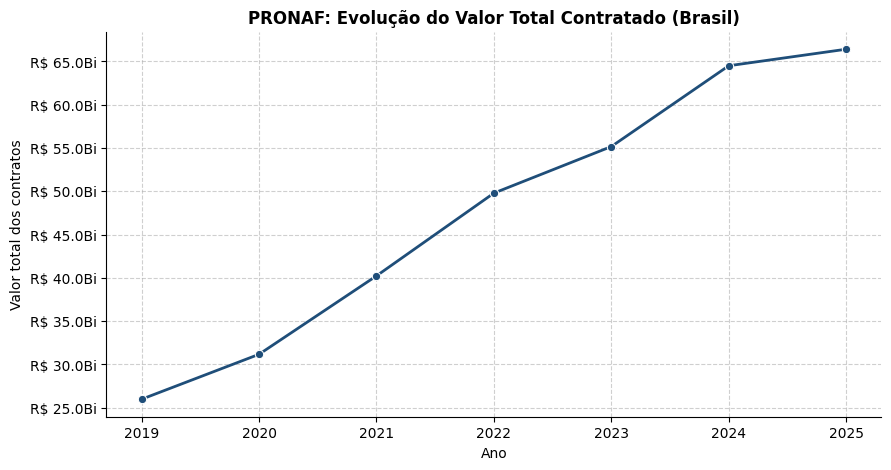

Gráfico salvo: pronaf_valor_br.png

--- Dados agregados para PRONAF - Contratos (pronaf_contratos_historico.png) ---
    ano      valor
0  2019  1357787.0
1  2020  1434539.0
2  2021  1443789.0
3  2022  1453981.0
4  2023  1571764.0
5  2024  1813076.0
6  2025  2070520.0


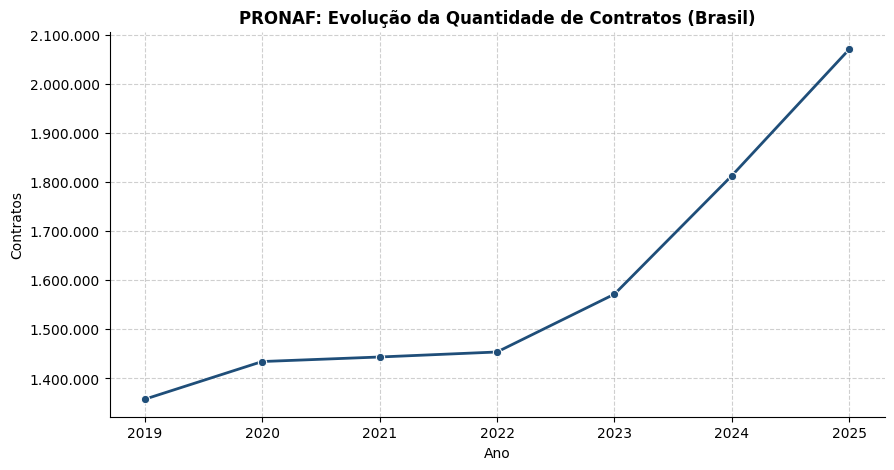

Gráfico salvo: pronaf_contratos_historico.png
Sem dados históricos para Operações no período de 2019 a 2025.


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# 1. Filtrar indicadores da política PRONAF para a tabela atual
df_pronaf = df_indicadores[df_indicadores["politica"] == "PRONAF"].copy()

print(f"\n--- Conteúdo de df_pronaf (antes da tabela atual) ---")
print(f"Shape: {df_pronaf.shape}")
display(df_pronaf.head())

tabela_pronaf_br = df_pronaf.drop_duplicates(subset=['indicador']).copy()
tabela_pronaf_br["Valor Brasil"] = tabela_pronaf_br.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)

print(f"\n--- Conteúdo de tabela_pronaf_br ---")
print(f"Shape: {tabela_pronaf_br.shape}")
display(tabela_pronaf_br.head())

tabela_pronaf_final = tabela_pronaf_br[["politica", "indicador", "Valor Brasil", "dt_referencia"]].rename(columns=texto_ptbr)

caminho_tabela_pronaf = TABELAS_DIR / "tabela_pronaf_brasil.csv"
tabela_pronaf_final.to_csv(caminho_tabela_pronaf, sep=";", index=False, encoding="utf-8-sig")

print(f"Tabela PRONAF Brasil salva em: {caminho_tabela_pronaf.name}")
display(tabela_pronaf_final)

# 2. Ajuste de Mapeamento para Séries Históricas
df_series_ajustado = df_series.copy()
# Ajuste do mapeamento para capturar as colunas originais do processamento histórico
df_series_ajustado['indicador'] = df_series_ajustado['indicador'].replace({
    'qtd_contratos_total': 'Contratos',
    'valor_total_contratos': 'Valor total dos contratos'
})

# 3. Gráficos Históricos (Nacional)
def gerar_grafico_historico_br(politica, indicador, titulo, nome_arquivo, formato):
    # Busca no dataframe ajustado
    df_h = df_series_ajustado[(df_series_ajustado["politica"] == politica) & (df_series_ajustado["indicador"] == indicador)].copy()

    # Filter for years between 2019 and 2025
    df_h = df_h[(df_h['ano'] >= 2019) & (df_h['ano'] <= 2025)].copy()

    if df_h.empty:
        print(f"Sem dados históricos para {indicador} no período de 2019 a 2025.")
        return

    # Consolida valores nacionais por ano
    df_h_br = df_h.groupby('ano')['valor'].sum().reset_index()

    # --- DEBUG PRINT --- #
    print(f"\n--- Dados agregados para {politica} - {indicador} ({nome_arquivo}) ---")
    print(df_h_br.to_string()) # Changed display to print.to_string() for full output
    # --- END DEBUG PRINT -- #

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_h_br, x='ano', y='valor', marker='o', color='#1F4E79', linewidth=2)

    plt.title(texto_ptbr(titulo), fontsize=12, fontweight='bold')
    plt.xlabel('Ano')
    plt.ylabel(indicador)

    ax = plt.gca()
    if formato == 'moeda':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'R$ {x/1e9:.1f}Bi' if x >= 1e9 else f'R$ {x/1e6:.1f}Mi'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))

    plt.grid(True, linestyle='--', alpha=0.6)
    path_grafico = GRAFICOS_DIR / nome_arquivo
    plt.savefig(path_grafico, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Gráfico salvo: {nome_arquivo}")

# Gerar os gráficos para o Brasil com os mapeamentos corrigidos

# Gráfico de Evolução do Valor Total Contratado
gerar_grafico_historico_br("PRONAF", "Valor total dos contratos", "PRONAF: Evolução do Valor Total Contratado (Brasil)", "pronaf_valor_br.png", "moeda")

# Gráfico de Evolução da Quantidade de Contratos
gerar_grafico_historico_br("PRONAF", "Contratos", f"PRONAF: Evolução da Quantidade de Contratos (Brasil)", "pronaf_contratos_historico.png", "inteiro")

# Gráfico de Evolução do Número de Operações
gerar_grafico_historico_br("PRONAF", "Operações", "PRONAF: Evolução do Número de Operações (Brasil)", "pronaf_operacoes_br.png", "inteiro")

### Mais Alimentos

Processando 14 arquivos históricos...
Arquivo: mais_alimentos_gaia_historico_2013_202605131951.xlsx | Aba lida: Totalizadores
Colunas: ['dt_referencia', 'dt_geracao', 'CD_ESTADO', 'cod_ibge_uf', 'qtd_contratos', 'valor_total_contratos']
Registros históricos encontrados (após desduplicação): 26

--- Conteúdo de df_mais_hist_consolidado ---


,ano,uf,politica,indicador,valor
0,2013,BR,Mais Alimentos,Contratos,1.027562e+06
1,2013,BR,Mais Alimentos,Valor total dos contratos,1.104365e+10
2,2014,BR,Mais Alimentos,Contratos,8.398260e+05
3,2014,BR,Mais Alimentos,Valor total dos contratos,1.473063e+10
4,2015,BR,Mais Alimentos,Contratos,7.244720e+05


Tabela Mais Alimentos Histórica (2019-2025) salva em: tabela_mais_alimentos_brasil_2019_2025.csv


,política,indicador,Valor Brasil,dt_referência
0,Mais Alimentos,Contratos,4.084.812,2019-2025
1,Mais Alimentos,Valor total dos contratos,"R$ 144.802.676.380,18",2019-2025



--- Dados agregados para Mais Alimentos - Valor total dos contratos (mais_alimentos_valor_br.png) ---
    ano         valor
0  2019  9.490470e+09
1  2020  1.110972e+10
2  2021  1.507814e+10
3  2022  1.631552e+10
4  2023  1.773508e+10
5  2024  2.588390e+10
6  2025  4.918984e+10


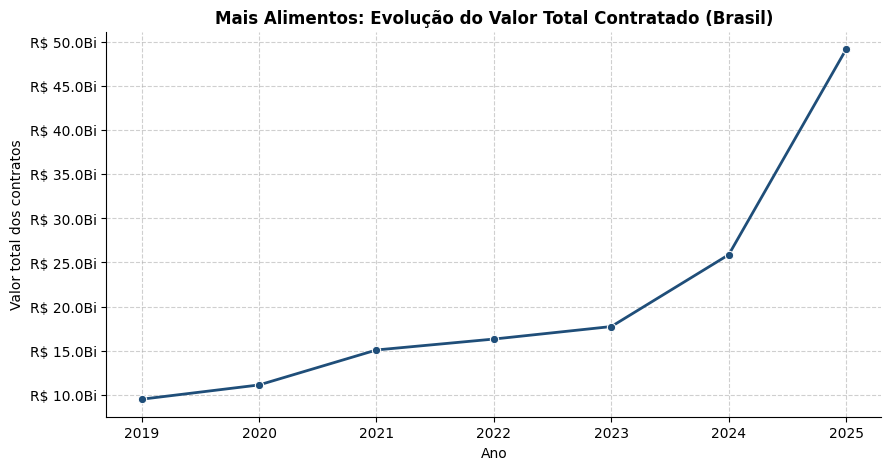

Gráfico salvo: mais_alimentos_valor_br.png

--- Gerando gráfico para Mais Alimentos: Evolução da Quantidade de Contratos (Brasil) ---

--- Dados agregados para Mais Alimentos - Contratos (mais_alimentos_contratos_br.png) ---
    ano      valor
0  2019   367414.0
1  2020   381320.0
2  2021   396050.0
3  2022   372982.0
4  2023   439054.0
5  2024   593072.0
6  2025  1534920.0


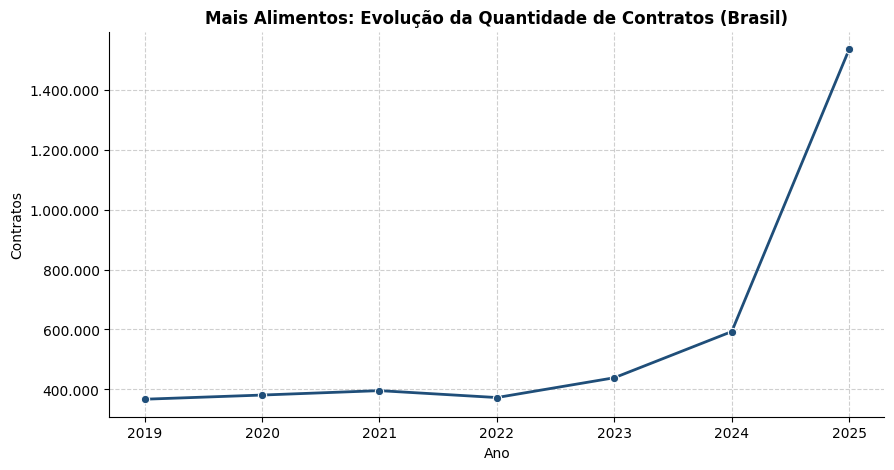

Gráfico salvo: mais_alimentos_contratos_br.png
Gráfico para Mais Alimentos: Evolução da Quantidade de Contratos (Brasil) gerado.


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. Processar Histórico do Mais Alimentos para a série unificada
lista_mais_hist = []
print(f"Processando {len(mais_alimentos_historico_files)} arquivos históricos...")

for i, arquivo in enumerate(mais_alimentos_historico_files):
    try:
        xls = pd.ExcelFile(arquivo, engine='openpyxl')
        # Buscar a aba correta (priorizando DADOS ou TOTALIZADORES)
        aba_alvo = next((s for s in xls.sheet_names if s.upper() in ['DADOS', 'TOTALIZADORES', 'DADO']), xls.sheet_names[0])

        df_temp = pd.read_excel(xls, sheet_name=aba_alvo)
        df_temp.columns = df_temp.columns.astype(str).str.strip()

        # Diagnóstico para validar se pegamos a aba certa
        if i == 0:
            print(f"Arquivo: {arquivo.name} | Aba lida: {aba_alvo}")
            print(f"Colunas: {df_temp.columns.tolist()[:10]}")

        # Identificar ano pelo nome do arquivo
        match_ano = re.search(r'(20\d{2})', arquivo.name)
        ano_arq = int(match_ano.group(1)) if match_ano else None

        # Mapear indicadores (variações comuns em arquivos legados)
        col_valor = next((c for c in df_temp.columns if c.lower() in ['valor_total_contratos', 'vlr_pago', 'valor', 'vlr_total']), None)
        col_qtd = next((c for c in df_temp.columns if c.lower() in ['qtd_contratos', 'quantidade', 'qtd', 'num_contratos']), None)

        if col_valor:
            val = pd.to_numeric(df_temp[col_valor], errors='coerce').sum()
            if not pd.isna(val) and val > 0:
                lista_mais_hist.append({'ano': ano_arq, 'uf': 'BR', 'politica': 'Mais Alimentos', 'indicador': 'Valor total dos contratos', 'valor': val})

        if col_qtd:
            qtd = pd.to_numeric(df_temp[col_qtd], errors='coerce').sum()
            if not pd.isna(qtd) and qtd > 0:
                lista_mais_hist.append({'ano': ano_arq, 'uf': 'BR', 'politica': 'Mais Alimentos', 'indicador': 'Contratos', 'valor': qtd})

    except Exception as e:
        print(f"Erro ao processar {arquivo.name}: {e}")

df_mais_hist_consolidado = pd.DataFrame(lista_mais_hist)

# --- FIX: Remove duplicates by summing values for the same year/indicador ---
if not df_mais_hist_consolidado.empty:
    df_mais_hist_consolidado = df_mais_hist_consolidado.groupby(
        ['ano', 'uf', 'politica', 'indicador']
    )['valor'].sum().reset_index()
# --- END FIX ---

print(f"Registros históricos encontrados (após desduplicação): {len(df_mais_hist_consolidado)}")
print(f"\n--- Conteúdo de df_mais_hist_consolidado ---")
display(df_mais_hist_consolidado.head())


# 2. Atualizar df_series_ajustado
if not df_mais_hist_consolidado.empty:
    df_series_ajustado = pd.concat([
        df_series_ajustado[df_series_ajustado['politica'] != 'Mais Alimentos'],
        df_mais_hist_consolidado
    ], ignore_index=True)

# 3. Gerar a Tabela Histórica (2019-2025) para Mais Alimentos
# Filtrar dados históricos de Mais Alimentos e o período 2019-2025
df_mais_hist_filtered = df_series_ajustado[
    (df_series_ajustado["politica"] == "Mais Alimentos") &
    (df_series_ajustado["ano"].between(2019, 2025, inclusive="both"))
].copy()

if not df_mais_hist_filtered.empty:
    # Agrupar por indicador e somar os valores para Brasil
    tabela_mais_br_hist = df_mais_hist_filtered.groupby("indicador", as_index=False)["valor"].sum()

    # Adicionar colunas de política e dt_referencia, que são fixas para esses indicadores
    tabela_mais_br_hist["politica"] = "Mais Alimentos"
    tabela_mais_br_hist["dt_referencia"] = f"{min(df_mais_hist_filtered['ano'])}-{max(df_mais_hist_filtered['ano'])}"

    # Determine format based on indicator name
    tabela_mais_br_hist["formato"] = tabela_mais_br_hist["indicador"].apply(
        lambda x: "moeda" if "valor" in x.lower() else "inteiro"
    )

    # Formatação institucional para o relatório
    tabela_mais_br_hist["Valor Brasil"] = tabela_mais_br_hist.apply(
        lambda row: formatar_valor(row["valor"], row["formato"]), axis=1
    )

    # Seleção de colunas para exibição clara
    tabela_mais_final = tabela_mais_br_hist[
        ["politica", "indicador", "Valor Brasil", "dt_referencia"]
    ].rename(columns=texto_ptbr)

    caminho_tabela_mais = TABELAS_DIR / "tabela_mais_alimentos_brasil_2019_2025.csv"
    tabela_mais_final.to_csv(caminho_tabela_mais, sep=";", index=False, encoding="utf-8-sig")

    print(f"Tabela Mais Alimentos Histórica (2019-2025) salva em: {caminho_tabela_mais.name}")
    display(tabela_mais_final)
else:
    print("Sem dados históricos de Mais Alimentos para gerar a tabela (2019-2025).")
    # Create an empty DataFrame with the expected columns for display
    tabela_mais_final = pd.DataFrame(columns=["política", "indicador", "Valor Brasil", "dt_referência"])
    display(tabela_mais_final)

# 4. Gerar os gráficos históricos
if not df_mais_hist_consolidado.empty:
    gerar_grafico_historico_br(
        'Mais Alimentos',
        'Valor total dos contratos',
        'Mais Alimentos: Evolução do Valor Total Contratado (Brasil)',
        'mais_alimentos_valor_br.png',
        'moeda'
    )
    # --- FIX: Ensure the graph for 'Contratos' is explicitly printed/shown ---
    print("\n--- Gerando gráfico para Mais Alimentos: Evolução da Quantidade de Contratos (Brasil) ---")
    gerar_grafico_historico_br(
        'Mais Alimentos',
        'Contratos',
        'Mais Alimentos: Evolução da Quantidade de Contratos (Brasil)',
        'mais_alimentos_contratos_br.png',
        'inteiro'
    )
    print("Gráfico para Mais Alimentos: Evolução da Quantidade de Contratos (Brasil) gerado.")
    # --- END FIX ---
else:
    print("Aviso: Dados históricos não encontrados. Verifique se as abas contêm as colunas 'valor' ou 'quantidade'.")

### Ater

Tabela ATER Brasil salva em: tabela_ater_brasil.csv


,politica,indicador,Valor Brasil,dt_referencia
0,ATER,Famílias com ATER iniciada no ano,6.413,2026_04
1,ATER,Famílias com ATER recebida no ano,18.677,2026_04


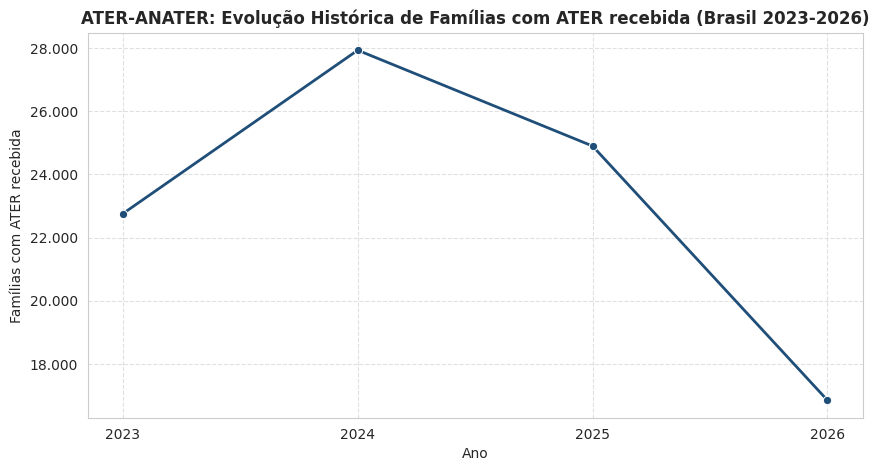

Gráfico salvo: ater_recebida_br_2023_2026_updated.png


In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# =======================================================
# Helpers
# =======================================================
def aplicar_texto_ptbr_colunas(df, texto_ptbr):
    if isinstance(texto_ptbr, dict):
        return df.rename(columns=texto_ptbr)
    return df

def aplicar_texto_ptbr_titulo(texto, texto_ptbr):
    if callable(texto_ptbr):
        return texto_ptbr(texto)
    return texto

def formatar_eixo_inteiro(x, _):
    try:
        return f"{int(x):,}".replace(",", ".")
    except Exception:
        return str(x)

# =======================================================
# 1) Validação e Consolidação ATER Atual
# =======================================================
if "df_ater_atual_uf" in globals() and not df_ater_atual_uf.empty:
    # Fonte da verdade: Soma dos totais municipais processados
    total_2026_ater = df_ater_atual_uf['familias_com_ater_recebida_no_ano'].sum()

    # Sincroniza o df_indicadores com o total real de 2026
    mask_ater = (df_indicadores['politica'] == 'ATER') & (df_indicadores['indicador'].str.contains('recebida', case=False))
    df_indicadores.loc[mask_ater, 'valor_brasil'] = float(total_2026_ater)

    # Atualiza também o sumário executivo
    if 'df_sumario_executivo' in globals():
        mask_sumario = (df_sumario_executivo['politica'] == 'ATER') & (df_sumario_executivo['indicador'].str.contains('recebida', case=False))
        df_sumario_executivo.loc[mask_sumario, 'valor'] = float(total_2026_ater)

df_ater_indicadores = df_indicadores[df_indicadores["politica"] == "ATER"].copy()

tabela_ater_br = df_ater_indicadores.groupby(["politica", "indicador", "formato", "dt_referencia"], as_index=False)["valor_brasil"].first()
tabela_ater_br["Valor Brasil"] = tabela_ater_br.apply(
    lambda row: formatar_valor(row["valor_brasil"], row["formato"]),
    axis=1
)

tabela_ater_final = tabela_ater_br[["politica", "indicador", "Valor Brasil", "dt_referencia"]].copy()
tabela_ater_final = aplicar_texto_ptbr_colunas(tabela_ater_final, texto_ptbr)

# SALVAR TABELA PARA SEÇÃO 6.4
caminho_tabela_ater = TABELAS_DIR / "tabela_ater_brasil.csv"
tabela_ater_final.to_csv(caminho_tabela_ater, sep=";", index=False, encoding="utf-8-sig")

print(f"Tabela ATER Brasil salva em: {caminho_tabela_ater.name}")
display(tabela_ater_final)

# =======================================================
# 2) Base histórica ATER - 2023 a 2026
# =======================================================
if 'df_ater_historico_anual_uf' in globals() and not df_ater_historico_anual_uf.empty:
    df_ater_hist_recebida_br = df_ater_historico_anual_uf.groupby("ano", as_index=False)["familias_com_ater_recebida_no_ano"].sum().sort_values("ano")
    df_ater_hist_recebida_br = df_ater_hist_recebida_br.rename(columns={"familias_com_ater_recebida_no_ano": "valor"})
    df_ater_hist_recebida_br = df_ater_hist_recebida_br[df_ater_hist_recebida_br['ano'] >= 2023]
else:
    df_ater_hist_recebida_br = pd.DataFrame(columns=["ano", "valor"])

# =======================================================
# 4) Gráfico Histórico Consolidado (SEÇÃO 6.4)
# =======================================================
def gerar_grafico_ater_historico(df_hist, titulo, nome_arquivo, ylabel):
    if df_hist.empty: return
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_hist, x="ano", y="valor", marker="o", color="#1F4E79", linewidth=2)
    plt.title(aplicar_texto_ptbr_titulo(titulo, texto_ptbr), fontsize=12, fontweight="bold")
    plt.xlabel("Ano")
    plt.ylabel(ylabel)
    plt.xticks(df_hist["ano"].unique())
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_inteiro))
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(GRAFICOS_DIR / nome_arquivo, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Gráfico salvo: {nome_arquivo}")

# Nome do arquivo sincronizado com a lista 'politicas_relatorio' da seção 6.4
gerar_grafico_ater_historico(
    df_hist=df_ater_hist_recebida_br,
    titulo="ATER-ANATER: Evolução Histórica de Famílias com ATER recebida (Brasil 2023-2026)",
    nome_arquivo="ater_recebida_br_2023_2026_updated.png",
    ylabel="Famílias com ATER recebida"
)

### Garantia-Safra

In [89]:
import pandas as pd

# =======================================================
# Garantia-Safra - Tabela Brasil (Correção de Valores)
# =======================================================

# 1) Validar base consolidada
if "df_indicadores" not in globals() or df_indicadores is None or df_indicadores.empty:
    raise ValueError("df_indicadores não está disponível ou está vazio.")

# 2) Filtrar indicadores da política Garantia-Safra
# Verificamos tanto o nome exato quanto variações comuns
df_gs_br = df_indicadores[
    df_indicadores["politica"].astype(str).str.contains("Garantia-Safra", case=False, na=False)
].copy()

if df_gs_br.empty:
    print("Aviso: Não há registros da política Garantia-Safra em df_indicadores.")
else:
    # 3) Garantir que estamos pegando o valor_brasil correto
    # Em algumas políticas, o valor_brasil está em todas as linhas, em outras apenas na linha de nível nacional
    tabela_gs_br = df_gs_br.groupby(["politica", "indicador", "formato", "dt_referencia"], as_index=False)["valor_brasil"].max()

    # 4) Formatar valores para padrão brasileiro
    tabela_gs_br["Valor Brasil"] = tabela_gs_br.apply(
        lambda row: formatar_valor(row["valor_brasil"], row["formato"]),
        axis=1
    )

    # 5) Selecionar colunas finais
    tabela_gs_final = tabela_gs_br[
        ["politica", "indicador", "Valor Brasil", "dt_referencia"]
    ].copy()

    # 6) Renomear colunas
    if "texto_ptbr" in globals() and callable(texto_ptbr):
        tabela_gs_final.columns = [texto_ptbr(c) for c in tabela_gs_final.columns]

    # 7) Salvar tabela
    caminho_tabela_gs = TABELAS_DIR / "garantia_safra_tabela_brasil.csv"
    tabela_gs_final.to_csv(
        caminho_tabela_gs,
        sep=";",
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Tabela Garantia-Safra (Brasil) atualizada e salva em: {caminho_tabela_gs.name}")
    display(tabela_gs_final)

Tabela Garantia-Safra (Brasil) atualizada e salva em: garantia_safra_tabela_brasil.csv


,política,indicador,Valor Brasil,dt_referência
0,Garantia-Safra,Agricultores aderidos,900.332,2023-2024
1,Garantia-Safra,Agricultores com pagamento liberado,833.621,2023-2024


### Desenrola Rural

In [222]:
import pandas as pd
import numpy as np

def aplicar_texto_ptbr_colunas(df, texto_ptbr_map):
    if isinstance(texto_ptbr_map, dict):
        return df.rename(columns=texto_ptbr_map)
    return df

def formatar_moeda_br(valor):
    if pd.isna(valor): return ""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def formatar_inteiro_br(valor):
    if pd.isna(valor): return ""
    return f"{int(round(valor)):,.0f}".replace(",", ".")

def primeira_coluna_existente(df, candidatos):
    for col in candidatos:
        if col in df.columns: return col
    return None

if "df_desenrola_rural_tratado" in globals() and df_desenrola_rural_tratado is not None and not df_desenrola_rural_tratado.empty:
    df_temp = df_desenrola_rural_tratado.copy()

    # Identificação de colunas
    col_valor = primeira_coluna_existente(df_temp, ["valor_total_operacoes", "valor_renegociado", "vlr_divida"])
    col_oper = primeira_coluna_existente(df_temp, ["numero_operacoes", "qnt_operacoes", "contratos_renegociados"])
    col_tipo = primeira_coluna_existente(df_temp, ["tipo_operacao"])

    v_total = float(df_temp[col_valor].sum())
    n_total = float(df_temp[col_oper].sum())

    # 1. Sincronização com Indicadores Globais
    if "df_indicadores" in globals() and df_indicadores is not None and not df_indicadores.empty:
        politica_mask = df_indicadores["politica"].astype(str).str.strip() == "Desenrola Rural"
        df_indicadores.loc[politica_mask & df_indicadores["indicador"].str.contains("Dívida", na=False), "valor_brasil"] = v_total
        df_indicadores.loc[politica_mask & df_indicadores["indicador"].str.contains("Contratos", na=False), "valor_brasil"] = n_total

        df_desenrola = df_indicadores[df_indicadores["politica"] == "Desenrola Rural"].drop_duplicates(subset=["indicador"]).copy()
        df_desenrola["Valor Brasil"] = df_desenrola.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
        tabela_desenrola_final = df_desenrola[["politica", "indicador", "Valor Brasil", "dt_referencia"]]

        if "texto_ptbr" in globals():
            tabela_desenrola_final = tabela_desenrola_final.rename(columns=texto_ptbr)

        print("--- Tabela Desenrola Rural (Brasil) ---")
        display(tabela_desenrola_final)
        if "TABELAS_DIR" in globals():
            tabela_desenrola_final.to_csv(TABELAS_DIR / "tabela_desenrola_rural_brasil.csv", sep=";", index=False, encoding="utf-8-sig")

    # 2. Resumo por Tipo de Operação
    if col_tipo:
        print("\n--- Resumo por Tipo de Operação ---")
        df_tipo = df_temp.groupby(col_tipo).agg({col_valor: 'sum', col_oper: 'sum'}).reset_index()
        df_tipo = df_tipo.sort_values(col_valor, ascending=False)
        df_tipo['Valor Renegociado'] = df_tipo[col_valor].apply(formatar_moeda_br)
        df_tipo['Contratos'] = df_tipo[col_oper].apply(formatar_inteiro_br)

        resumo_operacao = df_tipo[[col_tipo, 'Valor Renegociado', 'Contratos']].rename(columns={col_tipo: 'Tipo de Operação'})
        display(resumo_operacao)
        if "TABELAS_DIR" in globals():
            resumo_operacao.to_csv(TABELAS_DIR / "desenrola_rural_por_tipo_operacao.csv", sep=";", index=False, encoding="utf-8-sig")

    # 3. Top 5 Cidades
    print("\n--- Top 5 Cidades: Desenrola Rural ---")
    df_cidades = df_temp.groupby(['uf', 'nome_municipio'], as_index=False).agg({col_valor: 'sum', col_oper: 'sum'})
    top_5_valor = df_cidades.sort_values(col_valor, ascending=False).head(5).copy()
    top_5_valor['Valor Formatado'] = top_5_valor[col_valor].apply(formatar_moeda_br)
    top_5_valor['Operações'] = top_5_valor[col_oper].apply(formatar_inteiro_br)

    ranking_cidades = top_5_valor[['nome_municipio', 'uf', 'Valor Formatado', 'Operações']].rename(columns={
        'nome_municipio': 'Cidade', 'uf': 'UF', 'Valor Formatado': 'Valor Renegociado', 'Operações': 'Contratos'
    }).reset_index(drop=True)
    ranking_cidades.index = ranking_cidades.index + 1
    ranking_cidades.index.name = 'Posição'
    display(ranking_cidades)

    if "TABELAS_DIR" in globals():
        ranking_cidades.to_csv(TABELAS_DIR / "ranking_top5_cidades_desenrola_rural.csv", sep=";", index=True, encoding="utf-8-sig")
else:
    print("Dados do Desenrola Rural não encontrados no ambiente.")

--- Tabela Desenrola Rural (Brasil) ---


,política,indicador,Valor Brasil,dt_referência
785,Desenrola Rural,Contratos Renegociados,1.113.486,2025_12
812,Desenrola Rural,Valor da Dívida Renegociada,"R$ 25.466.776.512,58",2025_12



--- Resumo por Tipo de Operação ---


,Tipo de Operação,Valor Renegociado,Contratos
1,DAU,"R$ 20.573.352.128,15",901.180
3,Recursos Proprios,"R$ 4.392.167.430,44",138.041
2,Fundo Constitucional,"R$ 378.345.844,00",63.707
0,Crédito Instalação,"R$ 122.911.109,99",10.558



--- Top 5 Cidades: Desenrola Rural ---


,Cidade,UF,Valor Renegociado,Contratos
Posição,,,,
1,SAO PAULO-SP,SP,"R$ 1.816.216.610,00",71.447
2,RIO DE JANEIRO-RJ,RJ,"R$ 843.892.193,90",33.823
3,BRASILIA-DF,DF,"R$ 582.473.040,62",24.226
4,BELO HORIZONTE-MG,MG,"R$ 542.125.114,68",18.605
5,CURITIBA-PR,PR,"R$ 397.801.448,31",15.281


In [209]:
print('--- VERIFICAÇÃO DE VALORES: DESENROLA RURAL ---')

# 1. Valores da Seção 3.16 (Base Tratada)
v_total_316 = df_desenrola_rural_tratado['valor_total_operacoes'].sum()
n_total_316 = df_desenrola_rural_tratado['numero_operacoes'].sum()

# 2. Valores no df_indicadores (Consolidado)
indicadores_desenrola = df_indicadores[df_indicadores['politica'] == 'Desenrola Rural'].drop_duplicates(subset=['indicador'])

v_consolidado = indicadores_desenrola.loc[indicadores_desenrola['indicador'].str.contains('Dívida', na=False), 'valor_brasil'].values[0]
n_consolidado = indicadores_desenrola.loc[indicadores_desenrola['indicador'].str.contains('Contratos', na=False), 'valor_brasil'].values[0]

# 3. Comparação
print(f'\nTotal Valor (Seção 3.16):   {v_total_316:,.2f}')
print(f'Total Valor (Consolidado): {v_consolidado:,.2f}')
print(f'Diferença:                {v_total_316 - v_consolidado:,.2f}')

print(f'\nTotal Contratos (Seção 3.16):   {n_total_316:,.0f}')
print(f'Total Contratos (Consolidado): {n_consolidado:,.0f}')
print(f'Diferença:                    {n_total_316 - n_consolidado:,.0f}')

if abs(v_total_316 - v_consolidado) < 0.01 and n_total_316 == n_consolidado:
    print('\n[SUCESSO] Os valores conferem perfeitamente!')
else:
    print('\n[ALERTA] Foram encontradas divergências entre a carga e a consolidação.')

--- VERIFICAÇÃO DE VALORES: DESENROLA RURAL ---

Total Valor (Seção 3.16):   25,464,431,716.64
Total Valor (Consolidado): 25,464,431,716.64
Diferença:                0.00

Total Contratos (Seção 3.16):   1,113,379
Total Contratos (Consolidado): 1,113,379
Diferença:                    0

[SUCESSO] Os valores conferem perfeitamente!


### PNCF

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import unicodedata
import re

# Ensure necessary global variables are defined, with fallbacks if needed
if 'CSV_SEP' not in globals():
    CSV_SEP = ";"
if 'CSV_ENCODING' not in globals():
    CSV_ENCODING = "utf-8-sig"

if 'CAMINHO_CONSOLIDADO' not in globals():
    # Fallback to a hardcoded typical path if not globally defined.
    # This path assumes a standard Colab Drive mount and output structure.
    # It's important that this matches the actual output path of df_indicadores.
    CAMINHO_CONSOLIDADO = Path("/content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/dados_intermediarios/202606/consolidado/indicadores_brasil_uf.csv")
    print(f"Warning: CAMINHO_CONSOLIDADO was not defined. Using fallback: {CAMINHO_CONSOLIDADO}")

# Ensure TABELAS_DIR and GRAFICOS_DIR are defined, with fallbacks if not present from previous cells
if 'TABELAS_DIR' not in globals() or 'GRAFICOS_DIR' not in globals():
    # This assumes a similar logic for `OUTPUT_BASE` as in cell `8rpzsnnZ1gNz`
    SAIDA_RELATORIO_BR_ROOT = Path("/content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR")
    RUN_YYYYMM = "202606" # Fallback if RUN_YYYYMM not defined
    RECORTE_TERRITORIAL = "BR" # Fallback if RECORTE_TERRITORIAL not defined

    INTERMEDIARIOS_ROOT = SAIDA_RELATORIO_BR_ROOT / "dados_intermediarios"
    INPUT_DIR = INTERMEDIARIOS_ROOT / RUN_YYYYMM
    OUTPUT_BASE = SAIDA_RELATORIO_BR_ROOT / "relatorios_gerados" / INPUT_DIR.name
    TABELAS_DIR = OUTPUT_BASE / "tabelas" / RECORTE_TERRITORIAL
    GRAFICOS_DIR = OUTPUT_BASE / "graficos" / RECORTE_TERRITORIAL
    TABELAS_DIR.mkdir(parents=True, exist_ok=True) # Ensure directory exists
    GRAFICOS_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Warning: TABELAS_DIR or GRAFICOS_DIR was not defined. Using fallback paths: TABELAS_DIR={TABELAS_DIR}, GRAFICOS_DIR={GRAFICOS_DIR}")

# Ensure nome_uf is defined, with a fallback if not present
if 'nome_uf' not in globals():
    if 'RECORTE_TERRITORIAL' in globals() and RECORTE_TERRITORIAL == "BR":
        nome_uf = "Brasil"
    elif 'RECORTE_TERRITORIAL' in globals():
        # If df_ufs is available, use it; otherwise, use the recorte directly
        if 'df_ufs' in globals() and not df_ufs.empty:
            _territorio = df_ufs[df_ufs["sigla"] == RECORTE_TERRITORIAL]
            nome_uf = _territorio["nome_uf"].iloc[0] if not _territorio.empty else RECORTE_TERRITORIAL
        else:
            nome_uf = RECORTE_TERRITORIAL
    else:
        nome_uf = "Brasil" # Default if RECORTE_TERRITORIAL is also not defined
    print(f"Warning: nome_uf was not defined. Using fallback: {nome_uf}")


# Helper functions needed for this cell (copied for self-containment)
def formatar_valor(valor, formato):
    """Formata valores numéricos como inteiro ou moeda em padrão brasileiro."""
    if pd.isna(valor) or valor == 0:
        return "0" if formato == "inteiro" else "R$ 0,00" if formato == "moeda" else "0,00"
    valor = float(valor)
    if formato == "moeda":
        return "R$ " + f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    elif formato == "inteiro":
        return f"{valor:,.0f}".replace(",", ".")
    elif formato == "decimal":
        return f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    elif formato == "pct":
        return f"{valor:.2f}%".replace(".", ",")
    return str(valor)

def texto_ptbr(texto):
    """Padroniza textos de exibição em português do Brasil."""
    if pd.isna(texto): return texto
    texto = str(texto)
    substituicoes = {
        "Relatorio": "Relatório", "relatorio": "relatório",
        "Sumario": "Sumário", "sumario": "sumário",
        "Participacao": "Participação", "participacao": "participação",
        "posicao": "posição", "referencia": "referência",
        "politica": "política", "politicas": "políticas",
        "propria": "própria", "historico": "histórico", "Historico": "Histórico",
        "disponiveis": "disponíveis", "periodos": "períodos", "periodo": "período",
        "execucao": "execução", "pagina": "página", "Pagina": "Página",
        "rodape": "rodapé", "cabecalho": "cabeçalho", "Agraria": "Agrária",
        "exibicao": "exibição", "informacao": "informação",
        "geracao": "geração", "Geracao": "Geração", "mes": "mês", "ate": "até",
        "Familias": "Famílias", "familias": "famílias",
        "Operacoes": "Operações", "operacoes": "operações", "operacao": "operação",
        "Juridica": "Jurídica", "Fisica": "Física", "medio": "médio",
        "regularizacao": "regularização",
    }
    for origem, destino in substituicoes.items():
        texto = texto.replace(origem, destino)
    return texto

# Ensure df_indicadores is loaded if not already in memory
if 'df_indicadores' not in globals() or df_indicadores.empty:
    try:
        # CAMINHO_CONSOLIDADO is defined in previous cells (e.g., KYAV5-po1B00, 46a35e62)
        df_indicadores = pd.read_csv(CAMINHO_CONSOLIDADO, sep=CSV_SEP, encoding=CSV_ENCODING)
        print(f"df_indicadores loaded from {CAMINHO_CONSOLIDADO}")
    except Exception as e:
        print(f"Error loading df_indicadores: {e}")
        # If loading fails, create an empty DataFrame to avoid further errors
        df_indicadores = pd.DataFrame(columns=['politica', 'indicador', 'uf', 'valor_uf', 'valor_brasil', 'formato', 'dt_referencia', 'dt_geracao', 'arquivo_origem', 'cod_ibge_uf', 'nome_uf', 'percentual_uf_brasil', 'ranking_uf'])

# 1. Filtrar indicadores da política PNCF
df_pncf = df_indicadores[df_indicadores["politica"] == "PNCF"].copy()

# 2. Preparar e formatar a tabela para exibição (Nível Brasil)
tabela_pncf_br = df_pncf.drop_duplicates(subset=['indicador']).copy()
tabela_pncf_br["Valor Brasil"] = tabela_pncf_br.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)

colunas_exibicao = ["politica", "indicador", "Valor Brasil", "dt_referencia"]
tabela_pncf_final = tabela_pncf_br[colunas_exibicao].rename(columns=texto_ptbr)

# 3. Salvar tabela
caminho_tabela_pncf = TABELAS_DIR / "tabela_pncf_brasil.csv"
tabela_pncf_final.to_csv(caminho_tabela_pncf, sep=";", index=False, encoding="utf-8-sig")

print(f"Tabela PNCF Brasil salva em: {caminho_tabela_pncf.name}")
display(tabela_pncf_final)


Tabela PNCF Brasil salva em: tabela_pncf_brasil.csv


,política,indicador,Valor Brasil,dt_referência
6156,PNCF,Operações,574,2026_04
6183,PNCF,Valor liberado,"R$ 144.125.795,01",2026_04
6210,PNCF,Valor médio liberado por operação,"R$ 4.897.696,29",2026_04


### **Quintais Produtivos**

In [229]:
import pandas as pd

# 1. Filtrar indicadores da política Quintais Produtivos
df_quintais_ind = df_indicadores[df_indicadores["politica"] == "Quintais Produtivos"].copy()

if df_quintais_ind.empty:
    print("Aviso: Dados de Quintais Produtivos não encontrados em df_indicadores.")
    # Tentativa de reconstrução manual caso a consolidação tenha falhado
    if 'df_quintais_produtivos_tratado' in globals():
        print("Reconstruindo indicadores de Quintais Produtivos a partir da base tratada...")
        cols_map = {'mda': 'Quintais (MDA)', 'mds': 'Quintais (MDS)', 'bndes': 'Quintais (BNDES)'}
        rows = []
        for col_orig, label in cols_map.items():
            if col_orig in df_quintais_produtivos_tratado.columns:
                val_br = df_quintais_produtivos_tratado[col_orig].sum()
                rows.append({
                    'politica': 'Quintais Produtivos',
                    'indicador': label,
                    'valor_brasil': val_br,
                    'formato': 'inteiro',
                    'dt_referencia': df_quintais_produtivos_tratado['dt_referencia'].iloc[0]
                })
        df_quintais_ind = pd.DataFrame(rows)

if not df_quintais_ind.empty:
    # 2. Preparar e formatar a tabela para exibição (Nível Brasil)
    tabela_quintais_br = df_quintais_ind.drop_duplicates(subset=['indicador']).copy()

    # 3. Calcular Total Numérico
    total_valor = tabela_quintais_br['valor_brasil'].sum()

    # 4. Formatar valores para exibição
    tabela_quintais_br["Valor Brasil"] = tabela_quintais_br.apply(lambda row: formatar_valor(row["valor_brasil"], row.get("formato", "inteiro")), axis=1)

    # Seleção de colunas
    colunas_exibicao = ["politica", "indicador", "Valor Brasil", "dt_referencia"]
    tabela_quintais_final = tabela_quintais_br[colunas_exibicao].rename(columns=texto_ptbr)

    # 5. Adicionar Linha de Total
    total_row = pd.DataFrame([{
        tabela_quintais_final.columns[0]: 'Total',
        tabela_quintais_final.columns[1]: 'Total',
        tabela_quintais_final.columns[2]: formatar_valor(total_valor, 'inteiro'),
        tabela_quintais_final.columns[3]: ''
    }])
    tabela_quintais_final = pd.concat([tabela_quintais_final, total_row], ignore_index=True)

    # 6. Salvar para uso na seção 6.4
    caminho_tabela_quintais = TABELAS_DIR / "tabela_quintais_produtivos_brasil.csv"
    tabela_quintais_final.to_csv(caminho_tabela_quintais, sep=";", index=False, encoding="utf-8-sig")

    print(f"Tabela Quintais Produtivos Brasil salva em: {caminho_tabela_quintais.name}")
    display(tabela_quintais_final)
else:
    print("Erro crítico: Não foi possível encontrar ou reconstruir dados de Quintais Produtivos.")

Tabela Quintais Produtivos Brasil salva em: tabela_quintais_produtivos_brasil.csv


,política,indicador,Valor Brasil,dt_referência
0,Quintais Produtivos,Quintais (MDA),58.412,2023_2025
1,Quintais Produtivos,Quintais (MDS),48.595,2023_2025
2,Quintais Produtivos,Quintais (BNDES),1.574,2023_2025
3,Quintais Produtivos,Quantidade de quintais,58.412,2023_2025
4,Total,Total,166.993,


### PAA AF

Tabela PAA AF Brasil salva: tabela_paa_agricultura_familiar_brasil.csv


,politica,indicador,Valor Brasil,dt_referencia
0,PAA AF,Famílias beneficiadas,15.958,2026_02
1,PAA AF,Valor pago,"R$ 68.518.741,28",2026_02


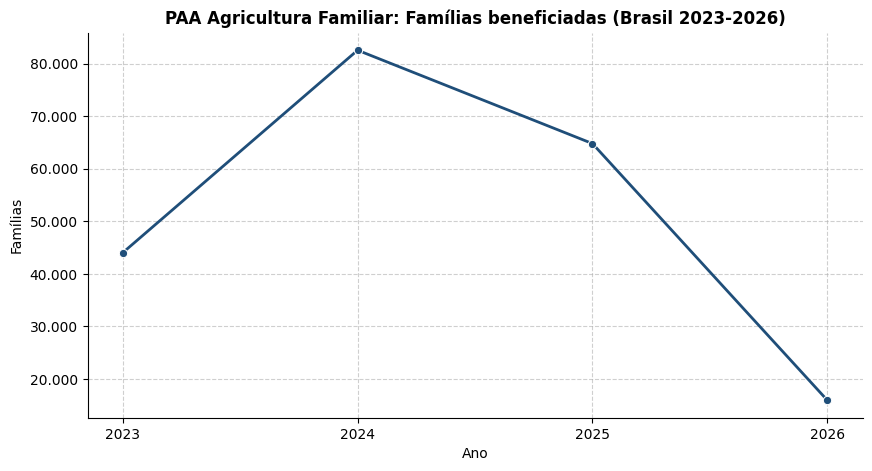

Gráfico salvo: paa_af_familias_2023_2026.png


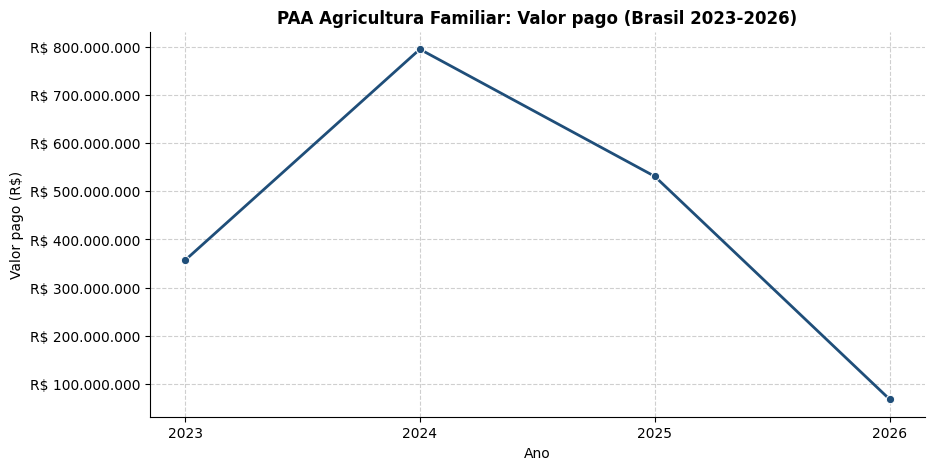

Gráfico salvo: paa_af_valor_2023_2026.png


In [93]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata

# =======================================================
# Helpers
# =======================================================
def normalizar_texto_simples(texto):
    """Remove acentos e padroniza para busca robusta."""
    if pd.isna(texto): return ""
    return "".join(c for c in unicodedata.normalize('NFKD', str(texto)) if not unicodedata.combining(c)).lower().strip()

def aplicar_texto_ptbr_colunas(df, texto_ptbr):
    if isinstance(texto_ptbr, dict):
        return df.rename(columns=texto_ptbr)
    return df

def aplicar_texto_ptbr_titulo(texto, texto_ptbr):
    if callable(texto_ptbr):
        return texto_ptbr(texto)
    return texto

def formatar_eixo_inteiro(x, _):
    try: return f"{int(x):,}".replace(",", ".")
    except: return str(x)

def formatar_eixo_moeda(x, _):
    try: return f"R$ {x:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")
    except: return str(x)

def extrair_ano_texto(valor):
    if pd.isna(valor): return pd.NA
    match = re.search(r"(20\d{2})", str(valor))
    return int(match.group(1)) if match else pd.NA

# =======================================================
# 1) Filtrar indicadores da política PAA AF (Sumário 2026)
# =======================================================
if "df_paa_af_uf" not in globals() or df_paa_af_uf is None or df_paa_af_uf.empty:
    raise ValueError("df_paa_af_uf não disponível para processar dados 2026.")

# Priorização 2026: Garantir que o sumário use o dado mais recente de 2026_02
df_paa_2026 = df_paa_af_uf[df_paa_af_uf['dt_referencia'].str.contains('2026', na=False)].copy()

if df_paa_2026.empty:
    # Fallback caso 2026 não esteja na base uf
    df_paa_summary_base = df_paa_af_uf.copy()
else:
    df_paa_summary_base = df_paa_2026.copy()

# Consolidar Brasil
paa_br_summary = df_paa_summary_base.groupby('dt_referencia', as_index=False).agg({
    'qtd_familias_beneficiadas': 'sum',
    'valor_pago_paa_af': 'sum'
}).sort_values('dt_referencia', ascending=False).iloc[0]

tabela_paa_final = pd.DataFrame([
    {"politica": "PAA AF", "indicador": "Famílias beneficiadas", "Valor Brasil": formatar_valor(paa_br_summary['qtd_familias_beneficiadas'], 'inteiro'), "dt_referencia": paa_br_summary['dt_referencia']},
    {"politica": "PAA AF", "indicador": "Valor pago", "Valor Brasil": formatar_valor(paa_br_summary['valor_pago_paa_af'], 'moeda'), "dt_referencia": paa_br_summary['dt_referencia']}
])

tabela_paa_final = aplicar_texto_ptbr_colunas(tabela_paa_final, texto_ptbr)
caminho_tabela_paa = TABELAS_DIR / "tabela_paa_agricultura_familiar_brasil.csv"
tabela_paa_final.to_csv(caminho_tabela_paa, sep=";", index=False, encoding="utf-8-sig")

print(f"Tabela PAA AF Brasil salva: {caminho_tabela_paa.name}")
display(tabela_paa_final)

# =======================================================
# 2) Montar base histórica (2023-2026)
# =======================================================
base_series_paa = pd.DataFrame()
if "df_paa_af_uf" in globals() and not df_paa_af_uf.empty:
    df_tmp = df_paa_af_uf.copy()
    df_tmp["ano"] = df_tmp["dt_referencia"].apply(extrair_ano_texto).astype("Int64")

    s_fam = df_tmp[["ano", "uf", "dt_referencia", "qtd_familias_beneficiadas"]].copy()
    s_fam["indicador"] = "Famílias beneficiadas"
    s_fam = s_fam.rename(columns={"qtd_familias_beneficiadas": "valor"})

    s_val = df_tmp[["ano", "uf", "dt_referencia", "valor_pago_paa_af"]].copy()
    s_val["indicador"] = "Valor pago"
    s_val = s_val.rename(columns={"valor_pago_paa_af": "valor"})

    base_series_paa = pd.concat([s_fam, s_val], ignore_index=True)
    base_series_paa["valor"] = pd.to_numeric(base_series_paa["valor"], errors="coerce").fillna(0)

# =======================================================
# 3) Função de Gráfico Histórico
# =======================================================
def gerar_grafico_paa_af_2023_2026(indicador_busca, titulo, nome_arquivo, ylabel, eixo_moeda=False):
    if base_series_paa.empty: return

    termo = normalizar_texto_simples(indicador_busca)
    df_h = base_series_paa[
        (base_series_paa["indicador"].apply(normalizar_texto_simples).str.contains(termo)) &
        (base_series_paa["ano"].between(2023, 2026))
    ].copy()

    if df_h.empty:
        print(f"Sem dados para {indicador_busca} em 2023-2026.")
        return

    df_h_br = df_h.groupby("ano", as_index=False)["valor"].sum().sort_values("ano")

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_h_br, x="ano", y="valor", marker="o", color="#1F4E79", linewidth=2)
    plt.title(aplicar_texto_ptbr_titulo(titulo, texto_ptbr), fontsize=12, fontweight="bold")
    plt.xlabel("Ano")
    plt.ylabel(ylabel)
    plt.xticks(df_h_br["ano"].unique())

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_moeda if eixo_moeda else formatar_eixo_inteiro))
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(GRAFICOS_DIR / nome_arquivo, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Gráfico salvo: {nome_arquivo}")

# Executar Gráficos
gerar_grafico_paa_af_2023_2026("familias beneficiadas", "PAA Agricultura Familiar: Famílias beneficiadas (Brasil 2023-2026)", "paa_af_familias_2023_2026.png", "Famílias")
gerar_grafico_paa_af_2023_2026("valor pago", "PAA Agricultura Familiar: Valor pago (Brasil 2023-2026)", "paa_af_valor_2023_2026.png", "Valor pago (R$)", eixo_moeda=True)

In [94]:
df_paa_af_2026 = df_paa_af_uf[df_paa_af_uf['dt_referencia'].str.startswith('2026')]
total_familias_2026 = df_paa_af_2026['qtd_familias_beneficiadas'].sum()
print(f"Soma total de famílias beneficiadas por PAA AF em 2026: {total_familias_2026}")

Soma total de famílias beneficiadas por PAA AF em 2026: 15958


### PAA Compras Institucionais

--- Tabela PAA Compras Institucionais: Evolução Nacional ---


,dt_referencia,Alimentos (kg),Valor Chamadas (Brasil),dt_geracao
0,2023_12,33.097.054,"R$ 540.874.546,00",2026_05_25
1,2024_12,457.483.025,"R$ 5.654.918.869,00",2026_05_25
2,2025_12,413.616.562,"R$ 4.782.288.596,00",2026_05_25
3,2026_04,25.861.834,"R$ 3.914.905.822,00",2026_05_25


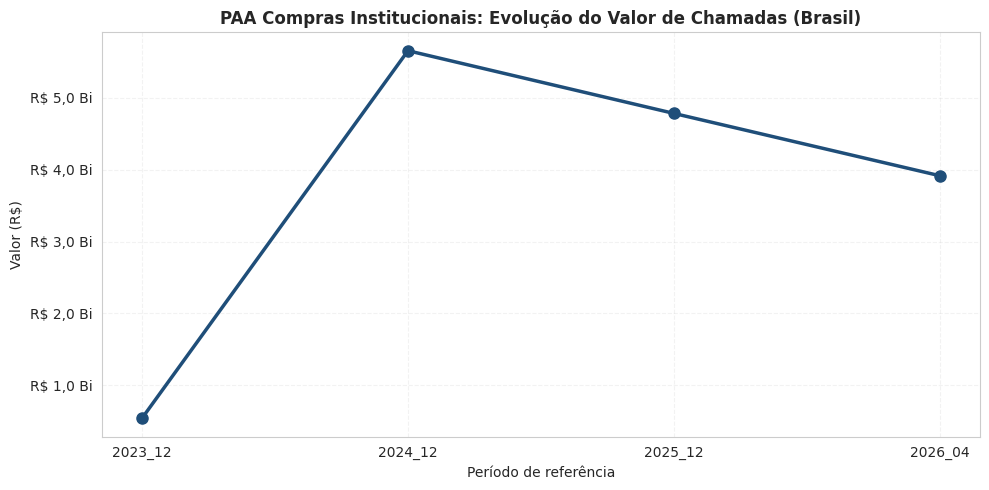

Processamento PAA CI concluído. Gráfico de linhas salvo em: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606/graficos/BR/paa_ci_evolucao_valor_brasil.png


In [95]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# =======================================================
# Helpers
# =======================================================
def aplicar_texto_ptbr_colunas(df, texto_ptbr):
    if isinstance(texto_ptbr, dict):
        return df.rename(columns=texto_ptbr)
    return df

def aplicar_texto_ptbr_titulo(texto, texto_ptbr_func):
    if callable(texto_ptbr_func):
        return texto_ptbr_func(texto)
    return texto

def extrair_ordem_referencia(valor):
    if pd.isna(valor):
        return 0
    texto = str(valor).strip()
    match_yyyymm = re.search(r"(20\d{2})\D?(0[1-9]|1[0-2])", texto)
    if match_yyyymm:
        return int(f"{match_yyyymm.group(1)}{match_yyyymm.group(2)}")
    match_yyyy = re.search(r"(20\d{2})", texto)
    if match_yyyy:
        return int(f"{match_yyyy.group(1)}00")
    return 0

def formatar_eixo_moeda_resumido(x, _):
    try:
        if x < 1e9:
            return f"R$ {x / 1e6:.1f} Mi".replace('.', ',')
        return f"R$ {x / 1e9:.1f} Bi".replace('.', ',')
    except Exception:
        return str(x)

# =======================================================
# 1) Validar base
# =======================================================
if "df_paa_ci_tratado" not in globals() or df_paa_ci_tratado is None or df_paa_ci_tratado.empty:
    print("Aviso: DataFrame df_paa_ci_tratado não encontrado ou vazio.")
else:
    # 2) Consolidar base nacional por dt_referencia
    df_paa_ci_br = df_paa_ci_tratado.copy()
    df_paa_ci_br["alimentos_kg"] = pd.to_numeric(df_paa_ci_br["alimentos_kg"], errors="coerce").fillna(0)
    df_paa_ci_br["vlr_chamadas"] = pd.to_numeric(df_paa_ci_br["vlr_chamadas"], errors="coerce").fillna(0)

    df_paa_ci_br = (
        df_paa_ci_br
        .groupby("dt_referencia", as_index=False)
        .agg({
            "dt_geracao": "first",
            "alimentos_kg": "sum",
            "vlr_chamadas": "sum"
        })
    )

    df_paa_ci_br["_ordem_ref"] = df_paa_ci_br["dt_referencia"].apply(extrair_ordem_referencia)
    df_paa_ci_br = df_paa_ci_br.sort_values("_ordem_ref").reset_index(drop=True)

    # 3) Tabela - Evolução nacional
    tabela_paa_ci_final = df_paa_ci_br.copy()
    tabela_paa_ci_final["Valor Chamadas (Brasil)"] = tabela_paa_ci_final["vlr_chamadas"].apply(lambda x: formatar_valor(x, "moeda"))
    tabela_paa_ci_final["Alimentos (kg)"] = tabela_paa_ci_final["alimentos_kg"].apply(lambda x: formatar_valor(x, "inteiro"))

    tabela_paa_ci_final = tabela_paa_ci_final[["dt_referencia", "Alimentos (kg)", "Valor Chamadas (Brasil)", "dt_geracao"]]
    if "texto_ptbr" in globals():
        tabela_paa_ci_final = aplicar_texto_ptbr_colunas(tabela_paa_ci_final, texto_ptbr)

    print("--- Tabela PAA Compras Institucionais: Evolução Nacional ---")
    display(tabela_paa_ci_final)

    # 4) Geração do gráfico de LINHAS (sem rótulos)
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid", {"grid.linestyle": "--"})

    # Gráfico de linhas com marcadores
    plt.plot(df_paa_ci_br["dt_referencia"], df_paa_ci_br["vlr_chamadas"], marker='o', linestyle='-', color='#1F4E79', linewidth=2.5, markersize=8)

    plt.title(aplicar_texto_ptbr_titulo("PAA Compras Institucionais: Evolução do Valor de Chamadas (Brasil)",
                                       texto_ptbr if "texto_ptbr" in globals() else None),
              fontsize=12, fontweight="bold")
    plt.xlabel("Período de referência")
    plt.ylabel("Valor (R$)")

    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_moeda_resumido))

    # Rótulos de dados removidos conforme solicitado

    plt.tight_layout()
    path_grafico_ci = GRAFICOS_DIR / "paa_ci_evolucao_valor_brasil.png"
    plt.savefig(path_grafico_ci, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Processamento PAA CI concluído. Gráfico de linhas salvo em: {path_grafico_ci}")

### PNRA

In [163]:
import pandas as pd

# 1. Filtrar indicadores da política PNRA
df_pnra_ind = df_indicadores[df_indicadores["politica"] == "PNRA"].copy()

# 2. Preparar e formatar a tabela para exibição (Nível Brasil)
tabela_pnra_br = df_pnra_ind.drop_duplicates(subset=['indicador']).copy()

# Correção de acentuação e digitação nos rótulos dos indicadores
def corrigir_texto_pnra(texto):
    if pd.isna(texto): return texto
    mapping = {
        'Fam3lias': 'Famílias',
        'fam3lias': 'famílias',
        'regulariza13o': 'regularização',
        'regularização': 'regularização',
        'PNRA': 'PNRA'
    }
    for erro, correto in mapping.items():
        texto = str(texto).replace(erro, correto)
    return texto

tabela_pnra_br["indicador"] = tabela_pnra_br["indicador"].apply(corrigir_texto_pnra)
tabela_pnra_br["Valor Brasil"] = tabela_pnra_br.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)

# Seleção de colunas
colunas_exibicao = ["politica", "indicador", "Valor Brasil", "dt_referencia"]
tabela_pnra_final = tabela_pnra_br[colunas_exibicao].rename(columns=texto_ptbr)

# 3. Salvar tabela
caminho_tabela_pnra = TABELAS_DIR / "tabela_pnra_brasil.csv"
tabela_pnra_final.to_csv(caminho_tabela_pnra, sep=CSV_SEP, index=False, encoding=CSV_ENCODING)

print(f"Tabela PNRA Brasil salva em: {caminho_tabela_pnra.name}")
display(tabela_pnra_final)

Tabela PNRA Brasil salva em: tabela_pnra_brasil.csv


,política,indicador,Valor Brasil,dt_referência
404,PNRA,Famílias em PA criado diferenciado,2.341,2026 até mar
431,PNRA,Famílias em PA criado tradicional,40,2026 até mar
458,PNRA,Famílias em reconhecimento,2.000,2026 até mar
485,PNRA,Famílias em regularização,4.738,2026 até mar
512,PNRA,Total de famílias,9.119,2026 até mar


### Territótios Quilombolas

In [237]:
import pandas as pd
import numpy as np

def fix_tq_text(df):
    if df.empty: return df
    for col in ['politica', 'indicador']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('fam3lias', 'famílias', case=False).str.replace('1rea', 'Área', case=False)
    return df

def gerar_historico_tq_expandido(politica_nome, df_tratado, col_qtd, col_fam):
    """Consolida série histórica 2023-2026 capturando Qtd e Famílias."""
    if df_tratado is None or df_tratado.empty:
        return pd.DataFrame(columns=['Ano', f'{politica_nome} Qtd', f'{politica_nome} Famílias'])

    df_h = df_tratado.copy()
    df_h['ano_num'] = df_h['dt_referencia'].astype(str).str.extract(r'(20\d{2})')[0].astype(float).fillna(0).astype(int)
    df_h = df_h[df_h['ano_num'].between(2023, 2026)]

    c_qtd = col_qtd[0] if isinstance(col_qtd, list) else col_qtd
    c_fam = col_fam[0] if isinstance(col_fam, list) else col_fam

    df_h[c_qtd] = pd.to_numeric(df_h[c_qtd], errors='coerce').fillna(0)
    df_h[c_fam] = pd.to_numeric(df_h[c_fam], errors='coerce').fillna(0)

    df_res = df_h.groupby('ano_num').agg({c_qtd: 'sum', c_fam: 'sum'}).reset_index()
    df_res.columns = ['Ano', f'{politica_nome} Qtd', f'{politica_nome} Famílias']

    print(f"\n--- Histórico: {politica_nome} (Qtd e Famílias) ---")
    display(df_res)
    return df_res

# 1. Gerar Históricos Expandidos
hist_decretos = gerar_historico_tq_expandido('Decretos', df_tq_decretos_tratado, 'qtd_decretos', 'decretos_familias')
hist_portarias = gerar_historico_tq_expandido('Portarias', df_tq_portarias_tratado, 'total_portarias', ['portarias_familias', 'qnt_familias'])
hist_rtids = gerar_historico_tq_expandido('RTIDs', df_tq_rtids_tratado, ['qnt_rtid', 'total_rtdis'], 'qnt_familias')

# 2. Criar Tabela Consolidada Quilombola Detalhada (2023-2026)
print("\n--- Tabela Consolidada Histórico Quilombola Completa (2023-2026) ---")
tq_consolidado = pd.DataFrame({'Ano': [2023, 2024, 2025, 2026]})
tq_consolidado = tq_consolidado.merge(hist_decretos, on='Ano', how='left')
tq_consolidado = tq_consolidado.merge(hist_portarias, on='Ano', how='left')
tq_consolidado = tq_consolidado.merge(hist_rtids, on='Ano', how='left')
tq_consolidado = tq_consolidado.fillna(0)

# Gerar colunas formatadas e manter apenas a visão final limpa
cols_finais = ['Ano']
for col in [c for c in tq_consolidado.columns if c != 'Ano']:
    new_col = f'{col}'
    tq_consolidado[new_col] = tq_consolidado[col].apply(lambda x: formatar_valor(x, 'inteiro'))
    cols_finais.append(new_col)

# Remove duplicidade mantendo apenas as colunas de exibição
tq_consolidado = tq_consolidado[cols_finais]

display(tq_consolidado)
tq_consolidado.to_csv(TABELAS_DIR / "tabela_consolidada_historico_quilombolas_2023_2026.csv", sep=";", index=False, encoding='utf-8-sig')

# 3. Atualizar Snapshots
df_tq_decretos_ind = df_indicadores[df_indicadores["politica"] == "TQ Decretos"].copy()
if not df_tq_decretos_ind.empty:
    tab_dec = fix_tq_text(df_tq_decretos_ind.drop_duplicates(subset=['indicador']).copy())
    tab_dec["Valor Brasil"] = tab_dec.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
    tab_dec[["politica", "indicador", "Valor Brasil", "dt_referencia"]].rename(columns=texto_ptbr).to_csv(TABELAS_DIR / "tabela_tq_decretos_brasil_atual.csv", sep=";", index=False, encoding='utf-8-sig')

df_tq_portarias_ind = df_indicadores[df_indicadores["politica"] == "TQ Portarias"].copy()
if not df_tq_portarias_ind.empty:
    tab_port = fix_tq_text(df_tq_portarias_ind.drop_duplicates(subset=['indicador']).copy())
    tab_port["Valor Brasil"] = tab_port.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
    tab_port[["politica", "indicador", "Valor Brasil", "dt_referencia"]].rename(columns=texto_ptbr).to_csv(TABELAS_DIR / "tabela_tq_portarias_brasil_atual.csv", sep=";", index=False, encoding='utf-8-sig')

df_tq_rtids_ind = df_indicadores[df_indicadores["politica"] == "TQ RTIDs"].copy()
if not df_tq_rtids_ind.empty:
    tab_rtid = fix_tq_text(df_tq_rtids_ind.drop_duplicates(subset=['indicador']).copy())
    tab_rtid["Valor Brasil"] = tab_rtid.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
    tab_rtid[["politica", "indicador", "Valor Brasil", "dt_referencia"]].rename(columns=texto_ptbr).to_csv(TABELAS_DIR / "tabela_tq_rtids_brasil_atual.csv", sep=";", index=False, encoding='utf-8-sig')


--- Histórico: Decretos (Qtd e Famílias) ---


,Ano,Decretos Qtd,Decretos Famílias
0,2023,1,109
1,2024,31,5292
2,2025,28,3352



--- Histórico: Portarias (Qtd e Famílias) ---


,Ano,Portarias Qtd,Portarias Famílias
0,2023,52.0,7143.0
1,2024,21.0,5882.0
2,2025,16.0,2353.0
3,2026,1.0,0.0



--- Histórico: RTIDs (Qtd e Famílias) ---


,Ano,RTIDs Qtd,RTIDs Famílias
0,2023,12,0.0
1,2024,15,0.0
2,2025,24,0.0



--- Tabela Consolidada Histórico Quilombola Completa (2023-2026) ---


,Ano,Decretos Qtd,Decretos Famílias,Portarias Qtd,Portarias Famílias,RTIDs Qtd,RTIDs Famílias
0,2023,1,109,52,7.143,12,0
1,2024,31,5.292,21,5.882,15,0
2,2025,28,3.352,16,2.353,24,0
3,2026,0,0,1,0,0,0


### **Títulos INCRA**

In [141]:
def gerar_tabela_desagregada_titulos(df_tratado):
    if df_tratado is None or df_tratado.empty:
        print("Dados de Títulos INCRA não disponíveis.")
        return pd.DataFrame()

    df_h = df_tratado.copy()

    # Extrair o ano da dt_referencia
    df_h['ano'] = df_h['dt_referencia'].astype(str).str.extract(r'(20\d{2})')[0].astype(float).fillna(0).astype(int)

    # Filtrar período 2023-2026
    df_h = df_h[df_h['ano'].between(2023, 2026)]

    # Colunas de detalhe preservadas no df_titulos_incra_tratado
    colunas_detalhe = [
        'soma_titulos_definitivos_td_cdru',
        'soma_contrato_concessao_uso_ccu',
        'soma_titulos_definitivos_rf'
    ]

    label_map = {
        'soma_titulos_definitivos_td_cdru': 'Títulos TD/CDRU',
        'soma_contrato_concessao_uso_ccu': 'Contratos CCU',
        'soma_titulos_definitivos_rf': 'Títulos RF'
    }

    cols_existentes = [c for c in colunas_detalhe if c in df_h.columns]

    # Agrupar por ano e somar as categorias
    df_res = df_h.groupby('ano').agg({
        **{c: 'sum' for c in cols_existentes}
    }).reset_index()

    # Calcular o Total como a soma das categorias para garantir consistência
    df_res['Total_Calculado'] = df_res[cols_existentes].sum(axis=1)

    # Formatação institucional
    for c in cols_existentes:
        label = label_map.get(c)
        df_res[label] = df_res[c].apply(lambda x: formatar_valor(x, 'inteiro'))

    df_res['Total'] = df_res['Total_Calculado'].apply(lambda x: formatar_valor(x, 'inteiro'))

    # Seleção de colunas finais
    colunas_finais = ['ano'] + [label_map[c] for c in cols_existentes] + ['Total']
    tabela_final = df_res[colunas_finais].rename(columns={'ano': 'Ano'})

    return tabela_final

# Gerar a desagregação atualizada
tabela_desagregada = gerar_tabela_desagregada_titulos(df_titulos_incra_tratado)

print("--- Tabela Desagregada Atualizada: Títulos INCRA por Categoria (2023-2026) ---")
display(tabela_desagregada)

# Exportar para manter integridade do relatório
caminho_desagregada = TABELAS_DIR / "tabela_desagregada_titulos_incra.csv"
tabela_desagregada.to_csv(caminho_desagregada, sep=";", index=False, encoding="utf-8-sig")

--- Tabela Desagregada Atualizada: Títulos INCRA por Categoria (2023-2026) ---


,Ano,Títulos TD/CDRU,Contratos CCU,Títulos RF,Total
0,2023,5.592,44.074,1.325,50.991
1,2024,6.519,50.751,3.294,60.564
2,2025,14.768,111.692,8.975,135.435


### Tabela das Fontes

In [142]:
import pandas as pd
from docx import Document
from docx.shared import RGBColor, Pt

# =======================================================
# Helpers
# =======================================================
def aplicar_texto_ptbr_texto(texto, texto_ptbr):
    """
    Aplica tradução/ajuste de texto caso texto_ptbr seja função.
    Se texto_ptbr for dicionário, tenta mapear a chave.
    Caso contrário, retorna o texto original.
    """
    if "texto_ptbr" in globals():
        if callable(texto_ptbr):
            return texto_ptbr(texto)
        if isinstance(texto_ptbr, dict):
            return texto_ptbr.get(texto, texto)
    return texto


def garantir_documento(caminho_docx):
    """
    Abre um documento existente ou cria um novo, caso o arquivo ainda não exista.
    """
    try:
        if caminho_docx.exists():
            return Document(caminho_docx)
        return Document()
    except Exception:
        return Document()

colunas_fontes_base = ["politica", "dt_referencia", "dt_geracao", "arquivo_origem"]
faltantes = [col for col in colunas_fontes_base if col not in df_indicadores.columns]
if faltantes:
    raise KeyError(f"As seguintes colunas obrigatórias não foram encontradas em df_indicadores: {faltantes}")

df_fontes = (
    df_indicadores[colunas_fontes_base]
    .copy()
    .drop_duplicates()
    .sort_values(["politica", "arquivo_origem"], na_position="last")
    .reset_index(drop=True)
)

# Metadados da execução
df_fontes["script_origem"] = SCRIPT_NAME if "SCRIPT_NAME" in globals() else ""
df_fontes["versao_script"] = SCRIPT_VERSION if "SCRIPT_VERSION" in globals() else ""
df_fontes["run_id"] = RUN_DATETIME if "RUN_DATETIME" in globals() else ""

# Padronização textual
for col in ["politica", "dt_referencia", "dt_geracao", "arquivo_origem", "script_origem", "versao_script", "run_id"]:
    df_fontes[col] = df_fontes[col].astype(str).str.strip()

# =======================================================
# 3) Salvar CSV de fontes
# =======================================================
caminho_fontes_csv = TABELAS_DIR / "fontes_utilizadas.csv"
df_fontes.to_csv(
    caminho_fontes_csv,
    sep=CSV_SEP if "CSV_SEP" in globals() else ";",
    index=False,
    encoding=CSV_ENCODING if "CSV_ENCODING" in globals() else "utf-8-sig"
)

print("--- Fontes de Dados Consolidadas ---")
display(df_fontes)
print(f"CSV de fontes salvo em: {caminho_fontes_csv}")

# =======================================================
# 4) Inserir no final do documento Word
# =======================================================
try:
    if "CAMINHO_SAIDA_DOCX" not in globals():
        raise ValueError("A variável CAMINHO_SAIDA_DOCX não está definida.")

    doc = garantir_documento(CAMINHO_SAIDA_DOCX)

    # Quebra de página antes da seção de fontes
    doc.add_page_break()

    titulo_secao = aplicar_texto_ptbr_texto("Fontes de Dados Utilizadas", texto_ptbr if "texto_ptbr" in globals() else None)
    doc.add_heading(titulo_secao, level=1)

    paragrafo_intro = (
        "A tabela abaixo detalha a origem de cada dado apresentado neste relatório, "
        "incluindo o período de referência e a data de geração dos arquivos brutos."
    )
    doc.add_paragraph(paragrafo_intro)

    # Criar tabela
    table = doc.add_table(rows=1, cols=len(df_fontes.columns))
    table.style = "Table Grid"

    # Cabeçalho
    hdr_cells = table.rows[0].cells
    colunas_rotulo = [
        "Política",
        "Referência",
        "Geração",
        "Arquivo de Origem",
        "Script",
        "Versão",
        "Execução",
    ]

    for i, rotulo in enumerate(colunas_rotulo):
        hdr_cells[i].text = rotulo

        # aplica sombreamento se a função existir no pipeline
        if "aplicar_sombreamento_celula" in globals():
            aplicar_sombreamento_celula(hdr_cells[i], "1F4E79")

        for p in hdr_cells[i].paragraphs:
            for r in p.runs:
                r.font.color.rgb = RGBColor(255, 255, 255)
                r.bold = True
                r.font.size = Pt(9)

    # Preencher dados
    for _, row in df_fontes.iterrows():
        row_cells = table.add_row().cells
        row_cells[0].text = aplicar_texto_ptbr_texto(str(row["politica"]), texto_ptbr if "texto_ptbr" in globals() else None)
        row_cells[1].text = str(row["dt_referencia"])
        row_cells[2].text = str(row["dt_geracao"])
        row_cells[3].text = str(row["arquivo_origem"])
        row_cells[4].text = str(row["script_origem"])
        row_cells[5].text = str(row["versao_script"])
        row_cells[6].text = str(row["run_id"])

        for cell in row_cells:
            for p in cell.paragraphs:
                for r in p.runs:
                    r.font.size = Pt(8)

    # Salvar documento
    doc.save(CAMINHO_SAIDA_DOCX)

    nome_relatorio = NOME_RELATORIO if "NOME_RELATORIO" in globals() else CAMINHO_SAIDA_DOCX.name
    print(f"\nTabela de fontes inserida com sucesso no arquivo: {nome_relatorio}")

except Exception as e:
    print(f"Erro ao atualizar o documento Word: {e}")

--- Fontes de Dados Consolidadas ---


,politica,dt_referencia,dt_geracao,arquivo_origem,script_origem,versao_script,run_id
0,ATER,2026_04,20260512,ater_ate_2026_04_gerado_em_20260512153352.xlsx,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
1,CAF,2026_04,2026_05_12,caf_dap_ativos_ate_2026_04_gerado_em_202605121...,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
2,Desenrola Rural,2025_12,,Desenrola_rural_20260601.xlsx,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
3,Garantia-Safra,2023-2024,2026_04_13,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
4,Mais Alimentos,2026_04,2026_05_13,mais_alimentos_gaia_202605131504.xlsx,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
...,...,...,...,...,...,...,...
125,TQ Portarias,2025,2026_05_25,Territorio_Quilombola_Portarias.gsheet,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
126,TQ Portarias,2026,2026_05_25,Territorio_Quilombola_Portarias.gsheet,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
127,TQ RTIDs,2023,2026_05_25,Territorio_Quilombola_RTIDs.gsheet,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156
128,TQ RTIDs,2024,2026_05_25,Territorio_Quilombola_RTIDs.gsheet,teste_relatoriobr_25maio2026.py,2026.06.02-nacional,20260603132156


CSV de fontes salvo em: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606/tabelas/BR/fontes_utilizadas.csv

Tabela de fontes inserida com sucesso no arquivo: relatorio_monitoramento_BR_20260603132156.docx


In [200]:
import pandas as pd
from pathlib import Path

# Configuration to ensure all tables are saved for section 6.4
tabelas_para_salvar = [
    ('tabela_caf_brasil.csv', 'CAF', None),
    ('tabela_pronaf_brasil.csv', 'PRONAF', None),
    ('tabela_mais_alimentos_brasil_2019_2025.csv', 'Mais Alimentos', 'df_mais_hist_filtered'),
    ('tabela_desenrola_rural_brasil.csv', 'Desenrola Rural', None),
    ('tabela_pncf_brasil.csv', 'PNCF', None),
    ('tabela_paa_agricultura_familiar_brasil.csv', 'PAA AF', 'df_paa_af_uf'),
    ('tabela_paa_ci_evolucao_valor_brasil.csv', 'PAA Compras Institucionais', 'df_paa_ci_tratado'),
    ('tabela_ater_brasil.csv', 'ATER', None),
    ('tabela_quintais_produtivos_brasil.csv', 'Quintais Produtivos', 'df_quintais_produtivos_tratado'),
    ('tabela_pnra_brasil.csv', 'PNRA', None),
    ('tabela_tq_decretos_brasil_atual.csv', 'TQ Decretos', 'df_tq_decretos_tratado'),
    ('tabela_tq_portarias_brasil_atual.csv', 'TQ Portarias', 'df_tq_portarias_tratado'),
    ('tabela_tq_rtids_brasil_atual.csv', 'TQ RTIDs', 'df_tq_rtids_tratado'),
]

print(f"--- Salvando tabelas para o Relatório Word (Seção 6.4) ---")

for nome_arquivo, politica_nome, df_fallback_name in tabelas_para_salvar:
    # 1. Try to filter from df_indicadores
    df_filt = df_indicadores[df_indicadores['politica'] == politica_nome].drop_duplicates(subset=['indicador']).copy()

    # 2. If empty, try fallback DataFrames
    if df_filt.empty and df_fallback_name in globals():
        df_fallback = globals()[df_fallback_name]
        if not df_fallback.empty:
            # Construct a compatible structure for the saving loop
            if politica_nome == 'PAA AF':
                # Use the summary calculation logic from the PAA AF cell
                paa_sum = df_fallback.groupby('dt_referencia', as_index=False).agg({'qtd_familias_beneficiadas': 'sum', 'valor_pago_paa_af': 'sum'}).sort_values('dt_referencia', ascending=False).iloc[0]
                df_filt = pd.DataFrame([
                    {'politica': 'PAA AF', 'indicador': 'Famílias beneficiadas', 'valor_brasil': paa_sum['qtd_familias_beneficiadas'], 'formato': 'inteiro', 'dt_referencia': paa_sum['dt_referencia']},
                    {'politica': 'PAA AF', 'indicador': 'Valor pago', 'valor_brasil': paa_sum['valor_pago_paa_af'], 'formato': 'moeda', 'dt_referencia': paa_sum['dt_referencia']}
                ])
            elif politica_nome == 'Quintais Produtivos':
                # Reconstruct from tratado columns
                cols_map = {'mda': 'Quintais (MDA)', 'mds': 'Quintais (MDS)', 'bndes': 'Quintais (BNDES)'}
                rows = []
                for col_orig, label in cols_map.items():
                    if col_orig in df_fallback.columns:
                        rows.append({'politica': 'Quintais Produtivos', 'indicador': label, 'valor_brasil': df_fallback[col_orig].sum(), 'formato': 'inteiro', 'dt_referencia': df_fallback['dt_referencia'].iloc[0]})
                df_filt = pd.DataFrame(rows)
            elif 'tq' in politica_nome.lower():
                 # Mapping for TQ fallbacks
                 col_target = 'total_portarias' if 'Portarias' in politica_nome else 'total_rtdis' if 'RTIDs' in politica_nome else 'qtd_decretos'
                 df_filt = pd.DataFrame([{'politica': politica_nome, 'indicador': 'Quantidade', 'valor_brasil': df_fallback[col_target].sum(), 'formato': 'inteiro', 'dt_referencia': df_fallback['dt_referencia'].max()}])

    if df_filt.empty:
        print(f"Aviso: Sem dados para {politica_nome}. Tabela {nome_arquivo} não será gerada.")
        continue

    # Format values for display
    df_filt['Valor Brasil'] = df_filt.apply(lambda row: formatar_valor(row['valor_brasil'], row.get('formato', 'inteiro')), axis=1)

    # Select core columns
    df_final = df_filt[['politica', 'indicador', 'Valor Brasil', 'dt_referencia']].copy()

    # Apply PT-BR translations
    if 'texto_ptbr' in globals():
        df_final = df_final.rename(columns=texto_ptbr)
        df_final.iloc[:, 0] = df_final.iloc[:, 0].apply(texto_ptbr)
        df_final.iloc[:, 1] = df_final.iloc[:, 1].apply(texto_ptbr)

    # Special case for Quintais Produtivos Total
    if politica_nome == 'Quintais Produtivos':
        df_numeric = df_filt.copy()
        total_val = df_numeric['valor_brasil'].sum()
        total_row = pd.DataFrame([{
            df_final.columns[0]: 'Total',
            df_final.columns[1]: 'Total',
            df_final.columns[2]: formatar_valor(total_val, 'inteiro'),
            df_final.columns[3]: ''
        }])
        df_final = pd.concat([df_final, total_row], ignore_index=True)

    # Save to TABELAS_DIR
    path_saida = TABELAS_DIR / nome_arquivo
    df_final.to_csv(path_saida, sep=';', index=False, encoding='utf-8-sig')
    print(f"✓ {nome_arquivo} salvo com sucesso.")

--- Salvando tabelas para o Relatório Word (Seção 6.4) ---
✓ tabela_caf_brasil.csv salvo com sucesso.
✓ tabela_pronaf_brasil.csv salvo com sucesso.
✓ tabela_mais_alimentos_brasil_2019_2025.csv salvo com sucesso.
✓ tabela_desenrola_rural_brasil.csv salvo com sucesso.
✓ tabela_pncf_brasil.csv salvo com sucesso.
✓ tabela_paa_agricultura_familiar_brasil.csv salvo com sucesso.
Aviso: Sem dados para PAA Compras Institucionais. Tabela tabela_paa_ci_evolucao_valor_brasil.csv não será gerada.
✓ tabela_ater_brasil.csv salvo com sucesso.
✓ tabela_quintais_produtivos_brasil.csv salvo com sucesso.
✓ tabela_pnra_brasil.csv salvo com sucesso.
✓ tabela_tq_decretos_brasil_atual.csv salvo com sucesso.
✓ tabela_tq_portarias_brasil_atual.csv salvo com sucesso.
✓ tabela_tq_rtids_brasil_atual.csv salvo com sucesso.


### Rankings das Políticas (Top 5 UFs)
Esta seção apresenta os rankings das 5 principais Unidades da Federação para as políticas solicitadas.

In [126]:
import pandas as pd

def gerar_rank_top5(df_ind, politica_nome, indicador_nome, titulo_label):
    """Gera um DataFrame formatado com o Top 5 de uma política/indicador."""
    # Filtra o indicador e remove duplicatas de UF para a referência mais recente
    df_filt = df_ind[(df_ind['politica'] == politica_nome) & (df_ind['indicador'] == indicador_nome)].copy()
    if df_filt.empty:
        return pd.DataFrame()

    # Pega a última referência disponível
    ultima_ref = df_filt['dt_referencia'].unique()[-1]
    df_filt = df_filt[df_filt['dt_referencia'] == ultima_ref]

    # Ordena e pega o Top 5
    df_top = df_filt.sort_values('valor_uf', ascending=False).head(5).reset_index(drop=True)

    # Formata para exibição
    df_top['Posição'] = df_top.index + 1
    df_top['Valor Formatado'] = df_top.apply(lambda x: formatar_valor(x['valor_uf'], x['formato']), axis=1)

    ranking_final = df_top[['Posição', 'nome_uf', 'Valor Formatado']].rename(columns={'nome_uf': 'UF', 'Valor Formatado': titulo_label})
    return ranking_final

# 1. Desenrola Rural - Valor da Dívida
rank_desenrola = gerar_rank_top5(df_indicadores, 'Desenrola Rural', 'Valor da Dívida Renegociada', 'Valor Renegociado')
if not rank_desenrola.empty:
    print("--- Top 5: Desenrola Rural (Valor da Dívida) ---")
    display(rank_desenrola)
    rank_desenrola.to_csv(TABELAS_DIR / "ranking_top5_desenrola_rural.csv", sep=";", index=False, encoding="utf-8-sig")

# 2. Quintais Produtivos - Quantidade de Quintais
rank_quintais = gerar_rank_top5(df_indicadores, 'Quintais Produtivos', 'Quantidade de quintais', 'Nº de Quintais')
if not rank_quintais.empty:
    print("\n--- Top 5: Quintais Produtivos (Qtd) ---")
    display(rank_quintais)
    rank_quintais.to_csv(TABELAS_DIR / "ranking_top5_quintais_produtivos.csv", sep=";", index=False, encoding="utf-8-sig")

# 3. PNRA - Total de famílias
rank_pnra = gerar_rank_top5(df_indicadores, 'PNRA', 'Total de famílias', 'Total de Famílias')
if not rank_pnra.empty:
    print("\n--- Top 5: PNRA (Total de Famílias) ---")
    display(rank_pnra)
    rank_pnra.to_csv(TABELAS_DIR / "ranking_top5_pnra.csv", sep=";", index=False, encoding="utf-8-sig")

### Insumos gerados


In [144]:
import pandas as pd
from pathlib import Path

# 1) Validar diretórios de saída
# =======================================================
if "TABELAS_DIR" not in globals():
    raise ValueError("A variável TABELAS_DIR não está definida.")

if "GRAFICOS_DIR" not in globals():
    raise ValueError("A variável GRAFICOS_DIR não está definida.")

if "UF_INTERESSE" not in globals():
    UF_INTERESSE = "UF_NAO_INFORMADA"

# Determinar diretório base: usa OUTPUT_BASE se existir; senão tenta OUTPUT_ROOT_DIR; senão usa o pai de TABELAS_DIR
# =======================================================
if "OUTPUT_BASE" in globals():
    diretorio_base = OUTPUT_BASE
elif "OUTPUT_ROOT_DIR" in globals():
    diretorio_base = OUTPUT_ROOT_DIR
else:
    diretorio_base = TABELAS_DIR.parent

# Garante tipo Path para exibição consistente
diretorio_base = Path(diretorio_base)
tabelas_dir = Path(TABELAS_DIR)
graficos_dir = Path(GRAFICOS_DIR)

# =======================================================
# 2) Listar arquivos gerados nos diretórios de saída
# =======================================================
tabelas_geradas = sorted(tabelas_dir.glob("*.csv")) if tabelas_dir.exists() else []
graficos_gerados = sorted(graficos_dir.glob("*.png")) if graficos_dir.exists() else []

# =======================================================
# 3) Criar DataFrame de conferência com metadados básicos
# =======================================================
insumos = []

for p in tabelas_geradas:
    insumos.append({
        "tipo": "tabela",
        "arquivo": p.name,
        "tamanho_kb": round(p.stat().st_size / 1024, 2),
        "caminho_local": str(p),
    })

for p in graficos_gerados:
    insumos.append({
        "tipo": "gráfico",
        "arquivo": p.name,
        "tamanho_kb": round(p.stat().st_size / 1024, 2),
        "caminho_local": str(p),
    })

df_insumos = pd.DataFrame(insumos)

# =======================================================
# 4) Resumo de conferência
# =======================================================
print(f"### Conferência de Insumos para o Relatório ({UF_INTERESSE}) ###")
print(f"Diretório base: {diretorio_base}")
print(f"Diretório de tabelas: {tabelas_dir}")
print(f"Diretório de gráficos: {graficos_dir}")
print(f"Total de tabelas: {len(tabelas_geradas)}")
print(f"Total de gráficos: {len(graficos_gerados)}")

if not df_insumos.empty:
    # Ordena para facilitar auditoria
    df_insumos = df_insumos.sort_values(["tipo", "arquivo"]).reset_index(drop=True)

    # Resumo por tipo
    resumo_insumos = (
        df_insumos.groupby("tipo", as_index=False)
        .agg(
            quantidade=("arquivo", "count"),
            tamanho_total_kb=("tamanho_kb", "sum"),
        )
    )
    resumo_insumos["tamanho_total_kb"] = resumo_insumos["tamanho_total_kb"].round(2)

    print("\n--- Resumo por tipo ---")
    display(resumo_insumos)

    print("\n--- Arquivos encontrados ---")
    display(df_insumos)
else:
    print("AVISO: Nenhum arquivo .csv ou .png foi encontrado nos diretórios de saída informados.")

### Conferência de Insumos para o Relatório (BR) ###
Diretório base: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606
Diretório de tabelas: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606/tabelas/BR
Diretório de gráficos: /content/drive/.shortcut-targets-by-id/1vjphYN2JHf-OsvJdJ97NxxI1CdL_tXid/DAMEI_Relatorio_Dados/dados_brutos/saida_relatorioBR/relatorios_gerados/202606/graficos/BR
Total de tabelas: 35
Total de gráficos: 21

--- Resumo por tipo ---


,tipo,quantidade,tamanho_total_kb
0,gráfico,21,3237.55
1,tabela,35,23.48



--- Arquivos encontrados ---


,tipo,arquivo,tamanho_kb,caminho_local
0,gráfico,ater_iniciada_br_2023_2026.png,102.34,/content/drive/.shortcut-targets-by-id/1vjphYN...
1,gráfico,ater_iniciada_br_2023_2026_updated.png,106.27,/content/drive/.shortcut-targets-by-id/1vjphYN...
2,gráfico,ater_recebida_br_2023_2026.png,147.70,/content/drive/.shortcut-targets-by-id/1vjphYN...
3,gráfico,ater_recebida_br_2023_2026_updated.png,137.64,/content/drive/.shortcut-targets-by-id/1vjphYN...
4,gráfico,desenrola_rural_brasil_2025.png,115.94,/content/drive/.shortcut-targets-by-id/1vjphYN...
5,gráfico,mais_alimentos_contratos_br.png,134.90,/content/drive/.shortcut-targets-by-id/1vjphYN...
6,gráfico,mais_alimentos_valor_br.png,161.95,/content/drive/.shortcut-targets-by-id/1vjphYN...
7,gráfico,paa_af_familias_2023_2026.png,150.63,/content/drive/.shortcut-targets-by-id/1vjphYN...
8,gráfico,paa_af_valor_2023_2026.png,179.59,/content/drive/.shortcut-targets-by-id/1vjphYN...
9,gráfico,paa_agricultura_familiar_familias_beneficiadas...,153.47,/content/drive/.shortcut-targets-by-id/1vjphYN...


## 6. Montando o Documento Word

In [150]:
def adicionar_campo_word(paragrafo, instrucao, texto_padrao='1'):
    """Insere um campo dinÃ¢mico do Word, como PAGE, em um parÃ¡grafo."""
    run_inicio = paragrafo.add_run()
    campo_inicio = OxmlElement('w:fldChar')
    campo_inicio.set(qn('w:fldCharType'), 'begin')
    run_inicio._r.append(campo_inicio)

    run_instrucao = paragrafo.add_run()
    instrucao_campo = OxmlElement('w:instrText')
    instrucao_campo.set(qn('xml:space'), 'preserve')
    instrucao_campo.text = f' {instrucao} '
    run_instrucao._r.append(instrucao_campo)

    run_separador = paragrafo.add_run()
    campo_separador = OxmlElement('w:fldChar')
    campo_separador.set(qn('w:fldCharType'), 'separate')
    run_separador._r.append(campo_separador)

    run_resultado = paragrafo.add_run(texto_padrao)

    run_fim = paragrafo.add_run()
    campo_fim = OxmlElement('w:fldChar')
    campo_fim.set(qn('w:fldCharType'), 'end')
    run_fim._r.append(campo_fim)
    return run_resultado

### 6.1 Configuração Inicial do Documento

In [151]:
doc = Document()
normal_style = doc.styles['Normal']
normal_style.font.name = 'Arial'
normal_style.font.size = Pt(10)

atualizar_campos = OxmlElement('w:updateFields')
atualizar_campos.set(qn('w:val'), 'true')
doc.settings.element.append(atualizar_campos)

### 6.2 Cabeçalho e Rodapé

### 6.4 Seções por Políticas (Tabelas e Gráficos)

In [239]:
import pandas as pd
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

# 1. Inicializar Documento e Configurações de Estilo
doc = Document()
style = doc.styles['Normal']
style.font.name = 'Arial'
style.font.size = Pt(10)

# Ativar atualização automática de campos (Sumário/Paginação) ao abrir
settings = doc.settings.element
update_fields = OxmlElement('w:updateFields')
update_fields.set(qn('w:val'), 'true')
settings.append(update_fields)

# 2. Configurar Cabeçalho e Rodapé em todas as seções
for secao in doc.sections:
    secao.header_distance = Inches(0.15)
    paragrafo_cabecalho = secao.header.paragraphs[0]
    paragrafo_cabecalho.alignment = WD_ALIGN_PARAGRAPH.RIGHT
    if CAMINHO_IMAGEM_CABECALHO.exists():
        run_cab = paragrafo_cabecalho.add_run()
        run_cab.add_picture(str(CAMINHO_IMAGEM_CABECALHO), width=Inches(LARGURA_IMAGEM_CABECALHO_POLEGADAS))

    paragrafo_rodape = secao.footer.paragraphs[0]
    paragrafo_rodape.text = TEXTO_RODAPE
    paragrafo_rodape.alignment = WD_ALIGN_PARAGRAPH.CENTER
    for run in paragrafo_rodape.runs:
        run.font.size = Pt(9)

    # Rodapé com Numeração de Página Dinâmica
    par_pag = secao.footer.add_paragraph()
    par_pag.alignment = WD_ALIGN_PARAGRAPH.CENTER
    par_pag.add_run('Página ')
    adicionar_campo_word(par_pag, 'PAGE')
    par_pag.add_run(' de ')
    adicionar_campo_word(par_pag, 'NUMPAGES')
    for run in par_pag.runs:
        run.font.size = Pt(9)

# 3. Título Principal e Sumário Executivo
titulo_txt = 'MDA Monitora - Brasil'
doc.add_heading(titulo_txt, 0).alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph(f'Gerado em: {RUN_TIMESTAMP:%d/%m/%Y %H:%M}')

doc.add_heading('1. Sumário Executivo', level=1)
doc.add_paragraph('Principais indicadores consolidados no nível nacional.')

# Tabela de Indicadores Atuais (Snapshot)
table_atuais = doc.add_table(rows=1, cols=3)
table_atuais.style = 'Table Grid'
hdr_cells = table_atuais.rows[0].cells
for i, txt in enumerate(['Política', 'Indicador', 'Valor']):
    hdr_cells[i].text = txt
    aplicar_sombreamento_celula(hdr_cells[i], '1F4E79')
    for p in hdr_cells[i].paragraphs:
        for r in p.runs:
            r.font.color.rgb = RGBColor(255, 255, 255)
            r.bold = True

for _, row in df_sumario_executivo.iterrows():
    row_cells = table_atuais.add_row().cells
    pol_nome = sanitizar_texto_institucional(str(row['politica'])) if 'sanitizar_texto_institucional' in globals() else str(row['politica'])
    ind_nome = sanitizar_texto_institucional(str(row['indicador'])) if 'sanitizar_texto_institucional' in globals() else str(row['indicador'])
    row_cells[0].text = pol_nome
    row_cells[1].text = ind_nome
    row_cells[2].text = formatar_valor(row['valor'], row['formato'])

adicionar_estilo_tabela(table_atuais)

# 4. Comparativo Histórico
doc.add_heading('2. Comparativo Histórico (2019-2022 vs 2023-2026)', level=1)
adicionar_tabela_formatada_word(doc, df_sumario_historico, 'Síntese de Evolução por Períodos')

# 5. Seções por Políticas
politicas_relatorio = [
    ('CAF', 'tabela_caf_brasil.csv', [], []),
    ('PRONAF', 'tabela_pronaf_brasil.csv', ['pronaf_valor_br.png', 'pronaf_contratos_historico.png'], []),
    ('Mais Alimentos', 'tabela_mais_alimentos_brasil_2019_2025.csv', ['mais_alimentos_valor_br.png', 'mais_alimentos_contratos_br.png'], []),
    ('Desenrola Rural', 'tabela_desenrola_rural_brasil.csv', [], ['desenrola_rural_por_tipo_operacao.csv', 'ranking_top5_cidades_desenrola_rural.csv']),
    ('PNCF', 'tabela_pncf_brasil.csv', [], []),
    ('PAA AF', 'tabela_paa_agricultura_familiar_brasil.csv', ['paa_af_familias_2023_2026.png', 'paa_af_valor_2023_2026.png'], []),
    ('PAA Compras Institucionais', 'tabela_paa_ci_evolucao_valor_brasil.csv', ['paa_ci_evolucao_valor_brasil.png'], []),
    ('ATER-ANATER', 'tabela_ater_brasil.csv', ['ater_recebida_br_2023_2026_updated.png'], []),
    ('Quintais Produtivos', 'tabela_quintais_produtivos_brasil.csv', [], ['ranking_top5_quintais_produtivos.csv']),
    ('PNRA', 'tabela_pnra_brasil.csv', [], ['ranking_top5_pnra.csv']),
    ('Títulos INCRA', 'tabela_desagregada_titulos_incra.csv', [], []),
    ('Territórios Quilombolas', 'tabela_consolidada_historico_quilombolas_2023_2026.csv', [], []),
    ('Territórios Quilombolas - Decretos', 'tabela_tq_decretos_brasil_atual.csv', [], []),
    ('Territórios Quilombolas - Portarias', 'tabela_tq_portarias_brasil_atual.csv', [], []),
    ('Territórios Quilombolas - RTID', 'tabela_tq_rtids_brasil_atual.csv', [], []),
]

def adicionar_secao_politica(doc, politica_nome, tabela_principal_path, graficos_lista, tabelas_extras_lista):
    doc.add_heading(f'Seção: {politica_nome}', level=1)
    for g_nome in graficos_lista:
        g_path = GRAFICOS_DIR / g_nome
        if g_path.exists():
            doc.add_picture(str(g_path), width=Inches(5.5))
            last_p = doc.paragraphs[-1]
            last_p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            doc.add_paragraph(f'Gráfico: Evolução {politica_nome}', style='Caption').alignment = WD_ALIGN_PARAGRAPH.CENTER
    if tabela_principal_path.exists():
        try:
            df_tab = pd.read_csv(tabela_principal_path, sep=';', encoding='utf-8-sig')
            adicionar_tabela_formatada_word(doc, df_tab, f'Indicadores Atuais - {politica_nome}')
        except Exception as e:
            print(f"Erro ao inserir tabela {tabela_principal_path.name}: {e}")
    for t_extra_nome in tabelas_extras_lista:
        t_path = TABELAS_DIR / t_extra_nome
        if t_path.exists():
            try:
                df_extra = pd.read_csv(t_path, sep=';', encoding='utf-8-sig')
                titulo_extra = t_extra_nome.replace('.csv', '').replace('_', ' ').title()
                adicionar_tabela_formatada_word(doc, df_extra, titulo_extra)
            except Exception as e:
                print(f"Erro ao inserir tabela extra {t_extra_nome}: {e}")

for nome, tab_file, graficos, extras in politicas_relatorio:
    adicionar_secao_politica(doc, nome, TABELAS_DIR / tab_file, graficos, extras)

# 7. Salvar Final
doc.save(CAMINHO_SAIDA_DOCX)
print(f'Relatório Word Completo Gerado: {CAMINHO_SAIDA_DOCX.name}')

Tabela 'Síntese de Evolução por Períodos' adicionada ao documento.
Tabela 'Indicadores Atuais - CAF' adicionada ao documento.
Tabela 'Indicadores Atuais - PRONAF' adicionada ao documento.
Tabela 'Indicadores Atuais - Mais Alimentos' adicionada ao documento.
Tabela 'Indicadores Atuais - Desenrola Rural' adicionada ao documento.
Tabela 'Desenrola Rural Por Tipo Operacao' adicionada ao documento.
Tabela 'Ranking Top5 Cidades Desenrola Rural' adicionada ao documento.
Tabela 'Indicadores Atuais - PNCF' adicionada ao documento.
Tabela 'Indicadores Atuais - PAA AF' adicionada ao documento.
Tabela 'Indicadores Atuais - ATER-ANATER' adicionada ao documento.
Tabela 'Indicadores Atuais - Quintais Produtivos' adicionada ao documento.
Tabela 'Indicadores Atuais - PNRA' adicionada ao documento.
Tabela 'Indicadores Atuais - Títulos INCRA' adicionada ao documento.
Tabela 'Indicadores Atuais - Territórios Quilombolas' adicionada ao documento.
Tabela 'Indicadores Atuais - Territórios Quilombolas - Decre